#### Imports and Setups

Importing the libraries needed for data processing, plotting, file handling, web scraping, Neo4j access, and display output.


In [2]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
from IPython.display import display
import csv
import os
from pathlib import Path
import numpy as np
from bs4 import BeautifulSoup
import requests
import re
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup

Creating the figure output directory for Tranco-list plots so generated charts can be saved there.


In [3]:
# setting figure directory 
fig_dir = Path.cwd().parent / "outputs" / "figures" / "tranco_list" 
fig_dir.mkdir(parents=True, exist_ok=True)

#### DATA

##### Loading Data

Loading dependency parquet files for each TLD group and for domains that include parent relationships.


In [ ]:
# loading dependency parquet files
base_dir = Path.cwd().parent / "data" / "result" / "dns_dependency"

try:
    gTLD_summary_df = pd.read_parquet(base_dir / "gTLD_domains_dependency_no_parent.parquet")
    
    ccTLD_summary_df = pd.read_parquet(base_dir / "ccTLD_domains_dependency_no_parent.parquet")
    
    genTLD_summary_df = pd.read_parquet(base_dir / "gen_resTLD_domains_dependency_no_parent.parquet")
    
    infTLD_summary_df = pd.read_parquet(base_dir / "infrTLD_domains_dependency_no_parent.parquet")
    
    sponTLD_summary_df = pd.read_parquet(base_dir / "sponTLD_domains_dependency_no_parent.parquet")

    domain_with_parent = pd.read_parquet(base_dir / "domain_with_parent_rel.parquet")
    
except Exception as e:
    print(f"failed: {e}")

Loading categorized Tranco domain names to attach TLD and parent-status metadata during analysis.


In [5]:
# loading categorized names
base_dir = Path.cwd().parent / "data" / "names"
try:
    categorized_names_df = pd.read_parquet(base_dir / "tranco_categorized_names.parquet")
except Exception as e:
    print(f"failed: {e}")   

##### Checking if data loaded correctly

Checking the number of loaded gTLD dependency rows as a quick data-size check.


In [6]:
len(gTLD_summary_df)

586943

Previewing the generic-restricted TLD dependency dataframe to confirm the loaded structure.


In [7]:
genTLD_summary_df.head(2)

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies
0,link-988betgcr.pro,1,1,2,1.0,2,"[treasure.ns.cloudflare.com, fred.ns.cloudflar...","[{'name_server_count': 1, 'name_servers': ['tr...","[{'source': 'link-988betgcr.pro', 'target_zone..."
1,desabet.pro,1,1,2,1.0,2,"[apollo.ns.cloudflare.com, crystal.ns.cloudfla...","[{'name_server_count': 1, 'name_servers': ['ap...","[{'source': 'desabet.pro', 'target_zone': None..."


Previewing domains with parent relationships before combining them with the resolved dependency data.


In [8]:
domain_with_parent.head()

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,parent,short_path_size_via_parent,long_path_size_via_parent,available_paths_via_parent,average_path_size_via_parent,parent_TCB,TCB_with_parent,all_parent_unique_ns,parent_path_rows
0,apostille.mygov.bd,1,1,10,1.8,2,"[melina.ns.cloudflare.com, nile.ns.cloudflare....","[{'domain': 'apostille.mygov.bd', 'name_server...","[{'side': 'child', 'source': 'apostille.mygov....",mygov.bd,1,2,10,1.8,4,6,"[ns1.bcc.gov.bd, dns2.bcc.gov.bd, dns1.bcc.gov...","[{'domain': 'mygov.bd', 'name_server_count': 1..."
1,www.mygov.bd,1,1,10,1.8,2,"[melina.ns.cloudflare.com, nile.ns.cloudflare....","[{'domain': 'www.mygov.bd', 'name_server_count...","[{'side': 'child', 'source': 'www.mygov.bd', '...",mygov.bd,1,2,10,1.8,4,6,"[ns1.bcc.gov.bd, dns2.bcc.gov.bd, dns1.bcc.gov...","[{'domain': 'mygov.bd', 'name_server_count': 1..."


##### Checking for duplicates in Data

Checking duplicate domain entries across each loaded dependency dataframe.


In [9]:
# check if it has duplicate item on domain column for all dataframes

print(f'domain_with_parent has {domain_with_parent["domain"].duplicated().sum()} duplicates')
print(f'gTLD_summary_df has {gTLD_summary_df["domain"].duplicated().sum()} duplicates')
print(f'ccTLD_summary_df has {ccTLD_summary_df["domain"].duplicated().sum()} duplicates')
print(f'genTLD_summary_df has {genTLD_summary_df["domain"].duplicated().sum()} duplicates')
print(f'infTLD_summary_df has {infTLD_summary_df["domain"].duplicated().sum()} duplicates')
print(f'sponTLD_summary_df has {sponTLD_summary_df["domain"].duplicated().sum()} duplicates')


domain_with_parent has 0 duplicates
gTLD_summary_df has 0 duplicates
ccTLD_summary_df has 0 duplicates
genTLD_summary_df has 0 duplicates
infTLD_summary_df has 0 duplicates
sponTLD_summary_df has 0 duplicates


##### test to be locked at later _check unresolved

Defining the expected TLD-group mapping used to compare categorized domains with resolved dependency outputs.


In [10]:
group_map = {
    "gTLD": {
        "types": ["generic"],
        "summary_df": gTLD_summary_df,
    },
    "ccTLD": {
        "types": ["country-code"],
        "summary_df": ccTLD_summary_df,
    },
    "gen_resTLD": {
        "types": ["generic-restricted"],
        "summary_df": genTLD_summary_df,
    },
    "infraTLD": {
        "types": ["infrastructure"],
        "summary_df": infTLD_summary_df,
    },
    "sponTLD": {
        "types": ["sponsored"],
        "summary_df": sponTLD_summary_df,
    }
}

Finding categorized domains that are expected in each group but missing from the resolved dependency results.


In [11]:
unresolved_rows = []

for group_name, info in group_map.items():

    expected_domains = set(
        categorized_names_df[
            categorized_names_df["type"].isin(info["types"])
            & (categorized_names_df["p_status"] != "NOT_TLD")
        ]["domain"]
        .dropna()
        .astype(str)
        .str.lower()
    )

    resolved_domains = set(
        info["summary_df"]["domain"]
        .dropna()
        .astype(str)
        .str.lower()
    )

    unresolved_domains = expected_domains - resolved_domains

    for domain in unresolved_domains:
        unresolved_rows.append({
            "domain": domain,
            "type": group_name
        })

unresolved_df = pd.DataFrame(unresolved_rows)

Previewing unresolved domains to inspect examples of missing dependency results.


In [12]:
unresolved_df.head()

,domain,type
0,cb01uno.com,gTLD
1,aisconv.online,gTLD
2,kvm-switches-online.com,gTLD
3,verschenkmarkt.info,gTLD
4,bedrock.dev,gTLD


Summarizing unresolved domains by TLD group to see where missing results are concentrated.


In [13]:
unresolved_df.groupby("type").size().sort_values(ascending=False)

type
gTLD          32858
ccTLD         20679
gen_resTLD      388
sponTLD         226
dtype: int64

Comparing expected, resolved, unresolved, and extra domain counts for each TLD group.


In [14]:
for group_name, info in group_map.items():
    expected_count = categorized_names_df[
        categorized_names_df["type"].isin(info["types"])
        & (categorized_names_df["p_status"] != "NOT_TLD")
    ]["domain"].nunique()

    resolved_count = info["summary_df"]["domain"].nunique()

    unresolved_count = unresolved_df[unresolved_df["type"] == group_name]["domain"].nunique()

    print(group_name, {
        "expected": expected_count,
        "resolved": resolved_count,
        "unresolved": unresolved_count
    })

gTLD {'expected': 619801, 'resolved': 586943, 'unresolved': 32858}
ccTLD {'expected': 367652, 'resolved': 346973, 'unresolved': 20679}
gen_resTLD {'expected': 5718, 'resolved': 5330, 'unresolved': 388}
infraTLD {'expected': 4, 'resolved': 4, 'unresolved': 0}
sponTLD {'expected': 6822, 'resolved': 6596, 'unresolved': 226}


Sorting unresolved domains and saving them as a parquet file for later inspection.


In [15]:
unresolved_df = unresolved_df.sort_values(["type", "domain"]).reset_index(drop=True)

unresolved_df.to_parquet(
    base_dir / "unresolved_domains_by_type.parquet",
    index=False
)

Building a summary table of resolution coverage across the TLD groups.


In [16]:
rows = []

for group_name, info in group_map.items():

    expected_count = categorized_names_df[
        categorized_names_df["type"].isin(info["types"])
        & (categorized_names_df["p_status"] != "NOT_TLD")
    ]["domain"].nunique()

    resolved_count = info["summary_df"]["domain"].nunique()

    unresolved_count = unresolved_df[
        unresolved_df["type"] == group_name
    ]["domain"].nunique()

    rows.append({
        "group_code": group_name,
        "expected": expected_count,
        "resolved": min(resolved_count, expected_count),
        "unresolved": unresolved_count,
        "resolved_extra": max(resolved_count - expected_count, 0)
    })

plot_df = pd.DataFrame(rows)

Adding a total row to the resolution-coverage table for an overall comparison.


In [17]:
plot_df.loc[len(plot_df)] = {
    "group_code": "Total",
    "expected": plot_df["expected"].sum(),
    "resolved": plot_df["resolved"].sum(),
    "unresolved": plot_df["unresolved"].sum(),
    "resolved_extra": plot_df["resolved_extra"].sum()
}

Plotting resolved and unresolved domain counts by TLD group to visualize coverage.


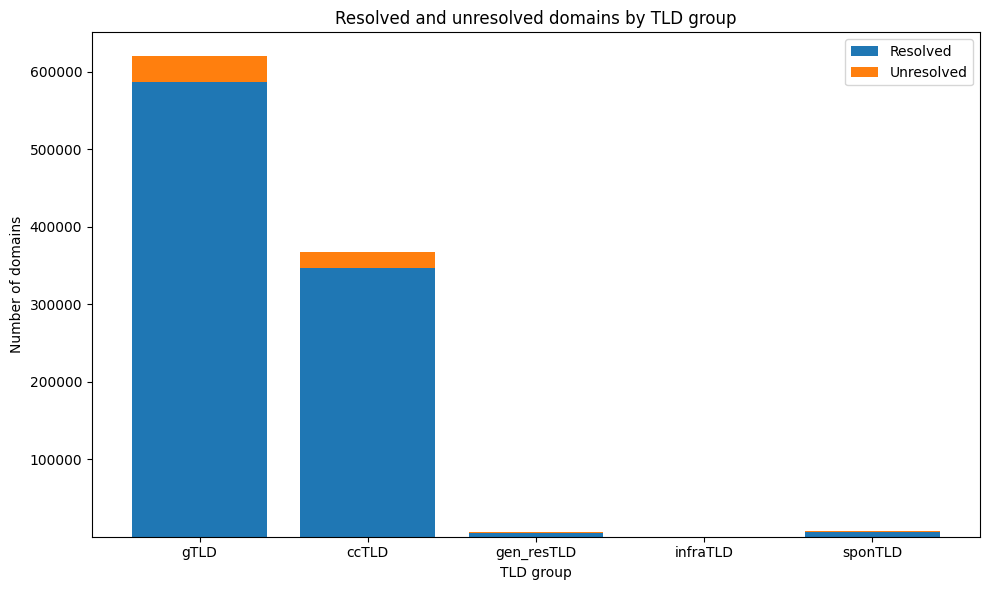

In [18]:
plot_data = plot_df[plot_df["group_code"] != "Total"].copy()

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(plot_data))

ax.bar(
    x,
    plot_data["resolved"],
    label="Resolved"
)

ax.bar(
    x,
    plot_data["unresolved"],
    bottom=plot_data["resolved"],
    label="Unresolved"
)

ax.set_xticks(list(x))
ax.set_xticklabels(plot_data["group_code"], rotation=0)
ax.set_ylabel("Number of domains")
ax.set_xlabel("TLD group")
ax.set_title("Resolved and unresolved domains by TLD group")
ax.legend()

for i, (_, row) in enumerate(plot_data.iterrows()):
    if row["resolved_extra"] > 0:
        ax.text(
            i,
            row["resolved"] + row["unresolved"],
            f'+{row["resolved_extra"]}',
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.savefig(
    fig_dir / "resolved_and_unresolved_domains_by_tld_group.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

##### Merging data

Displaying the categorized names dataframe before merging it with dependency results.


In [19]:
categorized_names_df

,domain,rank,tld,type,p_status
0,kunlunea.com,14896,com,generic,TLD
1,link-988betgcr.pro,960565,pro,generic-restricted,TLD
2,fiberflex.dk,995310,dk,country-code,parent_rel_does_not_exist
3,kiaspecialtools.com,985556,com,generic,TLD
4,quiz4dgg.space,965100,space,generic,TLD
...,...,...,...,...,...
999995,proteste.pt,41541,pt,country-code,TLD
999996,networkrail.co.uk,47450,uk,country-code,TLD
999997,cubicmotion.com,34544,com,generic,TLD
999998,queniuwx.com,24502,com,generic,TLD


Combining the resolved dependency dataframes into one summary dataframe and merging in rank and TLD metadata.


In [20]:
# grouping data into one dataframe
resolved_summary_df = pd.concat(
    [
        gTLD_summary_df.assign(group_code="gTLD"),
        ccTLD_summary_df.assign(group_code="ccTLD"),
        genTLD_summary_df.assign(group_code="gen-resTLD"),
        infTLD_summary_df.assign(group_code="infTLD"),
        sponTLD_summary_df.assign(group_code="sponTLD"),
    ],
    ignore_index=True
)
resolved_summary_df = resolved_summary_df.merge(
    categorized_names_df[["domain","rank", "tld", "type"]],
    on="domain",
    how="left"
)

Checking the number of rows in the combined resolved summary dataframe.


In [21]:
# checking if data was grouped correctly
len(resolved_summary_df)

945846

Counting missing TLD and type values after merging the resolved summary with categorized names.


In [22]:
# missing data in tld and type
missing_tld_count = resolved_summary_df["tld"].isna().sum()
missing_type_count = resolved_summary_df["type"].isna().sum()

print("Missing tld:", missing_tld_count)
print("Missing Type:", missing_type_count)

Missing tld: 0
Missing Type: 0


Checking missing TCB and type values in the resolved summary dataframe.


In [23]:
print("Missing TCB:", resolved_summary_df["TCB"].isna().sum())
print("Missing Type:", resolved_summary_df["type"].isna().sum())

Missing TCB: 0
Missing Type: 0


Previewing the resolved summary dataframe after the merge and missing-value checks.


In [24]:
resolved_summary_df.head(2)

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,group_code,rank,tld,type
0,kunlunea.com,1,1,3,1.0,3,"[ns5.aliyun.com, ns4.aliyun.com, ns3.aliyun.com]","[{'name_server_count': 1, 'name_servers': ['ns...","[{'source': 'kunlunea.com', 'target_zone': Non...",gTLD,14896,com,generic
1,kiaspecialtools.com,1,1,3,1.0,3,"[ns1.a2.impervasecuredns.net, ns1.a1.impervase...","[{'name_server_count': 1, 'name_servers': ['ns...","[{'source': 'kiaspecialtools.com', 'target_zon...",gTLD,985556,com,generic


Counting the number of unique TLDs represented in the resolved domain results.


In [25]:
# checking uniqe number of TLD in the resolved domains

unique_tld_count = resolved_summary_df["tld"].nunique()
print("Unique TLD count:", unique_tld_count)

Unique TLD count: 917


### Saving and loading Data
resolved_summary dataframe is saved in data/result folder no need to re-run above cell just load the data frame if above cells have been executed atleast once.m

Saving the resolved summary dataframe as a parquet file for reuse in later analysis.


In [49]:
try:
    out_dir = Path.cwd().parent / 'data' / 'result'
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / 'resolved_summary.parquet'
    resolved_summary_df.to_parquet(out_path, index=False)
    
except Exception as e:
    print(f"feiled:{e}")

Reloading the saved resolved summary parquet and displaying its first rows and shape.


In [3]:
# From now on we will be using categorized name list saved  in   data\names\categorized_names.parquet
file_path = Path.cwd().parent / 'data' / 'result' /  'resolved_summary.parquet'
resolved_summary_df = pd.read_parquet(file_path)
display(resolved_summary_df.head(2))
display(resolved_summary_df.shape)

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,group_code,rank,tld,type
0,kunlunea.com,1,1,3,1.0,3,"[ns5.aliyun.com, ns4.aliyun.com, ns3.aliyun.com]","[{'name_server_count': 1, 'name_servers': ['ns...","[{'source': 'kunlunea.com', 'target_zone': Non...",gTLD,14896,com,generic
1,kiaspecialtools.com,1,1,3,1.0,3,"[ns1.a2.impervasecuredns.net, ns1.a1.impervase...","[{'name_server_count': 1, 'name_servers': ['ns...","[{'source': 'kiaspecialtools.com', 'target_zon...",gTLD,985556,com,generic


(945846, 13)

## TCB Analysis

### TLD present by 2004 refered as OLD TLD

By the time the the survey for the paper(Perils of Transitive Trust in the Domain Name System) was done July 22, 2004; The internet only had 14 TLD. 
The orginal seven (.com, .edu, .gov, .int, .mil, .net, and .org) created in 1980s and the other seven created  in the first expansion of DNS which included(.aero, .biz, .coop, .info, .museum, .name, and .pro.)

In this section we analyse the TCB from the Tranco list from Domain only from the 14 TLD.

Previewing resolved summary rows before starting the old-TLD analysis.


In [26]:
resolved_summary_df.head(2)

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,group_code,rank,tld,type
0,kunlunea.com,1,1,3,1.0,3,"[ns5.aliyun.com, ns4.aliyun.com, ns3.aliyun.com]","[{'name_server_count': 1, 'name_servers': ['ns...","[{'source': 'kunlunea.com', 'target_zone': Non...",gTLD,14896,com,generic
1,kiaspecialtools.com,1,1,3,1.0,3,"[ns1.a2.impervasecuredns.net, ns1.a1.impervase...","[{'name_server_count': 1, 'name_servers': ['ns...","[{'source': 'kiaspecialtools.com', 'target_zon...",gTLD,985556,com,generic


###### getting ccTLD present by 2004  by looking at registration Date.

Run this once, data is saved and and loaded on the coming cell

Scraping IANA root-zone metadata to collect TLD names, types, and managers.


In [27]:
# Getting TLD type information from IANA, to get ccTLD names.
url = "https://www.iana.org/domains/root/db"
html = requests.get(url).text
soup = BeautifulSoup(html, "html.parser")

rows = []
for tr in soup.select("table tbody tr"):
    tds = tr.find_all("td")
    if len(tds) >= 3:
        a = tds[0].find("a")
        Domain = a.get_text(strip=True) if a else tds[0].get_text(strip=True)
        href = a["href"] if a and a.has_attr("href") else None
        
        punycode = None
        if href:
            filename = href.split("/")[-1]
            punycode = filename.replace(".html", "")
        else:
            full_url = None

        rows.append({
            "Domain": Domain,
            "tld": punycode,
            "type": tds[1].get_text(" ", strip=True),
            "manager": tds[2].get_text(" ", strip=True),
        })

iana_list = pd.DataFrame(rows)
print("Example of the results with reanded domain .餐厅 with its respective extracted punycode(tld)and type")
print(iana_list[iana_list["Domain"] == ".укр"])
print("\n")
iana_list

Example of the results with reanded domain .餐厅 with its respective extracted punycode(tld)and type
     Domain        tld          type  \
1484   .укр  xn--j1amh  country-code   

                                                manager  
1484  Ukrainian Network Information Centre (UANIC), ...  




,Domain,tld,type,manager
0,.aaa,aaa,generic,"American Automobile Association, Inc."
1,.aarp,aarp,generic,AARP
2,.abarth,abarth,generic,Not assigned
3,.abb,abb,generic,ABB Ltd
4,.abbott,abbott,generic,"Abbott Laboratories, Inc."
...,...,...,...,...
1589,.zippo,zippo,generic,Not assigned
1590,.zm,zm,country-code,Zambia Information and Communications Technolo...
1591,.zone,zone,generic,"Binky Moon, LLC"
1592,.zuerich,zuerich,generic,Kanton Zürich (Canton of Zurich)


Filtering the IANA metadata to country-code TLDs and preparing the fields needed for registration-date lookup.


In [28]:
iana_list_ccTLD = iana_list[iana_list["type"]=="country-code"]
iana_list_ccTLD=iana_list_ccTLD.drop(columns=["manager","type"])
iana_list_ccTLD.reset_index(drop=True)
display(iana_list_ccTLD)

,Domain,tld
10,.ac,ac
18,.ad,ad
22,.ae,ae
26,.af,af
30,.ag,ag
...,...,...
1576,.ye,ye
1582,.yt,yt
1584,.za,za
1590,.zm,zm


Defining a helper function to fetch and extract registration dates from individual IANA TLD pages.


In [29]:
def extract_iana_registration_date(tld):


    tld_clean = tld.lower().strip().lstrip(".")
    url = f"https://www.iana.org/domains/root/db/{tld_clean}.html"

    try:
        response = requests.get(url, timeout=20)
        response.raise_for_status()
    except requests.RequestException as e:
        return {
            "tld": tld_clean,
            "registration_date": None,
            "status": "request_failed",
            "url": url,
            "error": str(e)
        }

    soup = BeautifulSoup(response.text, "html.parser")
    text = soup.get_text(" ", strip=True)

    match = re.search(r"Registration date\s+(\d{4}-\d{2}-\d{2})", text)

    if match:
        registration_date = match.group(1)
        status = "found"
    else:
        registration_date = None
        status = "not_found"

    return {
        "tld": tld_clean,
        "registration_date": registration_date,
        "status": status,
        "url": url,
        "error": None
    }

Collecting registration dates for country-code TLDs with a polite delay between IANA requests.


In [30]:
# Getting ccTLD registration Data

rows = []

for cctld in iana_list_ccTLD.itertuples():
    row = extract_iana_registration_date(cctld.tld)
    rows.append(row)

    time.sleep(0.3)   # polite delay, avoid hitting IANA too fast

iana_registration_df = pd.DataFrame(rows)

iana_registration_df

,tld,registration_date,status,url,error
0,ac,1997-12-19,found,https://www.iana.org/domains/root/db/ac.html,None
1,ad,1996-01-09,found,https://www.iana.org/domains/root/db/ad.html,None
2,ae,1992-12-01,found,https://www.iana.org/domains/root/db/ae.html,None
3,af,1997-10-16,found,https://www.iana.org/domains/root/db/af.html,None
4,ag,1991-09-03,found,https://www.iana.org/domains/root/db/ag.html,None
...,...,...,...,...,...
311,ye,1996-08-19,found,https://www.iana.org/domains/root/db/ye.html,None
312,yt,1997-11-17,found,https://www.iana.org/domains/root/db/yt.html,None
313,za,1990-11-07,found,https://www.iana.org/domains/root/db/za.html,None
314,zm,1994-03-25,found,https://www.iana.org/domains/root/db/zm.html,None


Checking which country-code TLD registration dates were not found during scraping.


In [31]:
display((iana_registration_df["status"] != "found").sum())

display(iana_registration_df[iana_registration_df["status"] != "found"])

np.int64(1)

,tld,registration_date,status,url,error
67,eh,NaN,not_found,https://www.iana.org/domains/root/db/eh.html,None


Filling the missing registration date for .eh using its available historical update date.


In [32]:
# .eh does not have registratin date but it does have last update date 1999-09-26
iana_registration_df.loc[
    iana_registration_df["tld"] == "eh",
    "registration_date"
] = "1999-09-26"


display((iana_registration_df["registration_date"] == "NAN").sum())

np.int64(0)

Saving the collected country-code TLD registration dates as a parquet file.


In [33]:
try:
    out_dir = Path.cwd().parent / 'data' / 'names'
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / 'ccTLD_registration_date_may_10_2026.parquet'
    iana_registration_df.to_parquet(out_path, index=False)
    
except Exception as e:
    print(f"feiled:{e}")

###### loading ccTLD_registration Date

Loading ccTLD with Registration Date

Reloading the saved country-code TLD registration-date parquet and checking its shape.


In [34]:
# From now on we will be using categorized name list saved  in   data\names\categorized_names.parquet
file_path = Path.cwd().parent / 'data' / 'names' /  'ccTLD_registration_date_may_10_2026.parquet'
iana_registration_df = pd.read_parquet(file_path)
display(iana_registration_df.head(2))
display(iana_registration_df.shape)

,tld,registration_date,status,url,error
0,ac,1997-12-19,found,https://www.iana.org/domains/root/db/ac.html,None
1,ad,1996-01-09,found,https://www.iana.org/domains/root/db/ad.html,None


(316, 5)

Converting registration dates to datetime values and selecting country-code TLDs registered before July 22, 1999.


In [35]:
iana_registration_df["registration_date"] = pd.to_datetime(iana_registration_df["registration_date"])
old_ccTLD_df=iana_registration_df[iana_registration_df["registration_date"] < pd.to_datetime("1999-07-22")]
display(old_ccTLD_df.head(2))
display(old_ccTLD_df.shape)

,tld,registration_date,status,url,error
0,ac,1997-12-19,found,https://www.iana.org/domains/root/db/ac.html,None
1,ad,1996-01-09,found,https://www.iana.org/domains/root/db/ad.html,None


(240, 5)

Building the old-TLD list and filtering resolved Tranco domains to those TLDs.


In [36]:
# 2004 TLD

oldTLD = ['com', 'edu', 'gov', 'int', 'mil', 'net', 'org','aero', 'biz', 'coop', 'info', 'museum', 'name', 'pro']

oldTLD.extend( old_ccTLD_df["tld"].tolist())

Tranco_with_oldTLD = resolved_summary_df[resolved_summary_df['tld'].isin(oldTLD)]

##### TCB

Plotting the CDF of TCB values for domains under old TLDs.


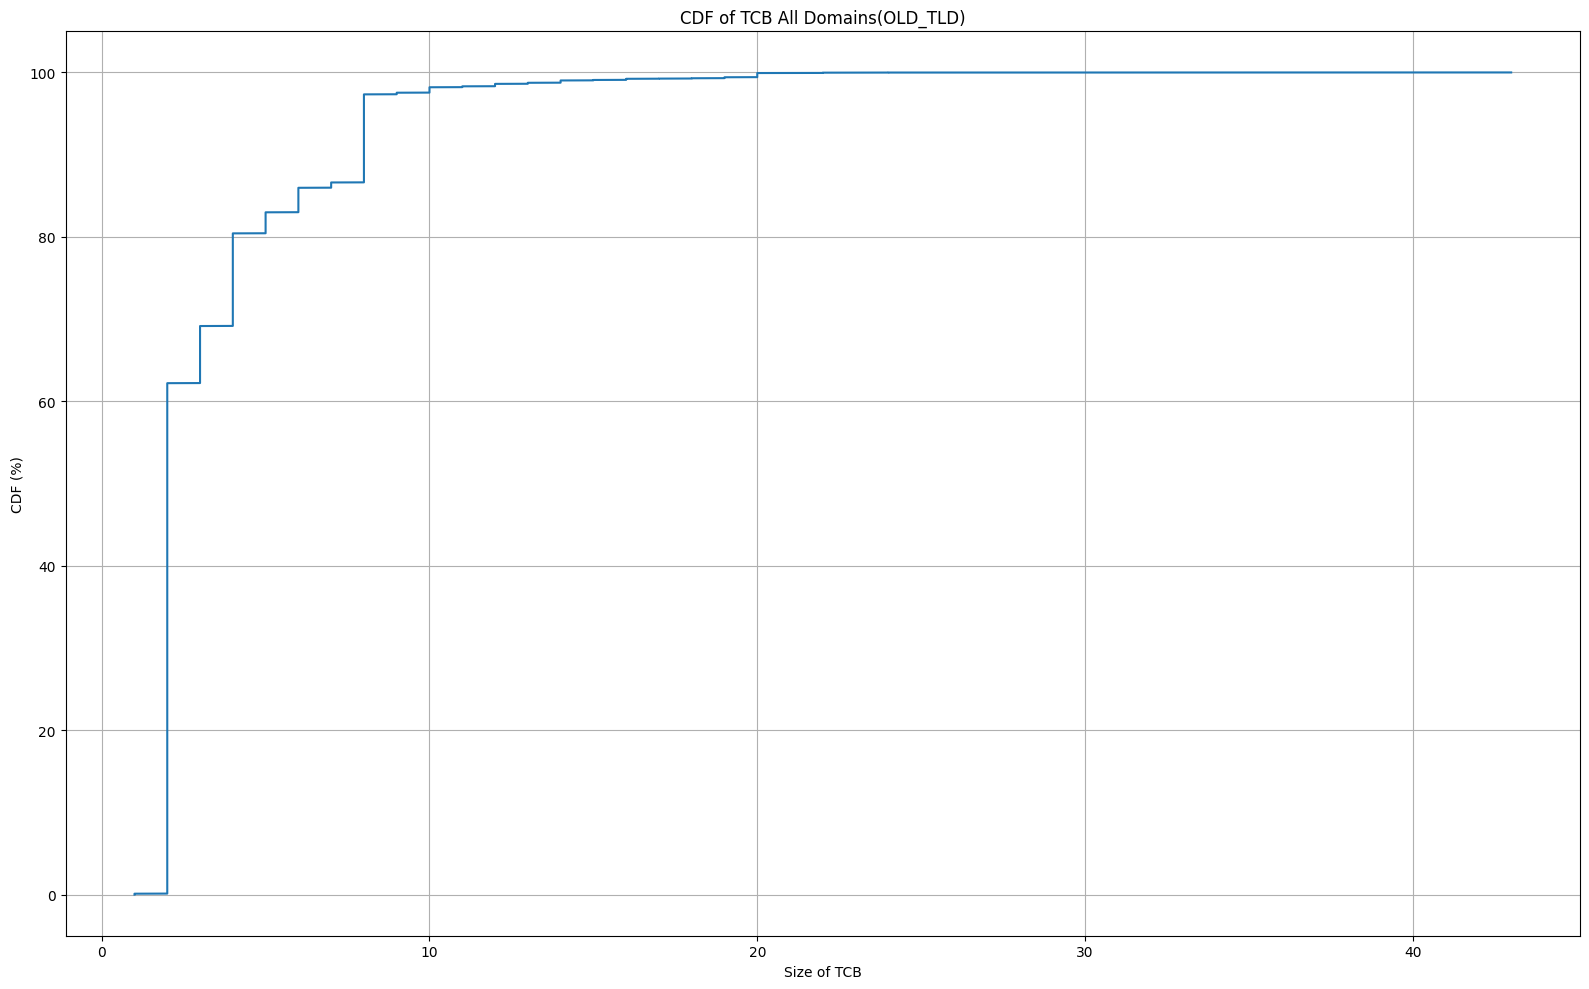

In [37]:
tcb = Tranco_with_oldTLD["TCB"]


tcb_sorted = np.sort(tcb)
cdf = np.arange(1, len(tcb_sorted) + 1) / len(tcb_sorted)

plt.figure(figsize=(16, 10))
plt.plot(tcb_sorted, cdf * 100)

plt.xlabel("Size of TCB")
plt.ylabel("CDF (%)")
plt.title("CDF of TCB All Domains(OLD_TLD)")

plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / "CDF of TCB All Domains(OLD_TLD).png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

##### Mean, Median and Parcentile

Computing summary statistics and threshold percentages for old-TLD TCB values.


In [38]:
tcb = Tranco_with_oldTLD["TCB"].dropna().to_numpy()
mean_tcb = np.mean(tcb)
median_tcb = np.median(tcb)

x = 10
tcb = np.array(tcb)

pct_below_or_equal = np.mean(tcb < x) * 100
pct_above = np.mean(tcb > x) * 100

# maximum
tcb = Tranco_with_oldTLD["TCB"]
max_tcb = np.maximum.reduce(tcb)

print(f"Maximum TCB: {max_tcb}")
print(f"mean of TCB  {mean_tcb:.2f}")
print(f"median of TCB {median_tcb:.2f}")
print(f"Percentage with TCB < {x}: {pct_below_or_equal:.2f}%")
print(f"Percentage with TCB > {x}: {pct_above:.2f}%")

Maximum TCB: 43
mean of TCB  3.49
median of TCB 2.00
Percentage with TCB < 10: 97.53%
Percentage with TCB > 10: 1.80%


##### ccTLD vs gTLD

Comparing old-TLD TCB distributions between ccTLD and non-ccTLD domains.


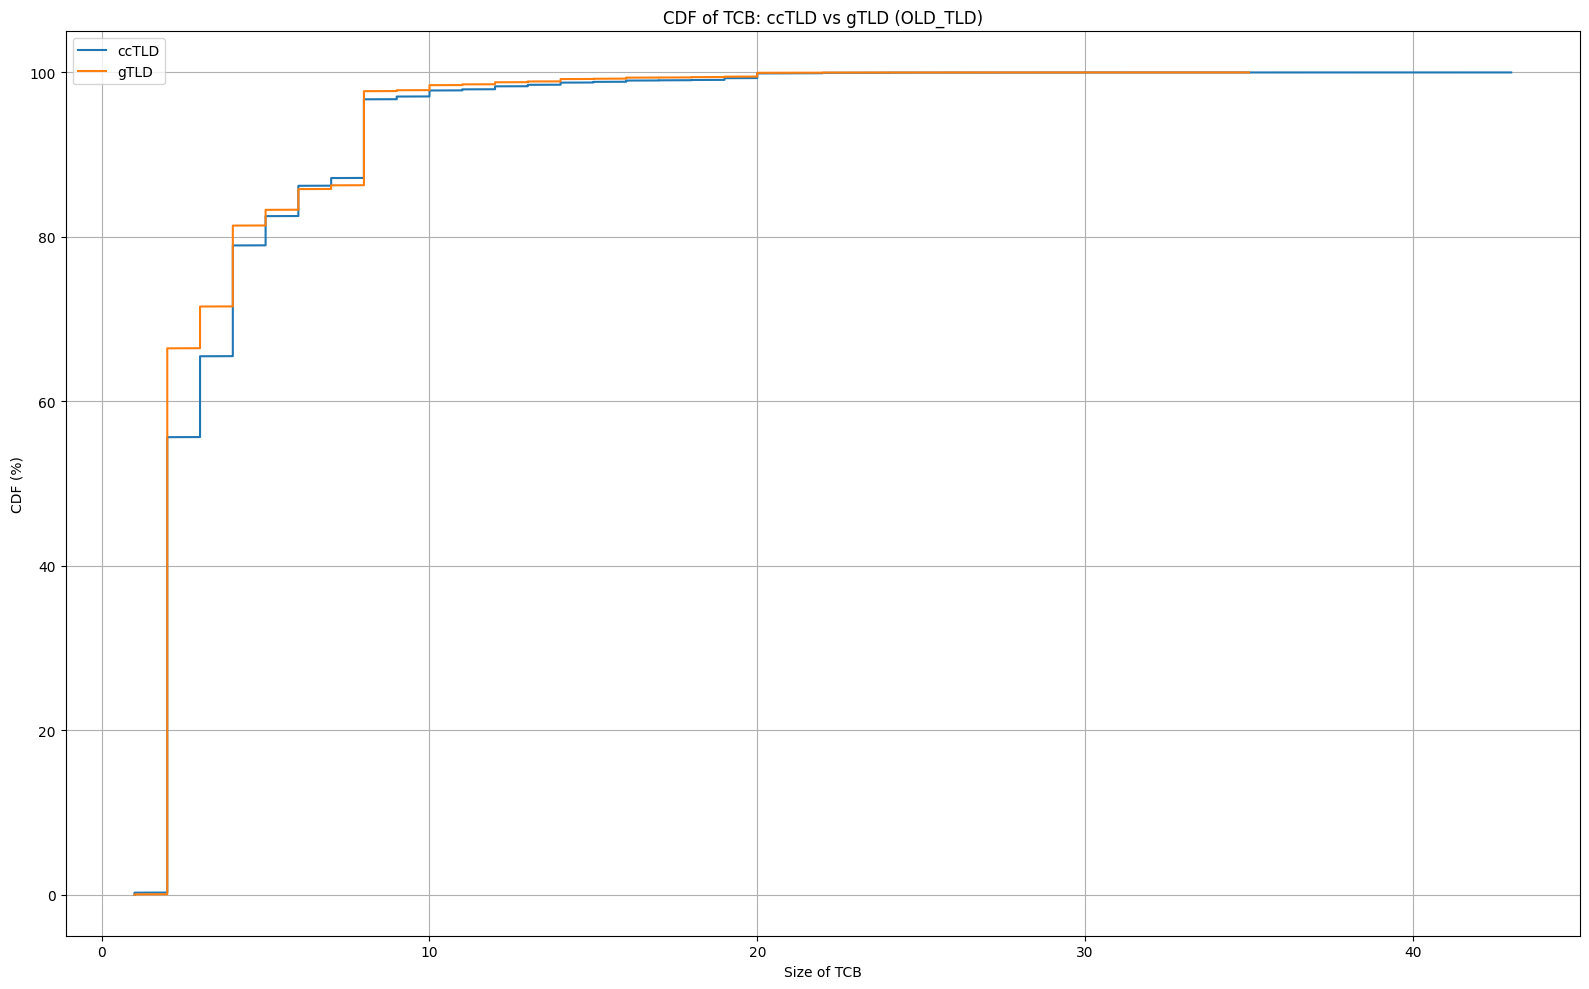

In [39]:
df = Tranco_with_oldTLD.copy()

df["TLD_status"] = np.where(
    df["group_code"] == "ccTLD",
    "ccTLD",
    "gTLD"
)

plt.figure(figsize=(16,10))

for group_name, group_df in df.groupby("TLD_status"):
    tcb = group_df["TCB"].dropna().to_numpy()

    if len(tcb) == 0:
        continue

    tcb_sorted = np.sort(tcb)
    cdf = np.arange(1, len(tcb_sorted) + 1) / len(tcb_sorted)

    plt.plot(tcb_sorted, cdf * 100, label=group_name)

plt.xlabel("Size of TCB")
plt.ylabel("CDF (%)")
plt.title("CDF of TCB: ccTLD vs gTLD (OLD_TLD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / "CDF of TCB ccTLD vs gTLD (OLD_TLD).png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

##### Top 15 large average TCB

Finding and plotting the top 15 old ccTLDs by average TCB.


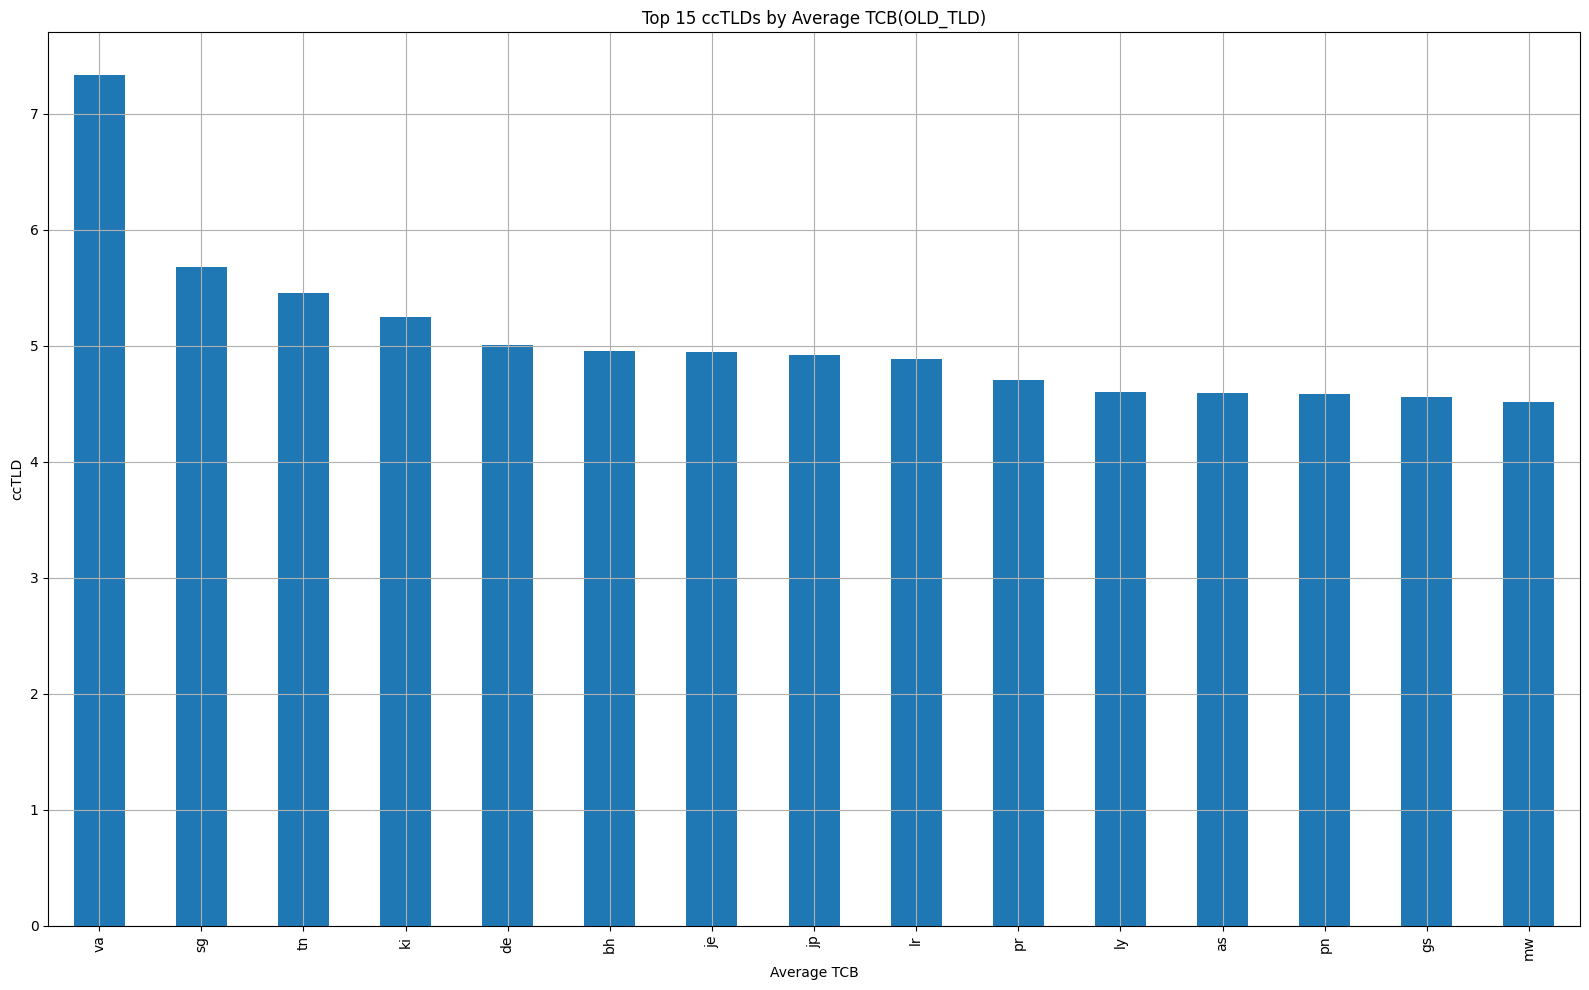

In [40]:
df = Tranco_with_oldTLD.copy()

cctld_df = df[df["group_code"] == "ccTLD"]



top15_cctld = (
    cctld_df
    .groupby("tld")["TCB"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

ax = top15_cctld.plot(kind="bar", figsize=(16, 10))


plt.xlabel("Average TCB")
plt.grid(True)
plt.ylabel("ccTLD")
plt.title("Top 15 ccTLDs by Average TCB(OLD_TLD)")
plt.tight_layout()
plt.savefig(fig_dir / "Top 15 ccTLDs by Average TCB(OLD_TLD).png", dpi=300, bbox_inches="tight")
plt.show()

The Curious case of .ua and .xn--j1amh(.укр) For ukraine. 

As .укр was registered after 2004 it disapeard from the average largest TCB on ccTLD   hoever ukraine is number 2

Finding and plotting the top 15 old non-ccTLD groups by average TCB.


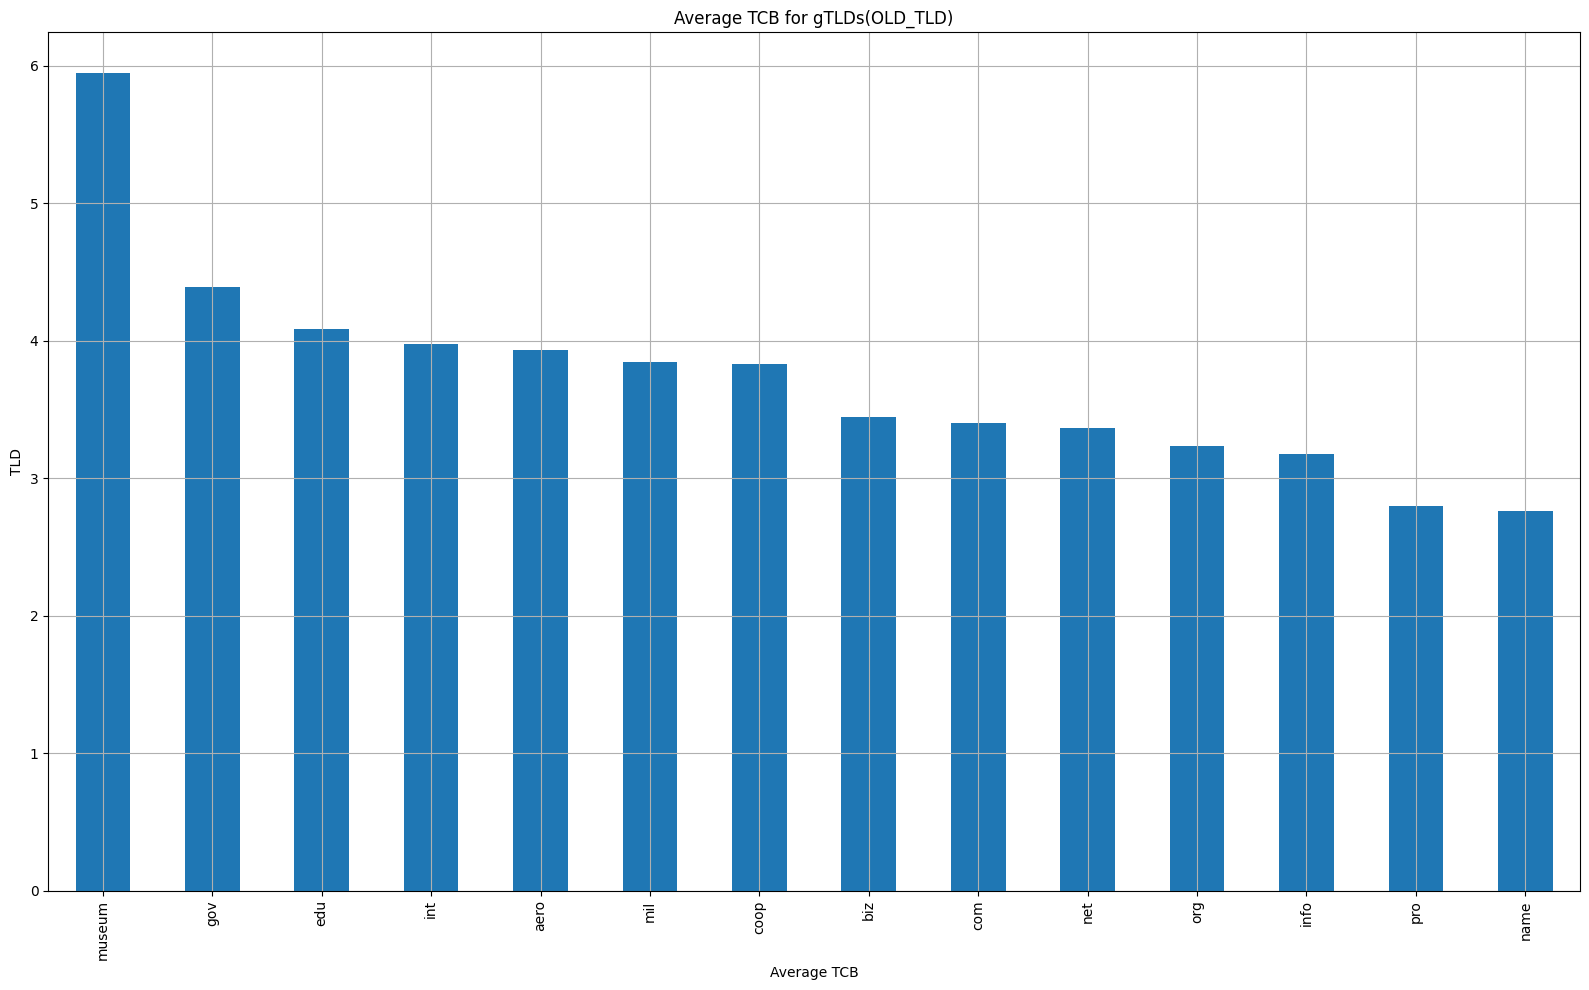

In [41]:
general_df = Tranco_with_oldTLD[df["group_code"] != "ccTLD"]
general_tld_avg = (
    general_df
    .groupby("tld")["TCB"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

ax = general_tld_avg.plot(kind="bar", figsize=(16, 10))

plt.xlabel("Average TCB")
plt.ylabel("TLD")
plt.grid(True)
plt.title("Average TCB for gTLDs(OLD_TLD)")
plt.tight_layout()
plt.savefig(fig_dir / "Average TCB for gTLDs(OLD_TLD).png", dpi=300, bbox_inches="tight")
plt.show()

### ALL TLD

##### Distribution of TCB for the resolved domains.

Plotting the CDF of TCB values for all resolved domains.


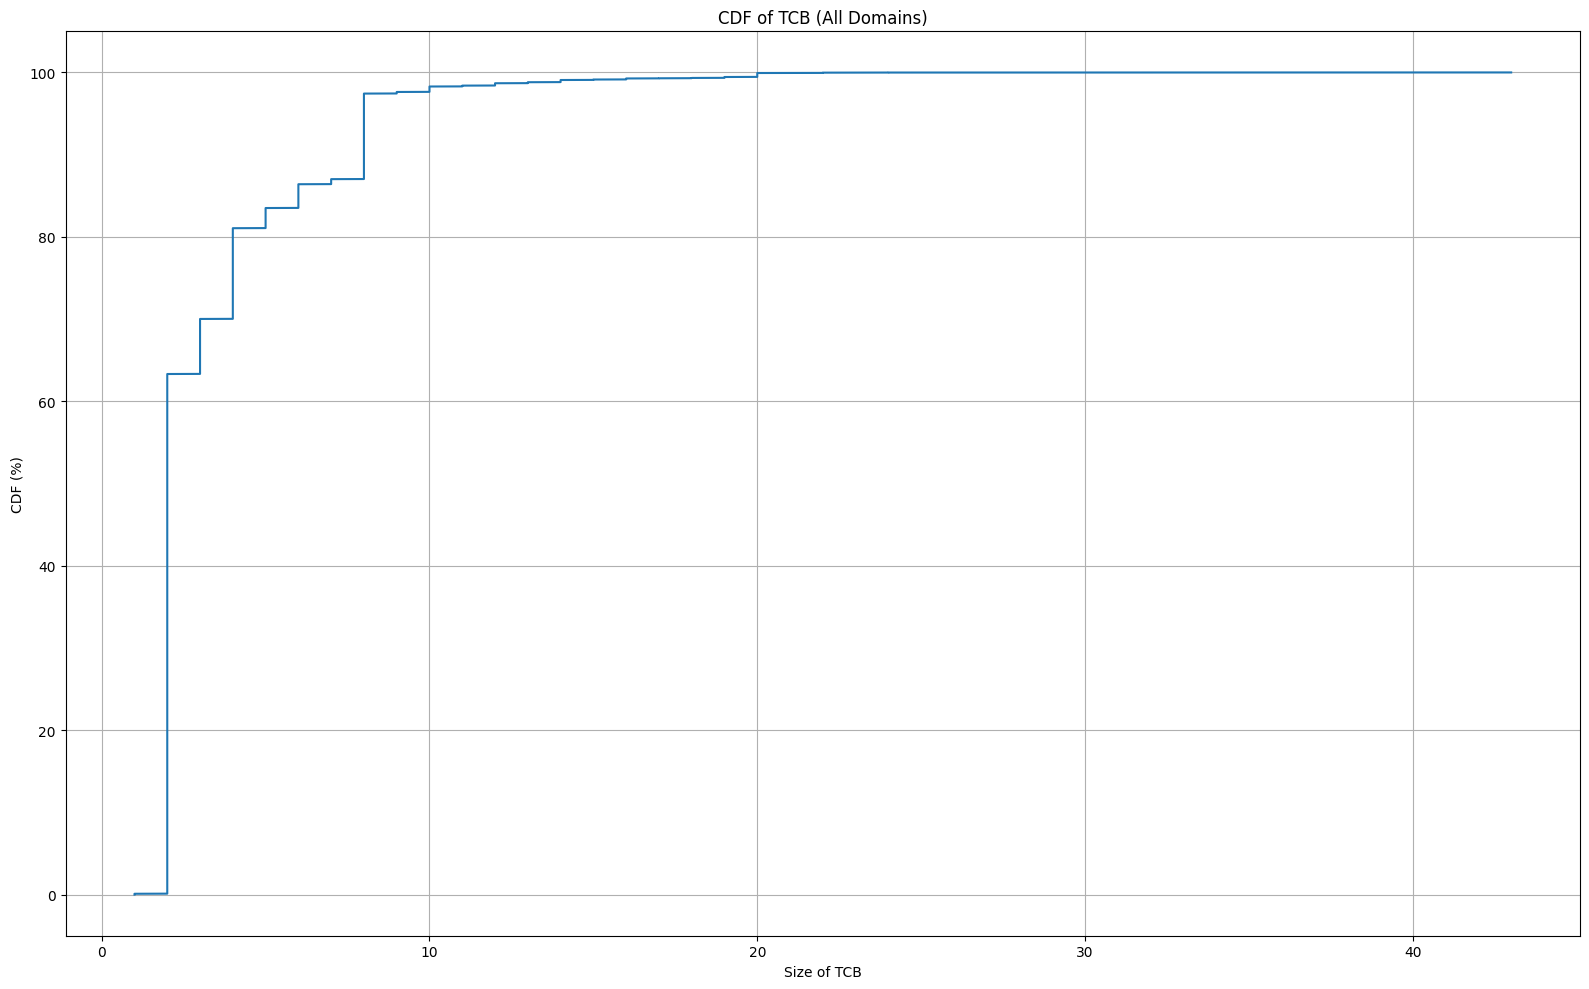

In [42]:
tcb = resolved_summary_df["TCB"]
tcb_sorted = np.sort(tcb)
cdf = np.arange(1, len(tcb_sorted) + 1) / len(tcb_sorted)

plt.figure(figsize=(16, 10))
plt.plot(tcb_sorted, cdf * 100)

plt.xlabel("Size of TCB")
plt.ylabel("CDF (%)")
plt.title("CDF of TCB (All Domains)")

plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / "CDF of TCB (All Domains).png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

Plotting a violin distribution of TCB values for all resolved domains.


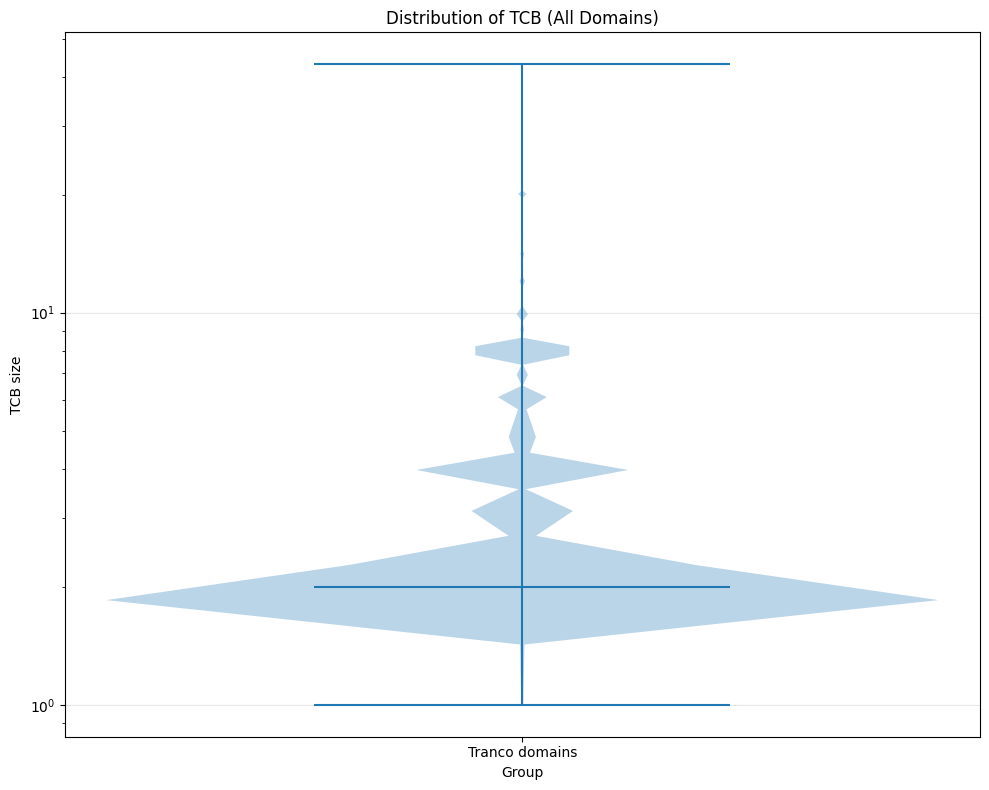

In [43]:
df = resolved_summary_df.copy()

tcb = df["TCB"].dropna().to_numpy()

plt.figure(figsize=(10, 8))

plt.violinplot(
    [tcb],
    showmeans=False,
    showmedians=True
)

plt.xticks([1], ["Tranco domains"])
plt.xlabel("Group")
plt.ylabel("TCB size")
plt.title("Distribution of TCB (All Domains)")

plt.grid(axis="y", alpha=0.3)
plt.yscale("log")
plt.tight_layout()
plt.savefig(fig_dir / "Violin TCB Tranco Domains.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

##### Mean, Median and Parcentile

Computing mean, median, percentile, and maximum statistics for all resolved-domain TCB values.


In [44]:
tcb = resolved_summary_df["TCB"].dropna().to_numpy()
mean_tcb = np.mean(tcb)
median_tcb = np.median(tcb)

x = 10
tcb = np.array(tcb)

pct_below_or_equal = np.mean(tcb < x) * 100
pct_above = np.mean(tcb > x) * 100

# maximum
tcb = resolved_summary_df["TCB"]
max_tcb = np.maximum.reduce(tcb)

print(f"Maximum TCB: {max_tcb}")


print(f"mean of TCB  {mean_tcb:.2f}")
print(f"median of TCB {median_tcb:.2f}")
print(f"Percentage with TCB < {x}: {pct_below_or_equal:.2f}%")
print(f"Percentage with TCB > {x}: {pct_above:.2f}%")

Maximum TCB: 43
mean of TCB  3.44
median of TCB 2.00
Percentage with TCB < 10: 97.62%
Percentage with TCB > 10: 1.71%


##### TCB by different TLD groups

Plotting TCB CDF curves grouped by TLD type for all resolved domains.


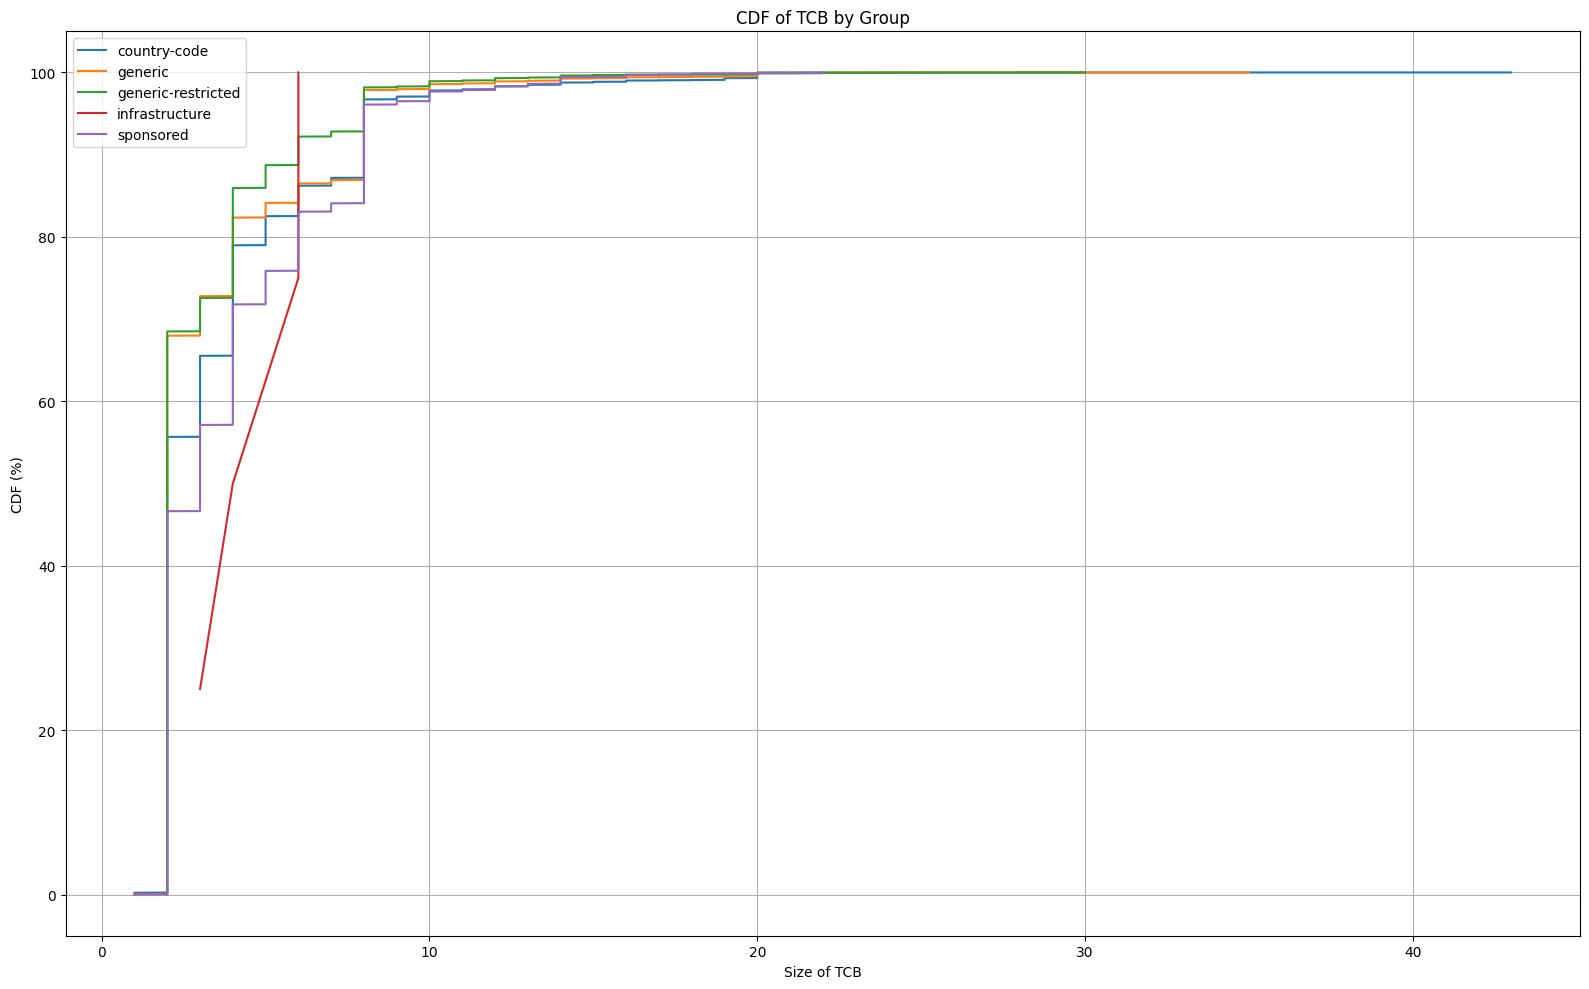

In [45]:
df = resolved_summary_df.copy()


plt.figure(figsize=(16, 10))

for group_name, group_df in df.groupby("type"):
    tcb = group_df["TCB"].dropna().to_numpy()
    
    if len(tcb) == 0:
        continue
    
    tcb_sorted = np.sort(tcb)
    cdf = np.arange(1, len(tcb_sorted) + 1) / len(tcb_sorted)
    
    plt.plot(tcb_sorted, cdf * 100, label=group_name)

plt.xlabel("Size of TCB")
plt.ylabel("CDF (%)")
plt.title("CDF of TCB by Group")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / "CDF of TCB by Group.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

##### ccTLD vs gTLD

Comparing TCB CDF curves between ccTLD and non-ccTLD domains.


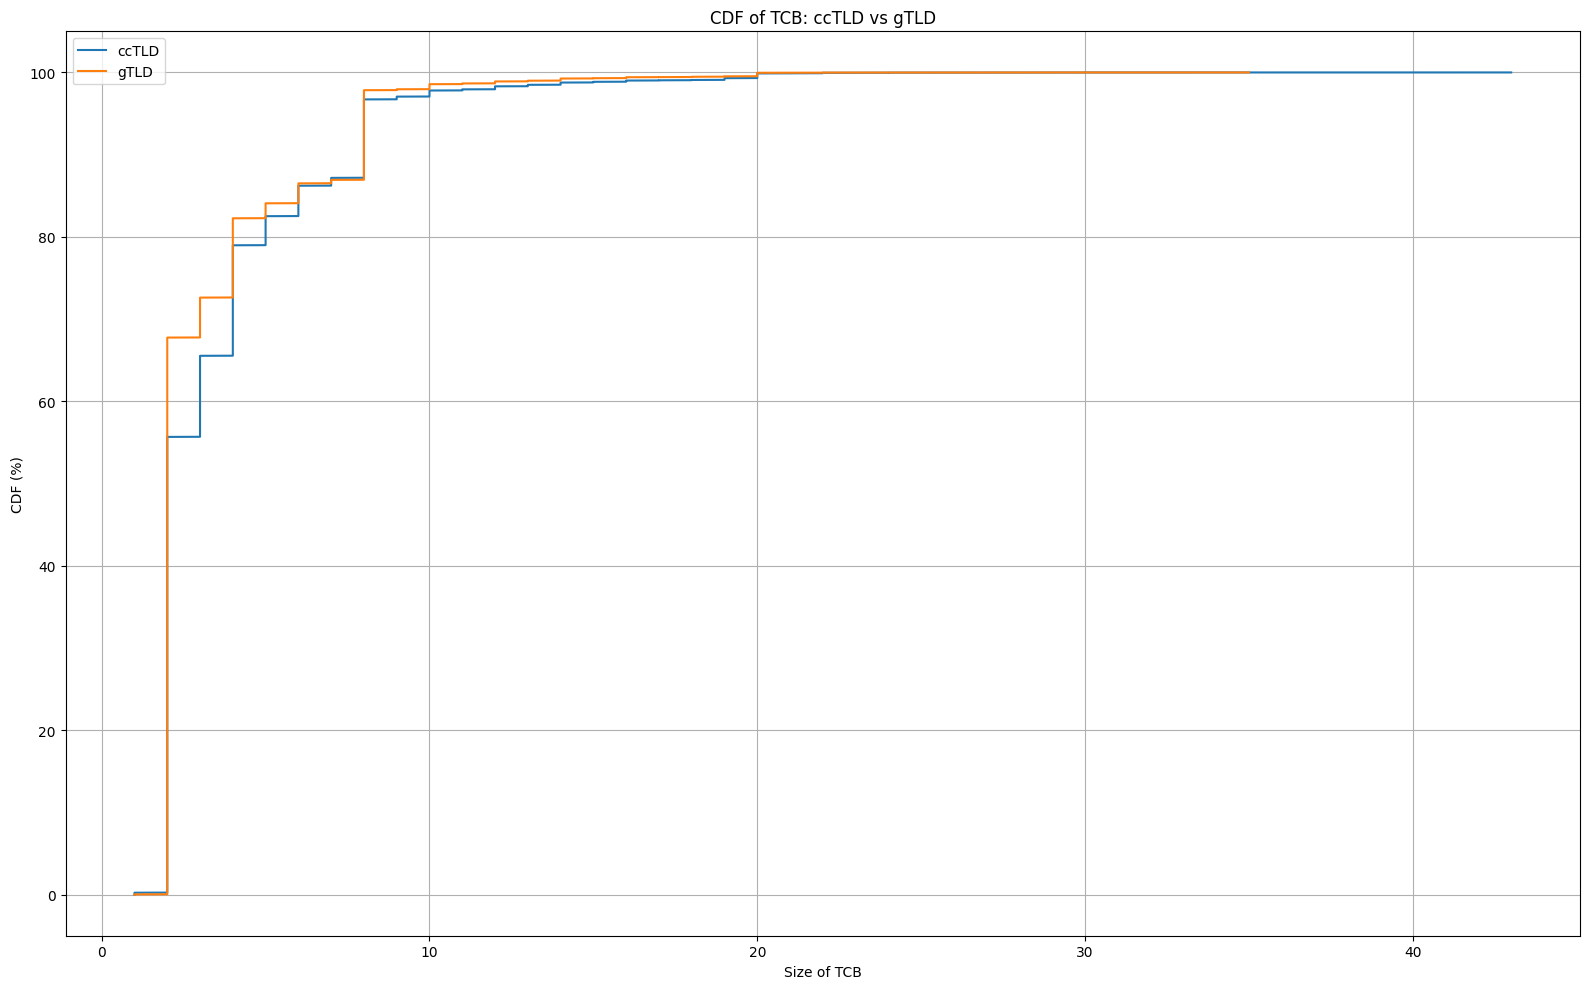

In [46]:
df = resolved_summary_df.copy()

df["TLD_status"] = np.where(
    df["group_code"] == "ccTLD",
    "ccTLD",
    "gTLD"
)

plt.figure(figsize=(16, 10))

for group_name, group_df in df.groupby("TLD_status"):
    tcb = group_df["TCB"].dropna().to_numpy()

    if len(tcb) == 0:
        continue

    tcb_sorted = np.sort(tcb)
    cdf = np.arange(1, len(tcb_sorted) + 1) / len(tcb_sorted)

    plt.plot(tcb_sorted, cdf * 100, label=group_name)

plt.xlabel("Size of TCB")
plt.ylabel("CDF (%)")
plt.title("CDF of TCB: ccTLD vs gTLD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_dir / "CDF of TCB ccTLD vs gTLD.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

##### Top 15 large average TCB

Finding and plotting the top 15 ccTLDs by average TCB across all resolved domains.


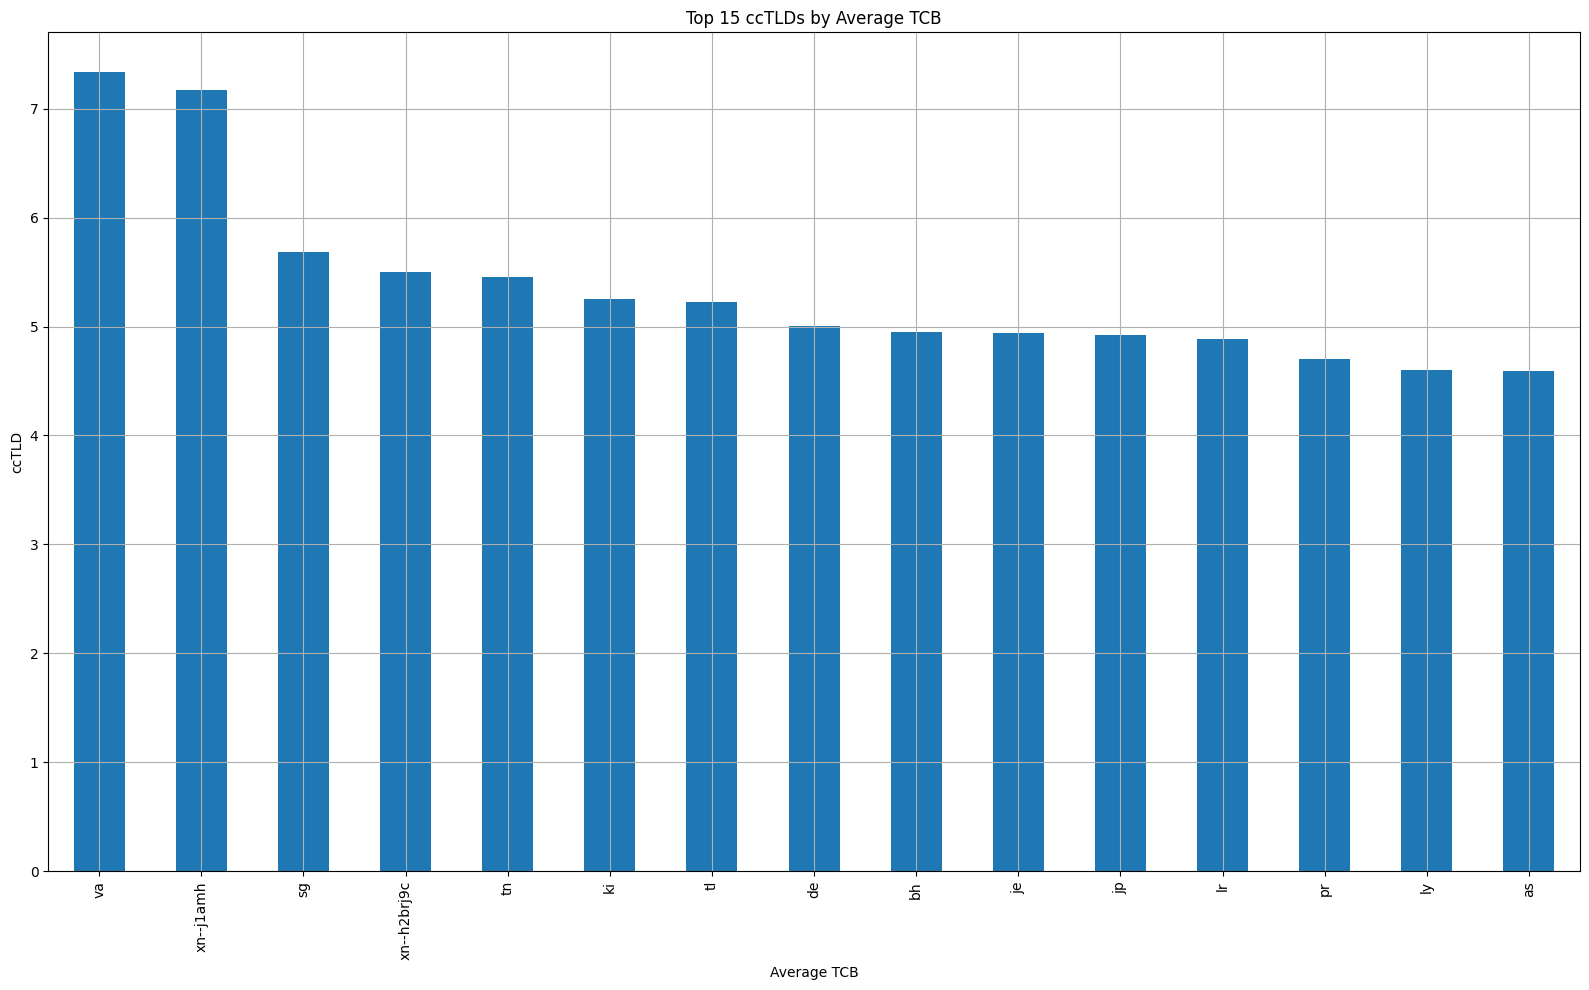

In [47]:
df = resolved_summary_df.copy()

cctld_df = df[df["group_code"] == "ccTLD"]

top15_cctld = (
    cctld_df
    .groupby("tld")["TCB"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

ax = top15_cctld.plot(kind="bar", figsize=(16, 10))


plt.xlabel("Average TCB")
plt.grid(True)
plt.ylabel("ccTLD")
plt.title("Top 15 ccTLDs by Average TCB")
plt.tight_layout()
plt.savefig(fig_dir / "Top 15 ccTLDs by Average TCB.png", dpi=300, bbox_inches="tight")
plt.show()

Finding and plotting the top 15 non-ccTLD groups by average TCB across all resolved domains.


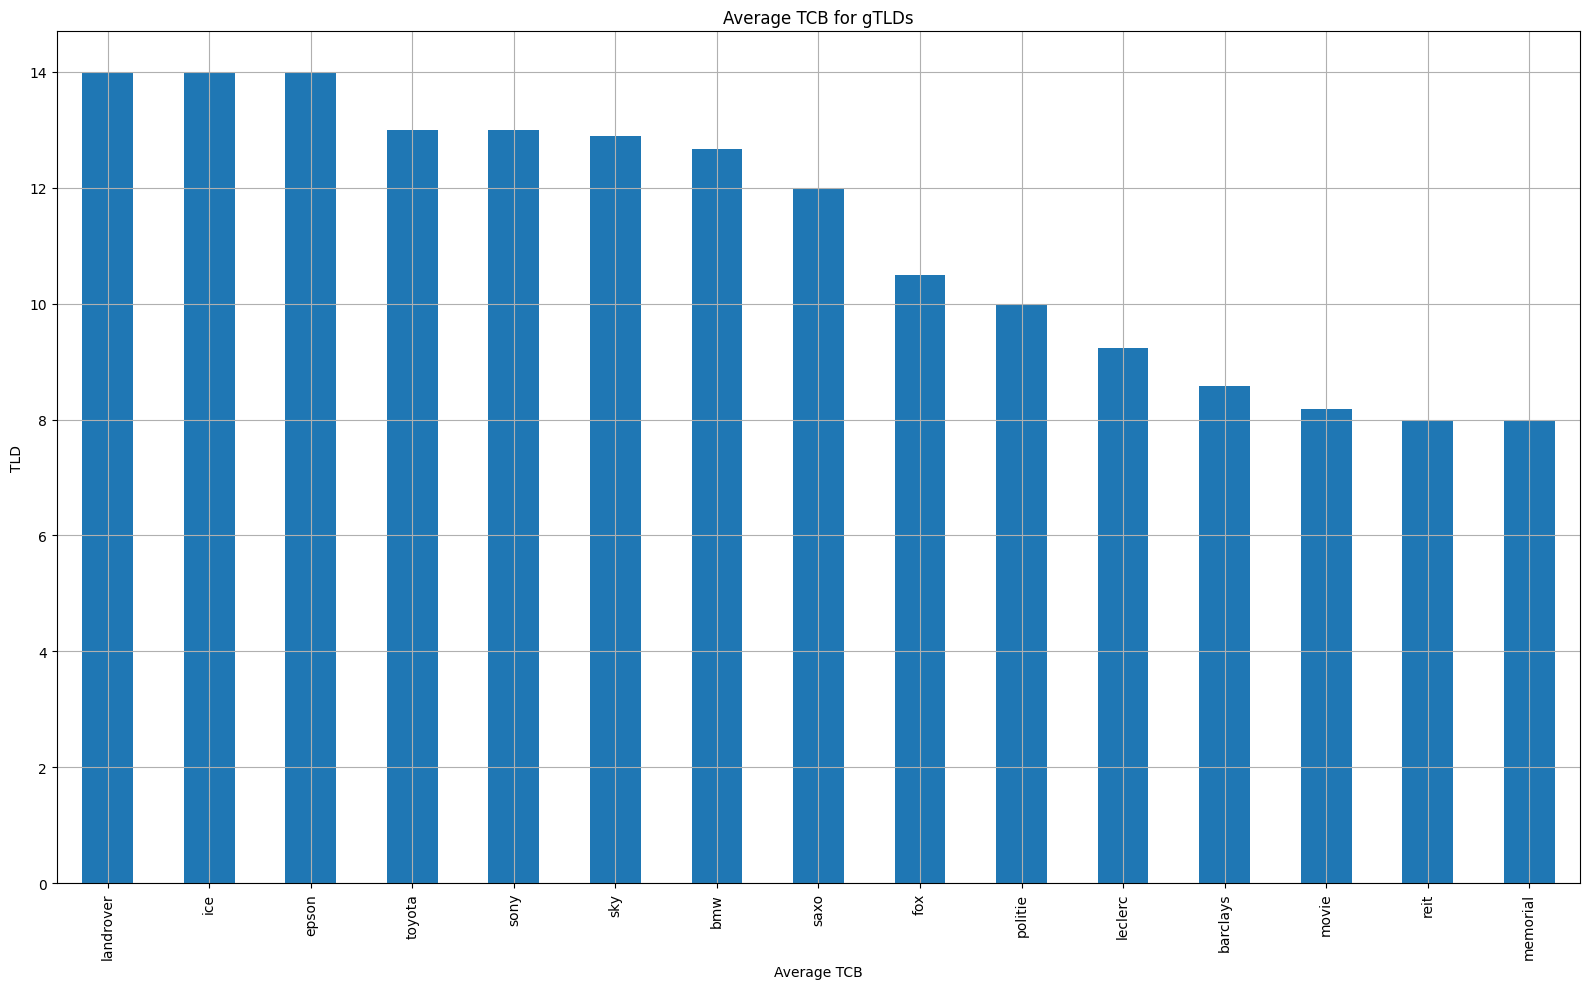

In [48]:
df = resolved_summary_df.copy()
general_df = df[df["group_code"] != "ccTLD"]
general_tld_avg = (
    general_df
    .groupby("tld")["TCB"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

ax = general_tld_avg.plot(kind="bar", figsize=(16, 10))

plt.xlabel("Average TCB")
plt.ylabel("TLD")
plt.grid(True)
plt.title("Average TCB for gTLDs")
plt.tight_layout()
plt.savefig(fig_dir / "Average TCB for gTLDs.png", dpi=300, bbox_inches="tight")
plt.show()

#### Group size

The average TCB size par group might be skewed by the number of domain by that group. Looking into the tld domain count vs average size distribution.

Aggregating each TLD by domain count and average TCB to study group-size effects.


In [4]:
tld_groups_size_tcb_average = (
    resolved_summary_df.groupby("tld")
    .agg(
        domain_count = ("TCB","count"),
        tcb_average = ("TCB","mean")
).reset_index()
)

Previewing the TLD group-size and average-TCB summary dataframe.


In [54]:
tld_groups_size_tcb_average.head(2)

,tld,domain_count,tcb_average
0,abb,5,6.400000
1,abbott,13,6.615385


Rechecking the first rows of the TLD group-size summary before plotting.


In [55]:
tld_groups_size_tcb_average.head(2)

,tld,domain_count,tcb_average
0,abb,5,6.400000
1,abbott,13,6.615385


Plotting TLD domain count against average TCB on a log-scaled y-axis.


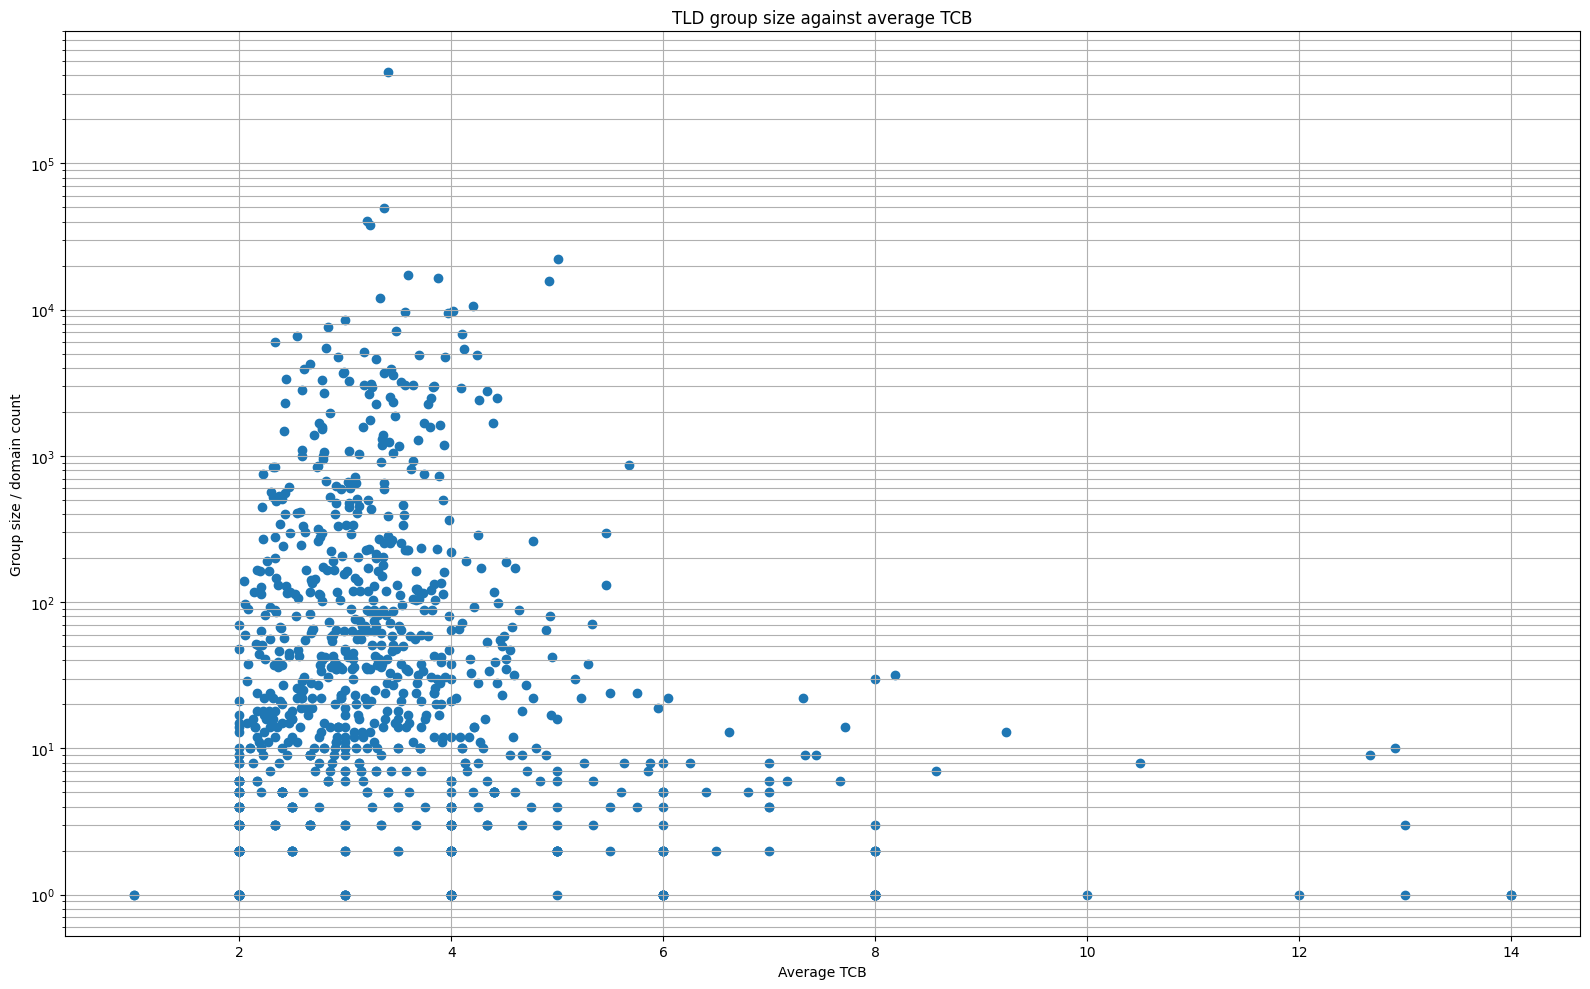

In [153]:
plt.figure(figsize=(16,10))

plt.scatter(
    tld_groups_size_tcb_average["tcb_average"],
    tld_groups_size_tcb_average["domain_count"]
)

plt.yscale("log")

plt.ylabel("Group size / domain count")
plt.xlabel("Average TCB")
plt.title("TLD group size against average TCB")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

##### Annotating outliers

Outliers  groups with more than 10K doain or average more than  10 on TCB

Selecting large or high-average-TCB TLD groups as outliers for annotation.


In [5]:
outliers = tld_groups_size_tcb_average[(tld_groups_size_tcb_average["domain_count"]>=10000) | (tld_groups_size_tcb_average["tcb_average"] >= 10 )]
outliers.head(20)


,tld,domain_count,tcb_average
88,bmw,9,12.666667
99,br,16465,3.874947
174,com,419203,3.404382
212,de,22246,5.008541
254,epson,1,14.000000
302,fox,8,10.500000
389,ice,1,14.000000
397,in,12019,3.327315
408,io,10557,4.206593
427,jp,15722,4.920812


Plotting TLD group size against average TCB with labels for selected outliers.


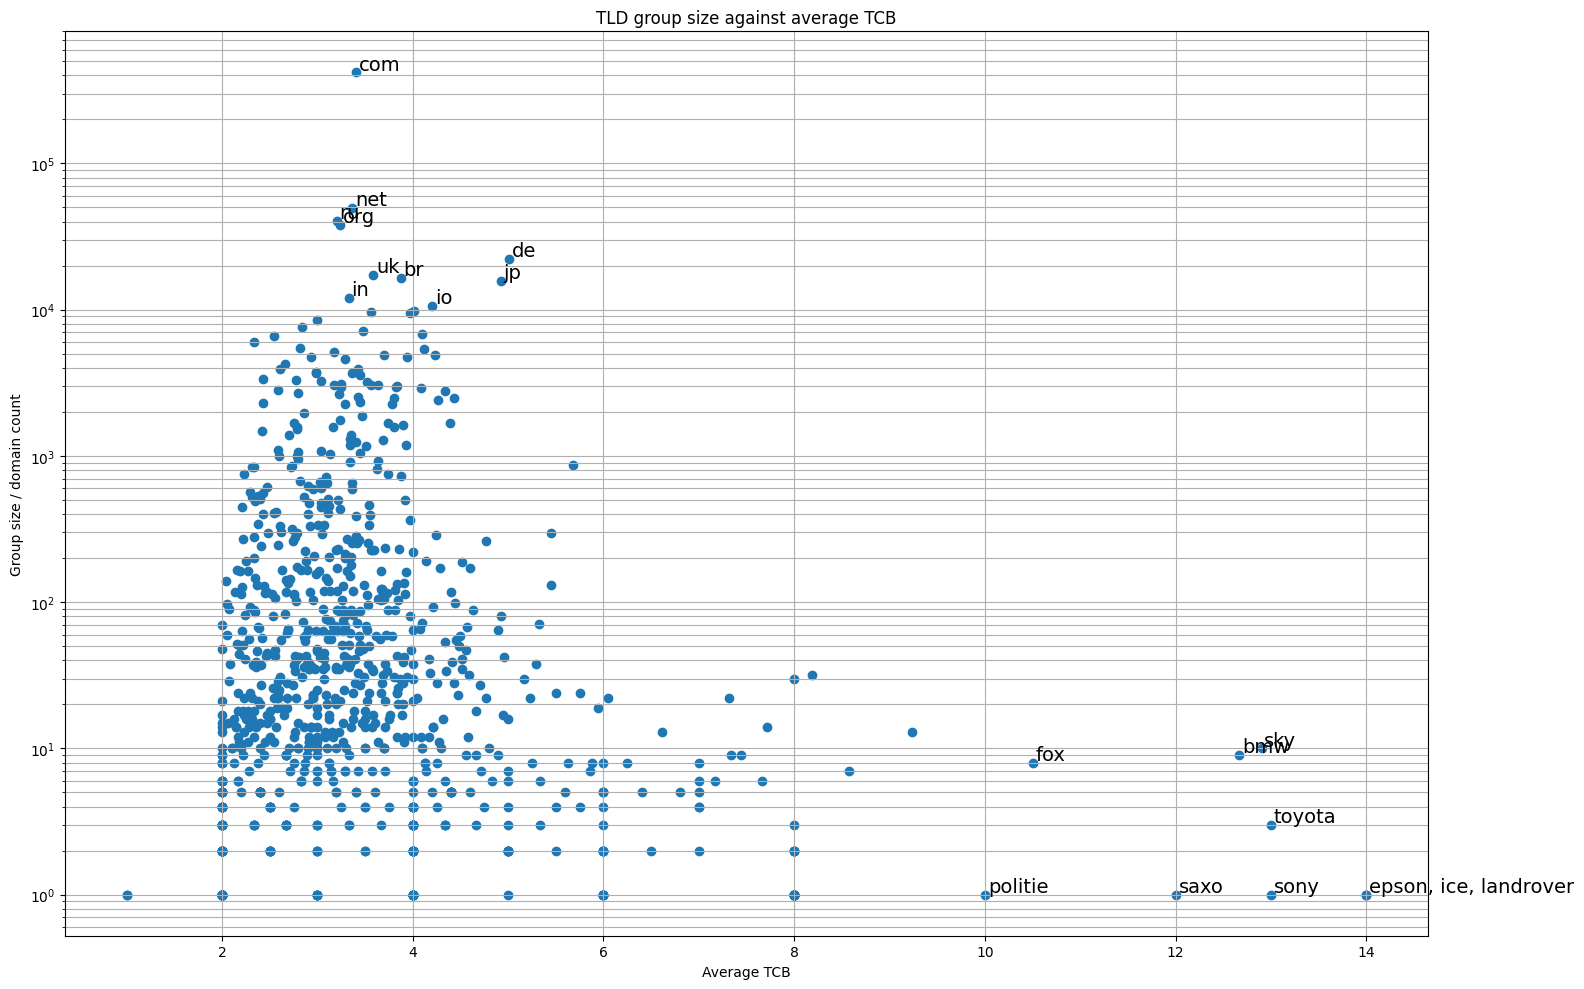

In [6]:
plt.figure(figsize=(16,10))

plt.scatter(
    tld_groups_size_tcb_average["tcb_average"],
    tld_groups_size_tcb_average["domain_count"]
)

label_points = (
    outliers
    .groupby(["tcb_average", "domain_count"])["tld"]
    .apply(lambda x: ", ".join(x))
    .reset_index()
)

for row in label_points.itertuples():
    plt.annotate(
        row.tld,
        (row.tcb_average, row.domain_count),
        textcoords="offset points",
        xytext=(2,2),
        fontsize=14, 
        ha="left"
    )

plt.yscale("log")

plt.ylabel("Group size / domain count")
plt.xlabel("Average TCB")
plt.title("TLD group size against average TCB")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

smaller groups tend to have larger TCB

2 with 8 in a group will have 8 as average 
while one with 14 will have 14 as average.

If mean cant help me what can  can we have a metric that has some kind of weight 
is there a statistical method for this ?

##### Number of how many groups have domain size equal to x?

Calculating how many TLD groups meet several minimum domain-count thresholds.


In [154]:
tld_groups = resolved_summary_df.groupby("tld").size()

print("TLD groups size distribution")

for x in [5, 10, 50, 100, 1000]:
    percent_at_least = (tld_groups >= x).mean() * 100

    print(
        f"x = {x}: >= {x}: {percent_at_least:.2f}%"
    )

TLD groups size distribution
x = 5: >= 5: 75.35%
x = 10: >= 10: 63.03%
x = 50: >= 50: 34.79%
x = 100: >= 100: 26.06%
x = 1000: >= 1000: 9.16%


Plotting TLD group size against average TCB with horizontal threshold reference lines.


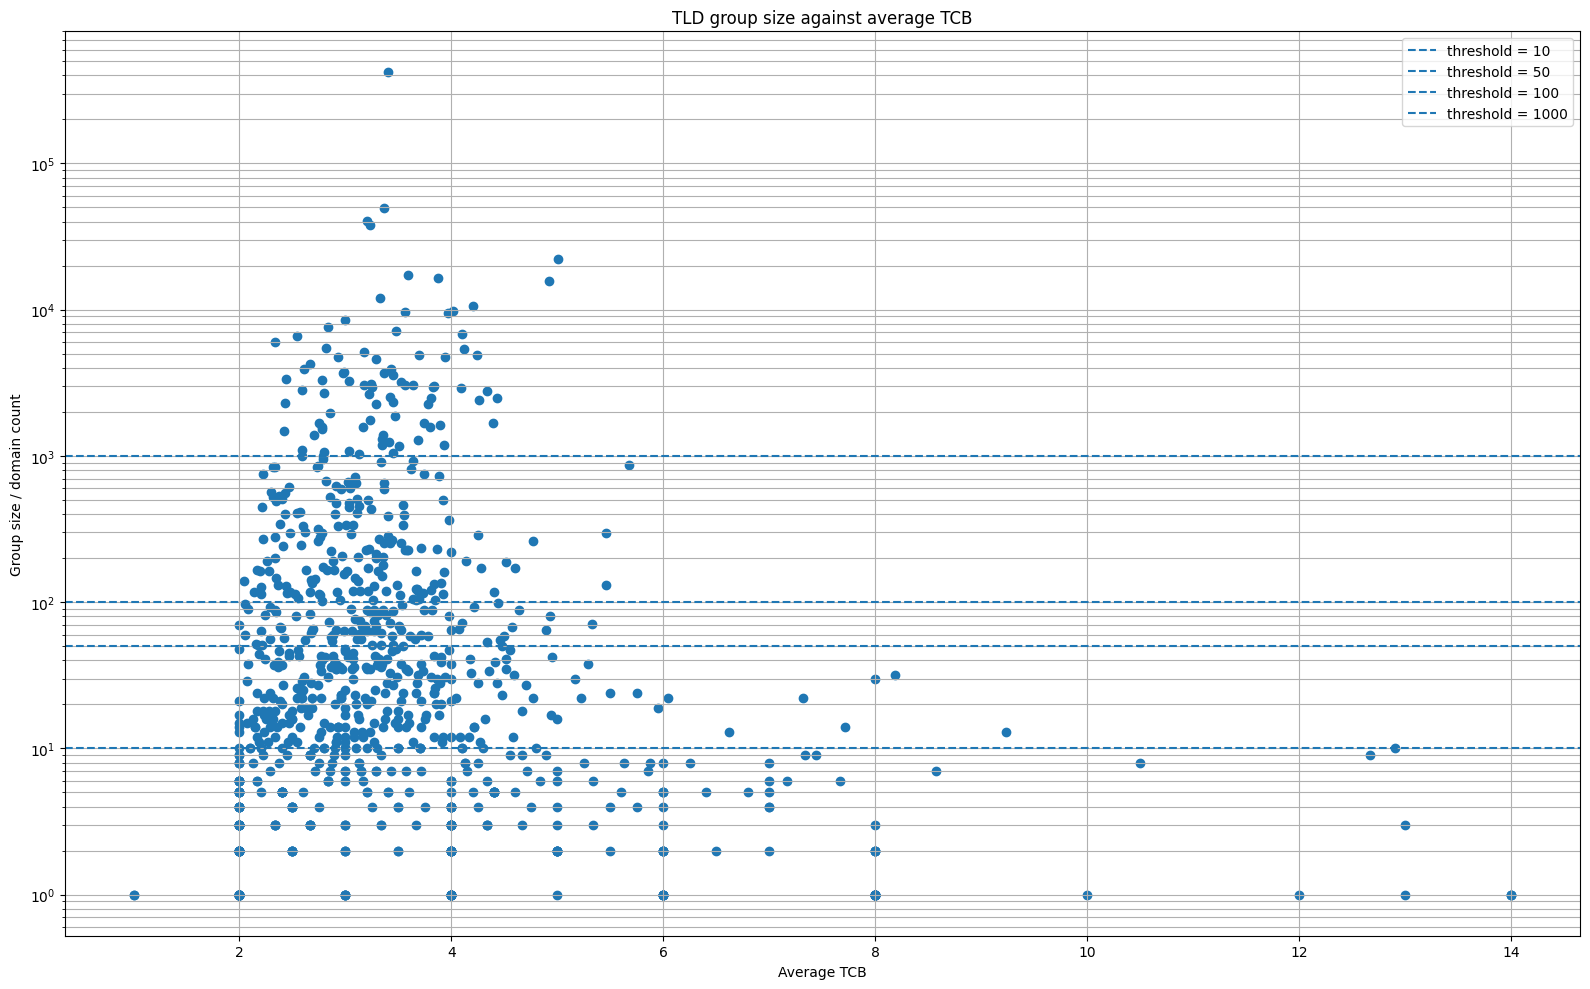

In [155]:
plt.figure(figsize=(16,10))

plt.scatter(
    tld_groups_size_tcb_average["tcb_average"],
    tld_groups_size_tcb_average["domain_count"]
)

plt.yscale("log")

for x in [10, 50, 100, 1000]:
    plt.axhline(x, linestyle="--", label=f"threshold = {x}")

plt.ylabel("Group size / domain count")
plt.xlabel("Average TCB")
plt.title("TLD group size against average TCB")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

##### Average on TCB on TLD with threshold above 10

Filtering TLD groups to those with at least 10 domains for more stable averages.


In [ ]:
threshold = 10

filtered_tld_groups = tld_groups_size_tcb_average[
    tld_groups_size_tcb_average["domain_count"] >= threshold
]


minimum group-size threshold of 10 domains. Therefore, average TCB was computed only for TLD groups with at least 10 domains. This removes very small groups whose averages may be unstable while retaining about 60% of the TLD groups.

Displaying the filtered TLD groups that satisfy the minimum group-size threshold.


In [158]:
filtered_tld_groups

,tld,domain_count,tcb_average
1,abbott,13,6.615385
3,ac,163,3.012270
4,academy,65,3.523077
8,ad,54,2.870370
10,ae,757,3.737120
...,...,...,...
911,za,2479,3.807584
913,zip,37,2.405405
914,zm,82,3.304878
915,zone,227,3.559471


Creating a resolved-domain subset limited to TLDs with at least 10 domains.


In [166]:
tld_with_10_and_above= filtered_tld_groups["tld"].tolist()

reslovde_with_TLD_threshold = resolved_summary_df[resolved_summary_df['tld'].isin(tld_with_10_and_above)]

reslovde_with_TLD_threshold.shape

(944635, 13)

Plotting the top 15 ccTLDs by average TCB after applying the group-size threshold.


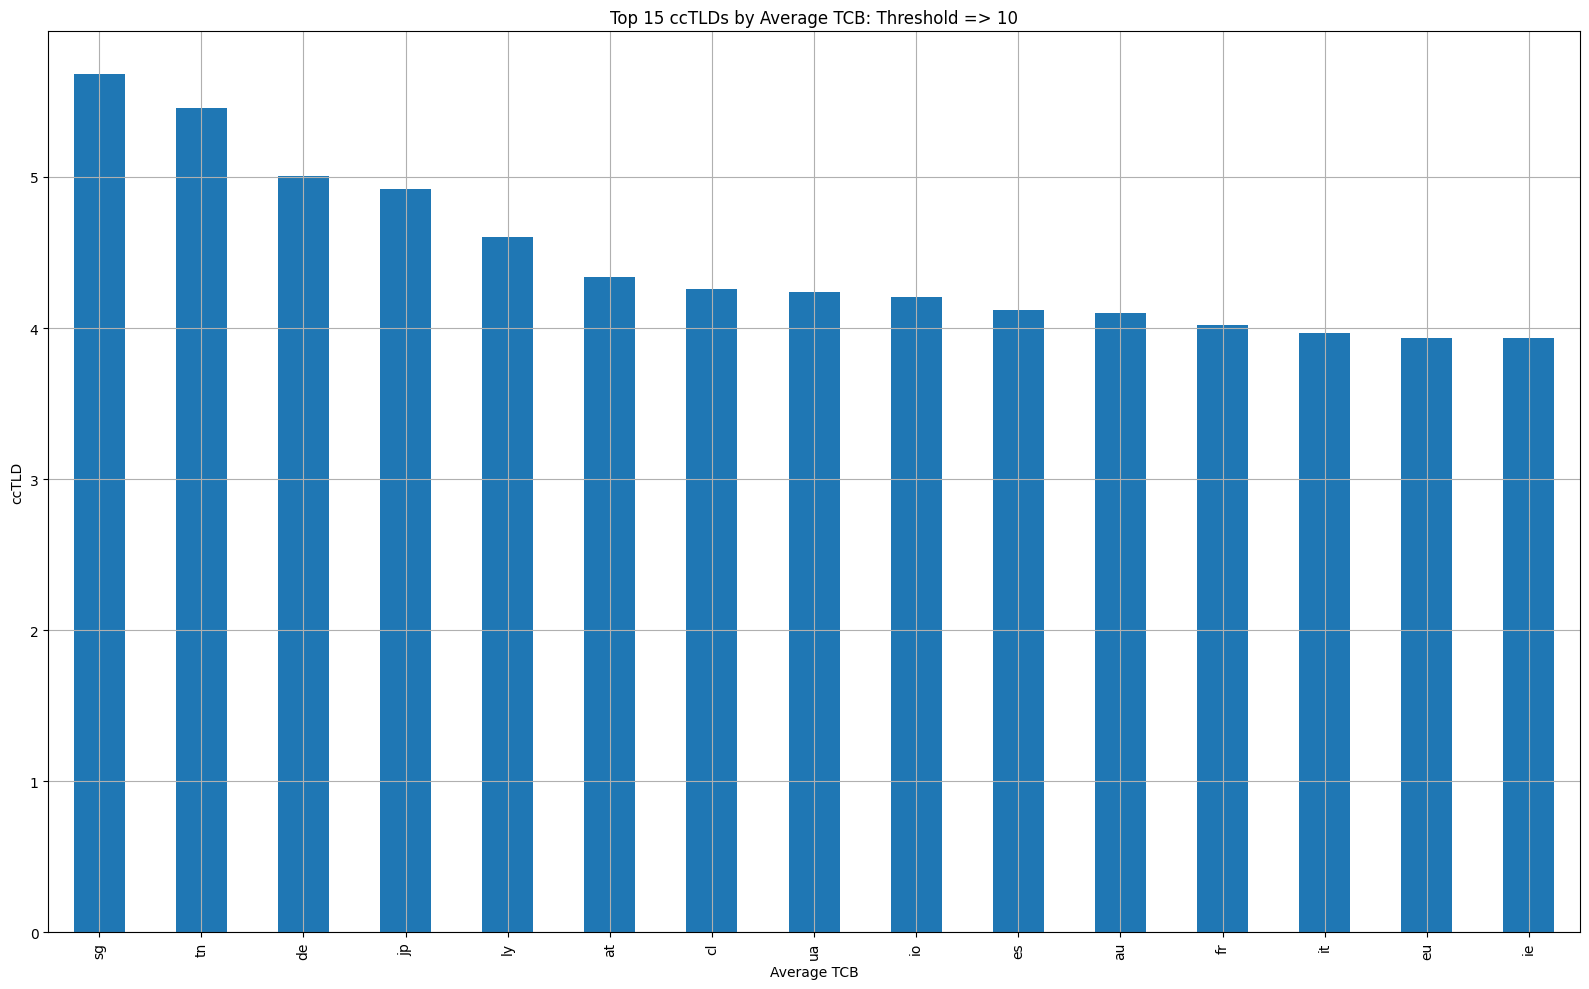

In [197]:
df = reslovde_with_TLD_threshold.copy()

cctld_df = df[df["group_code"] == "ccTLD"]

top15_cctld = (
    cctld_df
    .groupby("tld")["TCB"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

ax = top15_cctld.plot(kind="bar", figsize=(16, 10))


plt.xlabel("Average TCB")
plt.grid(True)
plt.ylabel("ccTLD")
plt.title("Top 15 ccTLDs by Average TCB: Threshold => 10")
plt.tight_layout()
plt.savefig(fig_dir / "Top 15 ccTLDs by Average TCB.png", dpi=300, bbox_inches="tight")
plt.show()

Plotting the top 15 non-ccTLD groups by average TCB after applying the group-size threshold.


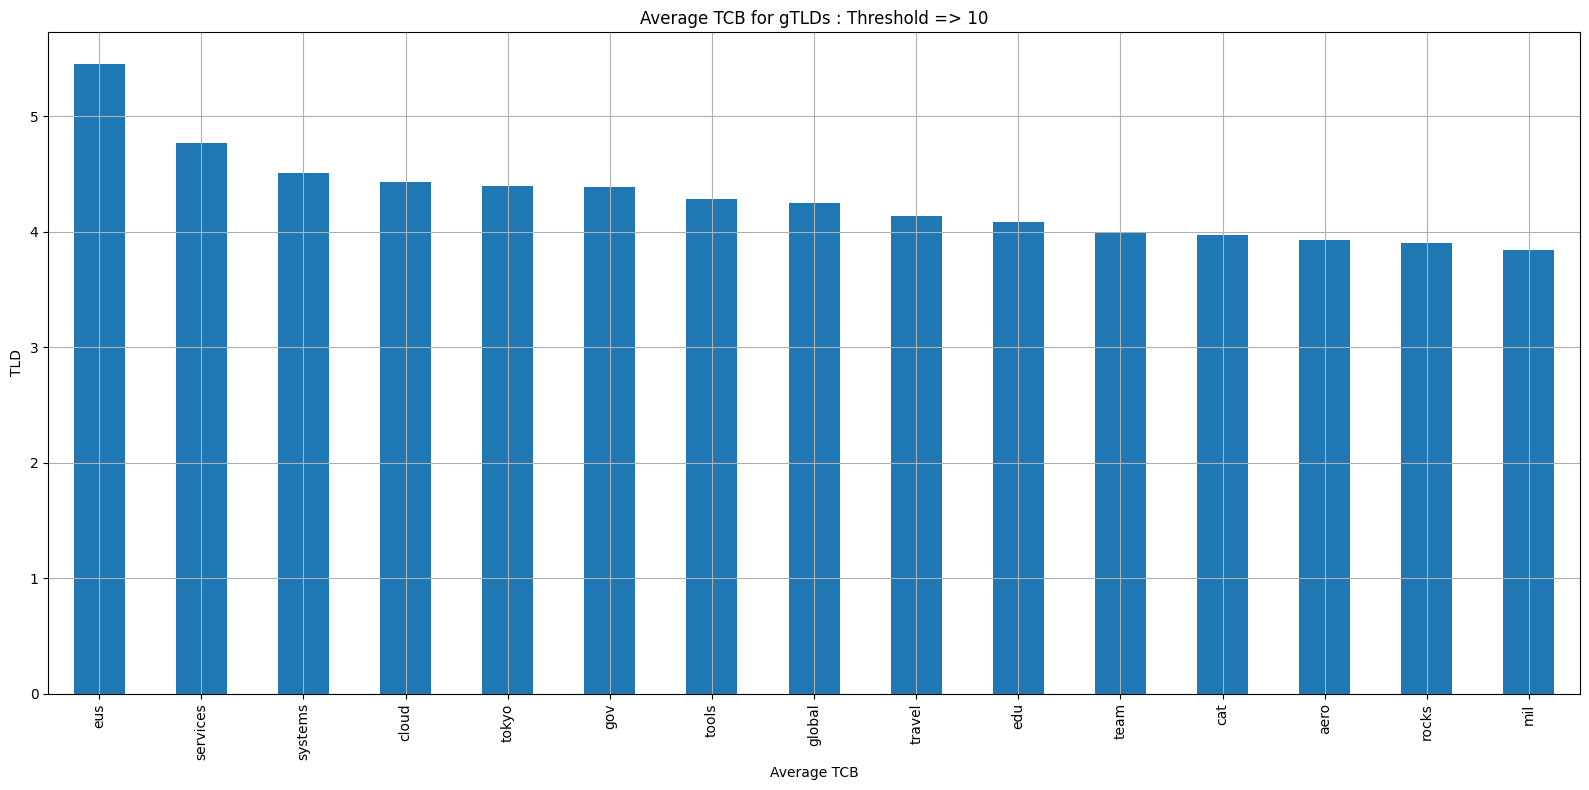

In [198]:
df = reslovde_with_TLD_threshold.copy()
general_df = df[df["group_code"] != "ccTLD"]
general_tld_avg = (
    general_df
    .groupby("tld")["TCB"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

ax = general_tld_avg.plot(kind="bar", figsize=(16, 8))

plt.xlabel("Average TCB")
plt.ylabel("TLD")
plt.grid(True)
plt.title("Average TCB for gTLDs : Threshold => 10")
plt.tight_layout()
plt.savefig(fig_dir / "Average TCB for gTLDs.png", dpi=300, bbox_inches="tight")
plt.show()

#### Shrinkage average: Bayes shrinkage

Shrinkage average means:

A corrected group average where small groups are pulled toward the overall average, because small-group averages are less reliable.

shrinkage_average =
w × group_average + (1 - w) × global_average

w = group_size / (group_size + k)


shrinkage_average =
(group_size / (group_size + k)) × group_average
+
(k / (group_size + k)) × global_average

Setting the shrinkage constant and calculating the global average TCB used as the prior mean.


In [214]:
k = 10

global_average_tcb = resolved_summary_df["TCB"].mean()

print("Global average TCB:", global_average_tcb)

Global average TCB: 3.4402027391351235


Building a per-TLD dataframe with group code, domain count, and raw average TCB.


In [215]:
tld_shrinkage_df = (
    resolved_summary_df
    .groupby("tld")
    .agg(
        group_code=("group_code", "first"),
        domain_count=("TCB", "size"),
        tcb_average=("TCB", "mean")
    )
    .reset_index()
)

Calculating shrinkage weights from each TLD group size and previewing the result.


In [216]:
k = 10

tld_shrinkage_df["weight"] = (
    tld_shrinkage_df["domain_count"]
    / (tld_shrinkage_df["domain_count"] + k)
)

tld_shrinkage_df.head()

,tld,group_code,domain_count,tcb_average,weight
0,abb,gTLD,5,6.400000,0.333333
1,abbott,gTLD,13,6.615385,0.565217
2,abudhabi,gTLD,2,3.500000,0.166667
3,ac,ccTLD,163,3.012270,0.942197
4,academy,gTLD,65,3.523077,0.866667


Inspecting the smallest TLD groups to see how their shrinkage weights behave.


In [217]:
tld_shrinkage_df[
    ["tld", "domain_count", "tcb_average", "weight"]
].sort_values("domain_count").head(5)

,tld,domain_count,tcb_average,weight
912,zappos,1,8.0,0.090909
18,aig,1,3.0,0.090909
893,xn--ngbc5azd,1,2.0,0.090909
894,xn--o3cw4h,1,2.0,0.090909
878,xn--6qq986b3xl,1,2.0,0.090909


Calculating shrinkage-adjusted TCB values by blending each TLD average with the global average.


In [218]:
tld_shrinkage_df["tcb_shrunk"] = (
    tld_shrinkage_df["weight"] * tld_shrinkage_df["tcb_average"]
    +
    (1 - tld_shrinkage_df["weight"]) * global_average_tcb
)

Previewing shrunk TCB values for the smallest TLD groups.


In [219]:
tld_shrinkage_df[
    ["tld", "domain_count", "tcb_average", "weight", "tcb_shrunk"]
].sort_values("domain_count").head(5)

,tld,domain_count,tcb_average,weight,tcb_shrunk
912,zappos,1,8.0,0.090909,3.854730
18,aig,1,3.0,0.090909,3.400184
893,xn--ngbc5azd,1,2.0,0.090909,3.309275
894,xn--o3cw4h,1,2.0,0.090909,3.309275
878,xn--6qq986b3xl,1,2.0,0.090909,3.309275


Measuring how much each raw TCB average changes after shrinkage adjustment.


In [220]:
tld_shrinkage_df["shrinkage_difference"] = (
    tld_shrinkage_df["tcb_average"] - tld_shrinkage_df["tcb_shrunk"]
)

tld_shrinkage_df[
    ["tld", "domain_count", "tcb_average", "tcb_shrunk", "shrinkage_difference"]
].sort_values("shrinkage_difference", ascending=False).head(5)

,tld,domain_count,tcb_average,tcb_shrunk,shrinkage_difference
389,ice,1,14.0,4.400184,9.599816
452,landrover,1,14.0,4.400184,9.599816
254,epson,1,14.0,4.400184,9.599816
739,sony,1,13.0,4.309275,8.690725
689,saxo,1,12.0,4.218366,7.781634


Inspecting shrinkage results for the largest TLD groups.


In [221]:
tld_shrinkage_df[
    ["tld", "domain_count", "tcb_average", "tcb_shrunk", "shrinkage_difference"]
].sort_values("domain_count", ascending=False).head(5)

,tld,domain_count,tcb_average,tcb_shrunk,shrinkage_difference
174,com,419203,3.404382,3.404383,-8.544843e-07
553,net,49694,3.365275,3.365291,-1.507469e-05
674,ru,40667,3.203113,3.203171,-5.828592e-05
587,org,37991,3.233819,3.233873,-5.431020e-05
212,de,22246,5.008541,5.007836,7.046810e-04


Plotting raw and shrinkage-adjusted TCB averages against TLD group size.


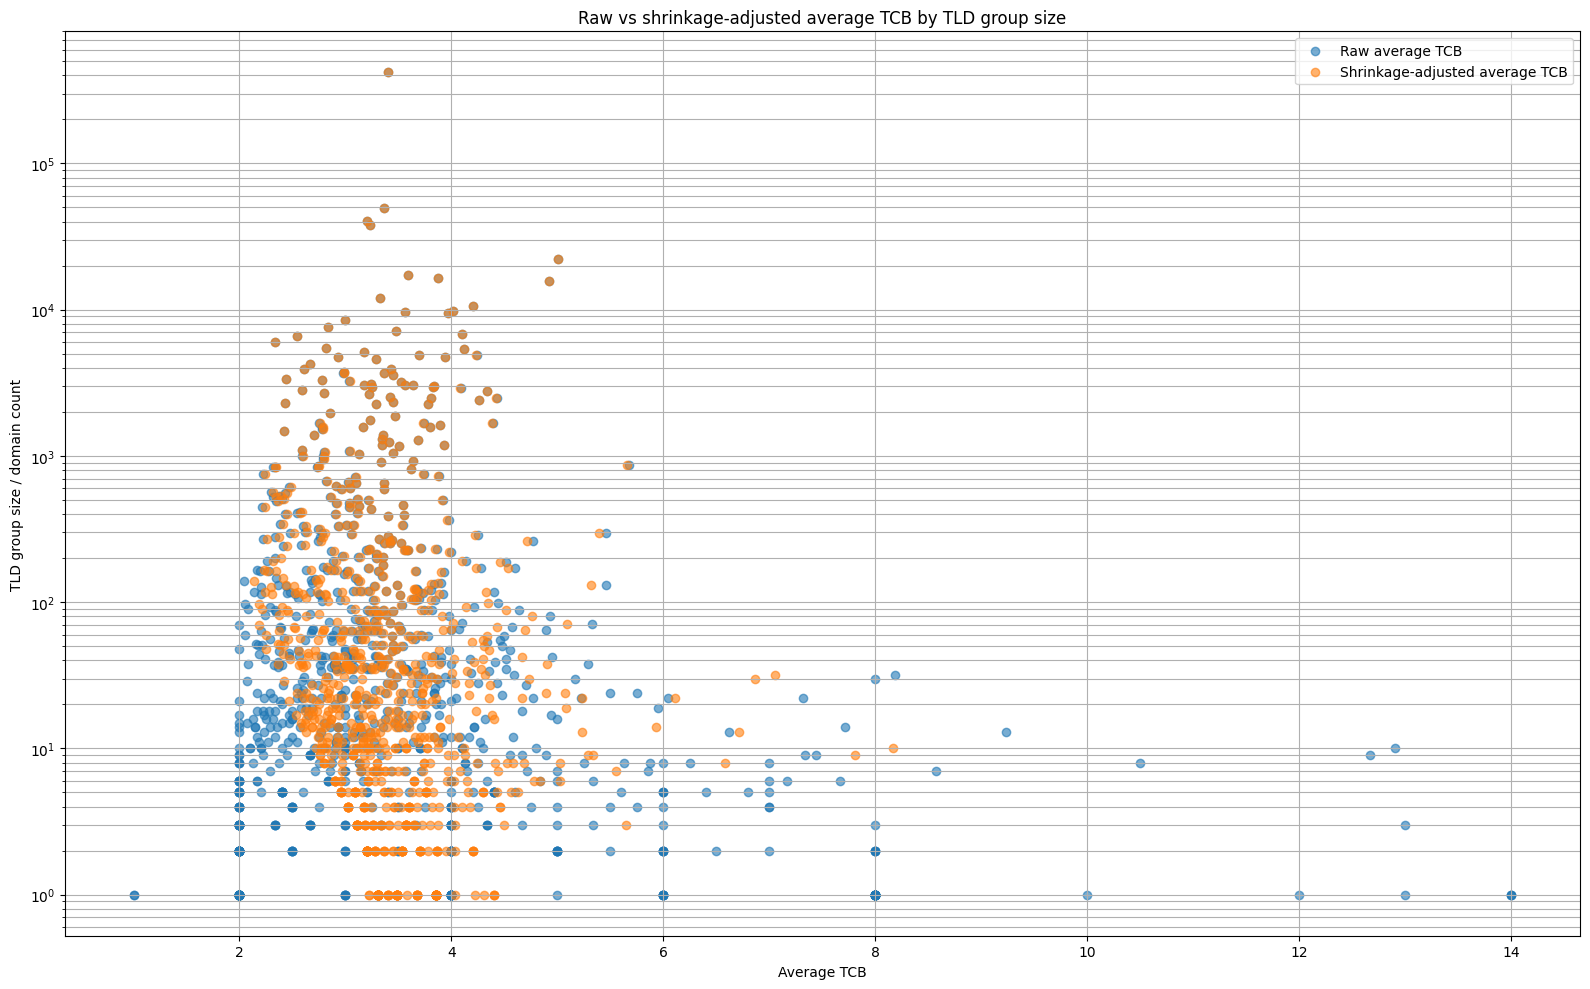

In [222]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

plt.scatter(
    tld_shrinkage_df["tcb_average"],
    tld_shrinkage_df["domain_count"],
    alpha=0.6,
    label="Raw average TCB"
)

plt.scatter(
    tld_shrinkage_df["tcb_shrunk"],
    tld_shrinkage_df["domain_count"],
    alpha=0.6,
    label="Shrinkage-adjusted average TCB"
)

plt.yscale("log")

plt.xlabel("Average TCB")
plt.ylabel("TLD group size / domain count")
plt.title("Raw vs shrinkage-adjusted average TCB by TLD group size")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

Plotting the top non-ccTLD groups by shrinkage-adjusted average TCB.


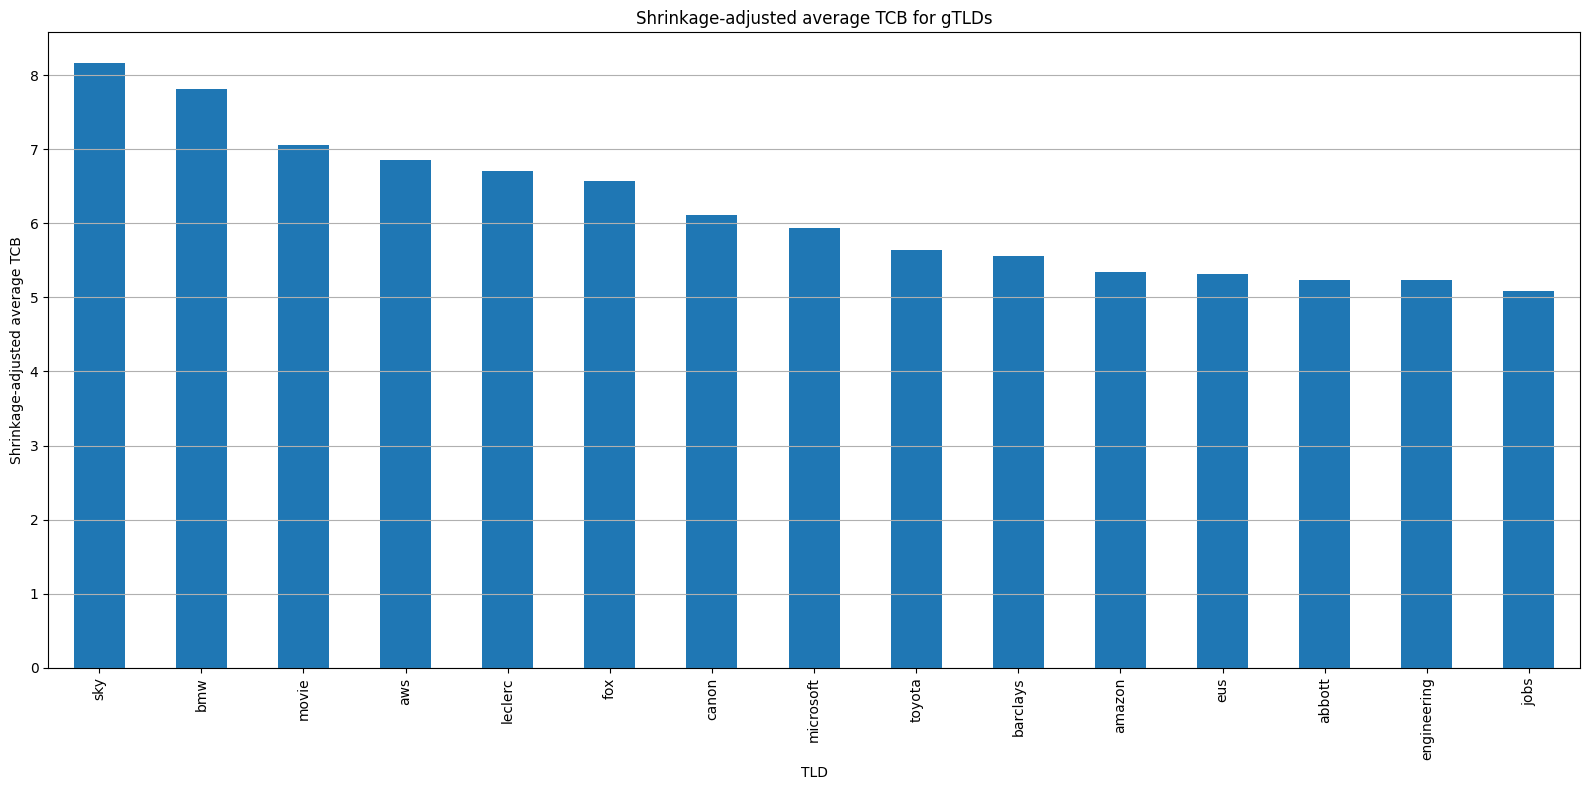

In [223]:
df = tld_shrinkage_df.copy()

general_df = df[df["group_code"] != "ccTLD"]

general_tld_avg_shrunk = (
    general_df
    .sort_values("tcb_shrunk", ascending=False)
    .head(15)
    .set_index("tld")
)

ax = general_tld_avg_shrunk["tcb_shrunk"].plot(
    kind="bar",
    figsize=(16, 8)
)

plt.xlabel("TLD")
plt.ylabel("Shrinkage-adjusted average TCB")
plt.grid(True, axis="y")
plt.title("Shrinkage-adjusted average TCB for gTLDs")
plt.tight_layout()
plt.savefig(fig_dir / "Shrinkage Adjusted Average TCB for gTLDs.png", dpi=300, bbox_inches="tight")
plt.show()

Plotting the top ccTLD groups by shrinkage-adjusted average TCB.


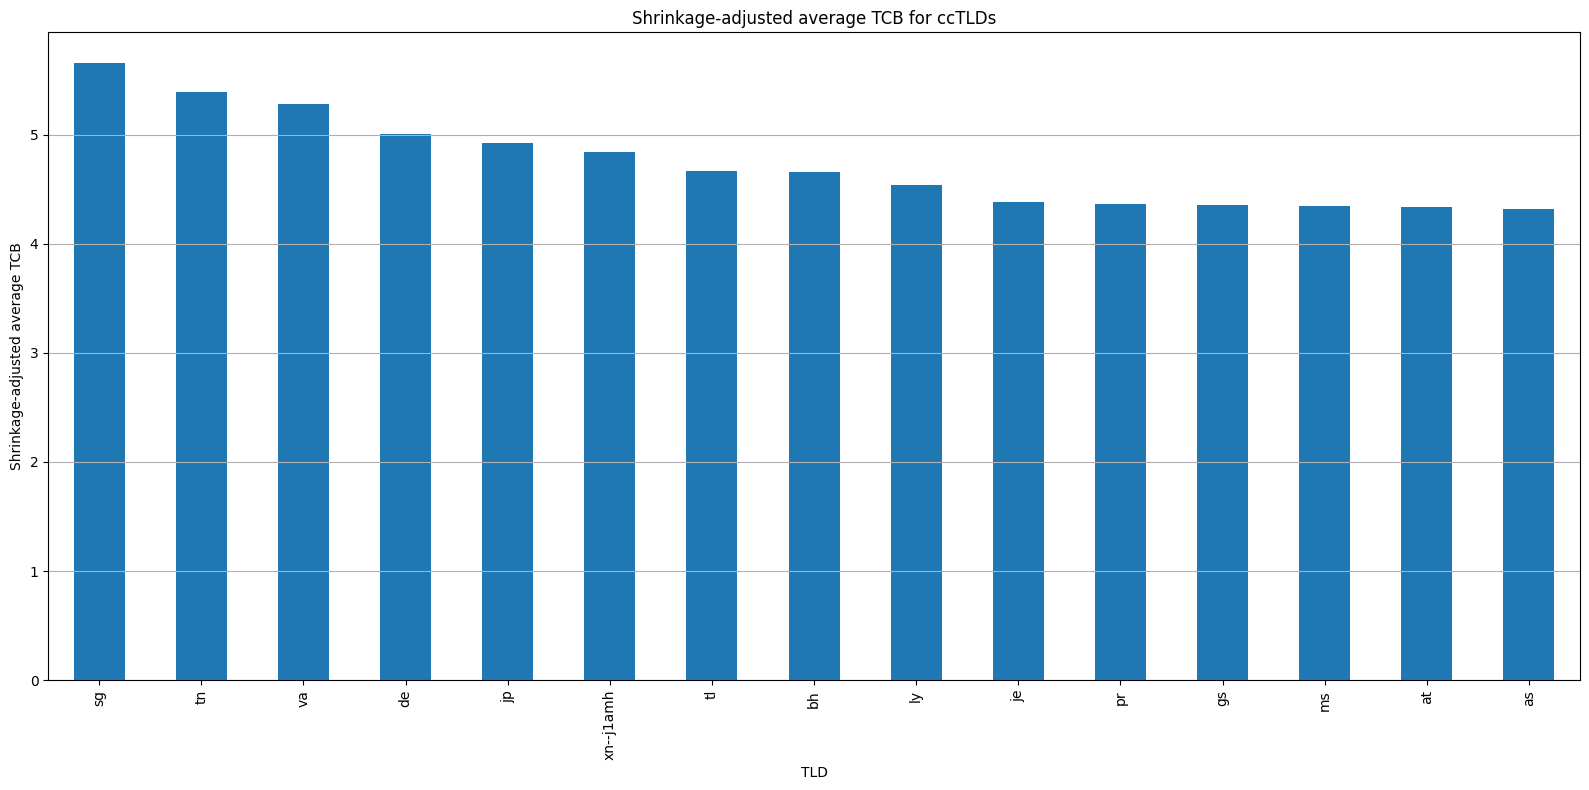

In [225]:
df = tld_shrinkage_df.copy()

general_df = df[df["group_code"] == "ccTLD"]

general_tld_avg_shrunk = (
    general_df
    .sort_values("tcb_shrunk", ascending=False)
    .head(15)
    .set_index("tld")
)

ax = general_tld_avg_shrunk["tcb_shrunk"].plot(
    kind="bar",
    figsize=(16, 8)
)

plt.xlabel("TLD")
plt.ylabel("Shrinkage-adjusted average TCB")
plt.grid(True, axis="y")
plt.title("Shrinkage-adjusted average TCB for ccTLDs")
plt.tight_layout()
plt.savefig(fig_dir / "Shrinkage Adjusted Average TCB for ccTLDs.png", dpi=300, bbox_inches="tight")
plt.show()

#### TCB vs ranking

##### general


Preparing rank and TCB values with a log-rank transform for rank-versus-TCB analysis.


In [243]:
plot_df = resolved_summary_df[["domain", "rank", "TCB"]].copy()

# clean
plot_df["rank"] = pd.to_numeric(plot_df["rank"], errors="coerce")
plot_df["TCB"] = pd.to_numeric(plot_df["TCB"], errors="coerce")
plot_df = plot_df.dropna(subset=["rank", "TCB"])


# log-transform rank
plot_df["log_rank"] = np.log10(plot_df["rank"])

Plotting TCB size against log-transformed Tranco rank.


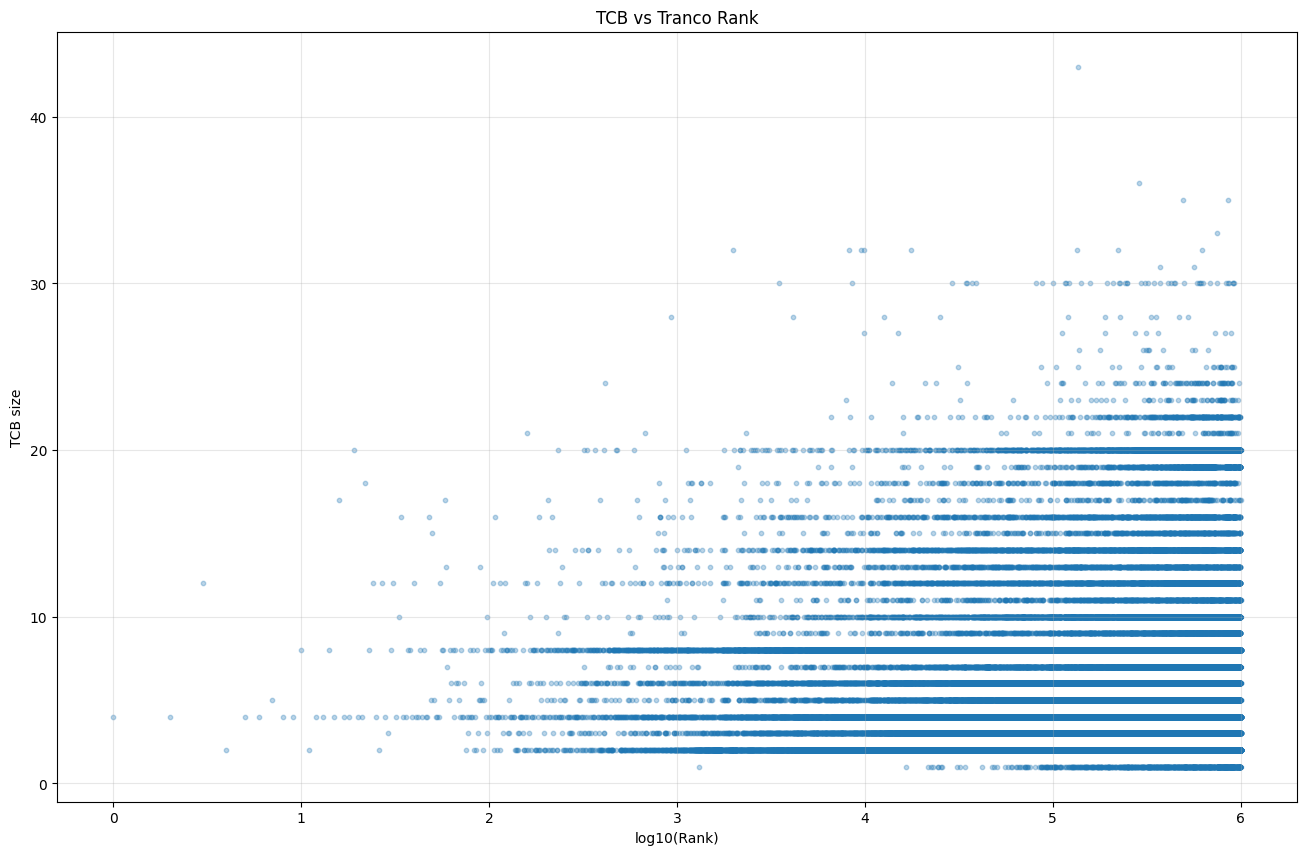

In [244]:
plt.figure(figsize=(16,10))

plt.scatter(
    plot_df["log_rank"],
    plot_df["TCB"],
    alpha=0.3,
    s=10
)

plt.xlabel("log10(Rank)")
plt.ylabel("TCB size")
plt.title("TCB vs Tranco Rank")
plt.grid(True, alpha=0.3)

plt.show()

##### top 1000 vs bottom 1000

Comparing TCB distributions between the top 1000 and bottom 1000 ranked domains.


topcount(1000, 3), bottomcount(1000, 3)


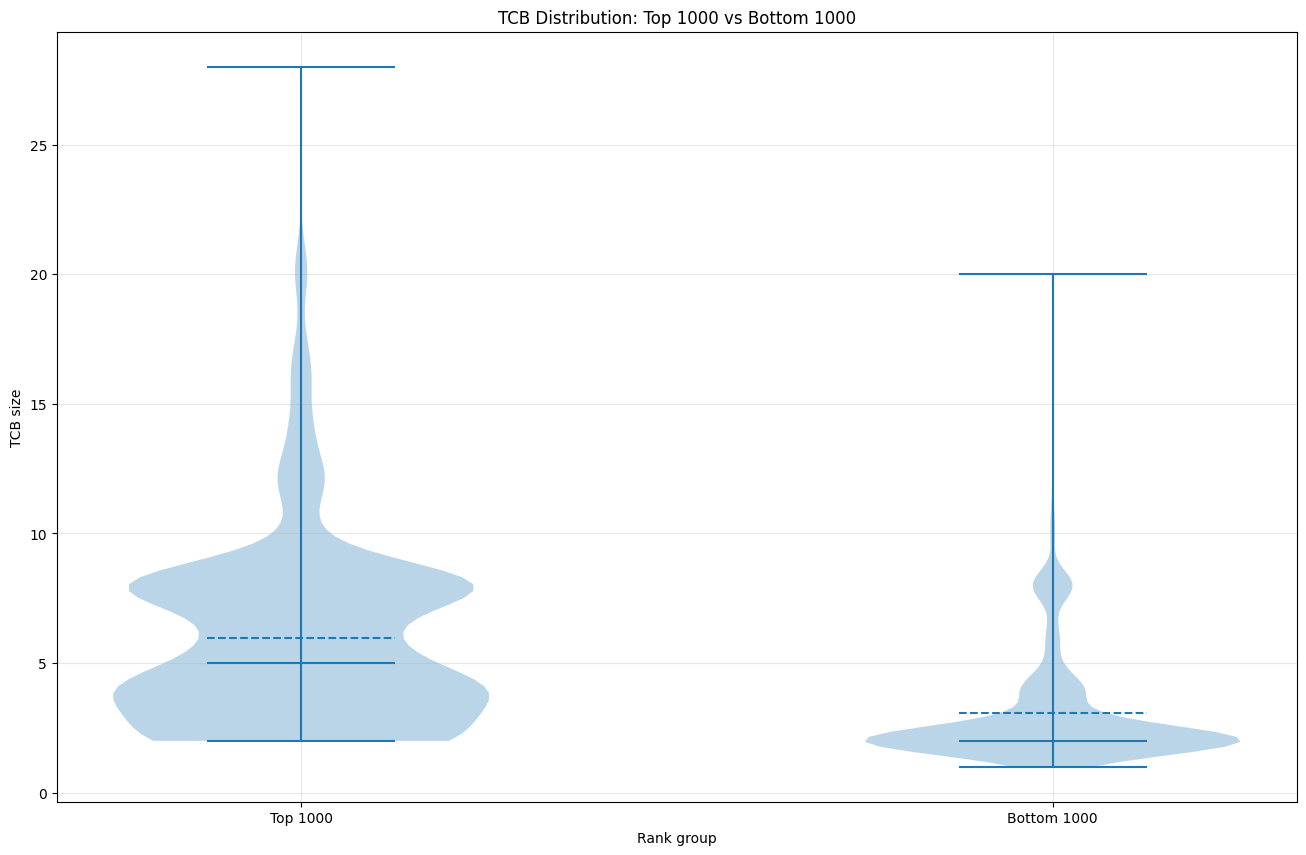

In [255]:
plot_df = resolved_summary_df[["domain", "rank", "TCB"]].copy()

top_1000 = plot_df.nsmallest(1000, "rank").copy()
bottom_1000 = plot_df.nlargest(1000, "rank").copy()
print(f'topcount{top_1000.shape}, bottomcount{bottom_1000.shape}')
groups = [
    top_1000["TCB"].dropna().to_numpy().ravel(),
    bottom_1000["TCB"].dropna().to_numpy().ravel()
]

labels = ["Top 1000", "Bottom 1000"]

plt.figure(figsize=(16, 10))

parts = plt.violinplot(
    dataset=groups,
    showmeans=True,
    showmedians=True,
  
)

parts["cmeans"].set_linestyle("--")

plt.xticks([1, 2], labels)
plt.xlabel("Rank group")
plt.ylabel("TCB size")
plt.title("TCB Distribution: Top 1000 vs Bottom 1000")
plt.grid(True, alpha=0.3)

plt.show()

##### (top 1000 cTLD vs gTLD) vs   (bottom 1000 cTLD vs gTLD)

Comparing top and bottom 1000 TCB distributions split by ccTLD versus gTLD status.


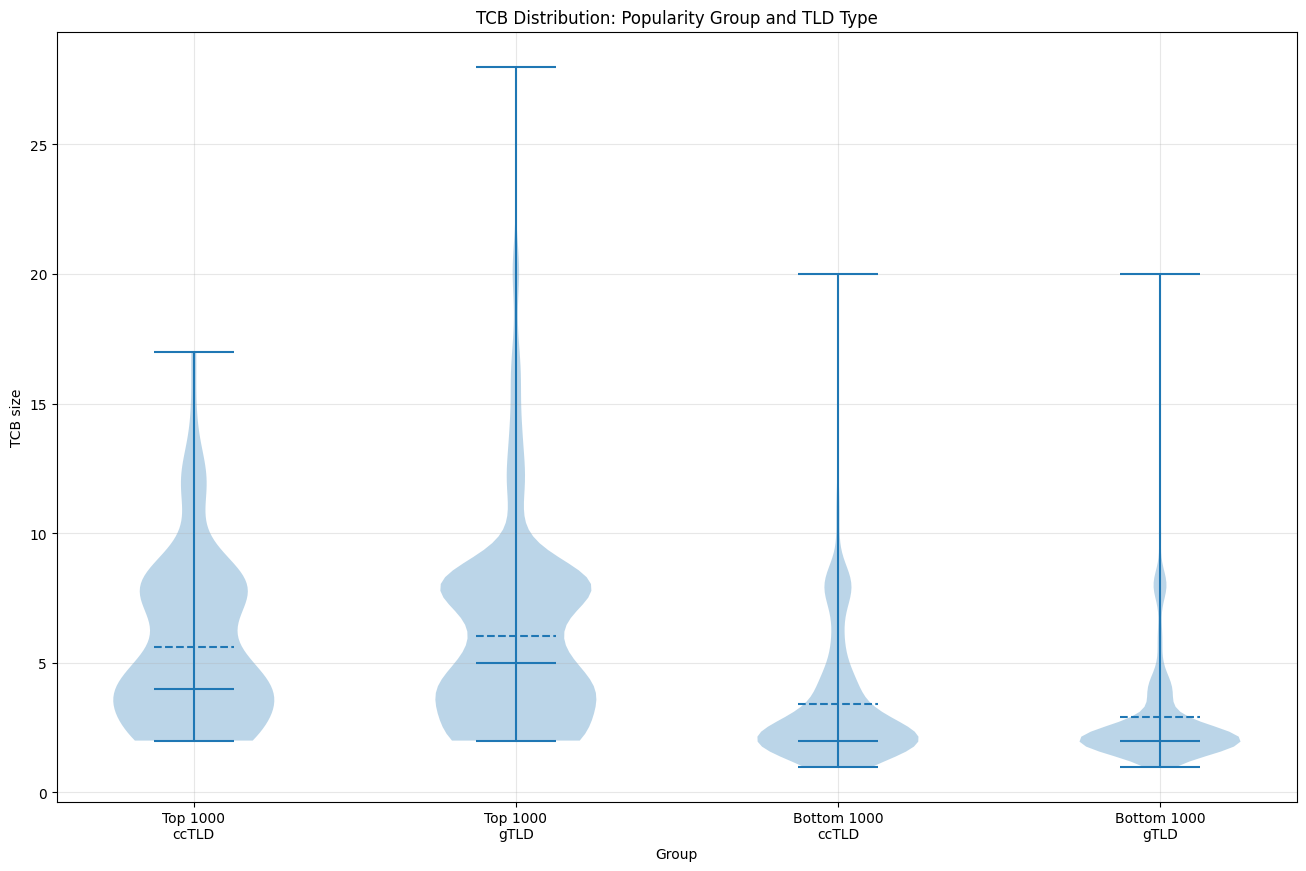

In [246]:
plot_df = resolved_summary_df[["domain", "rank", "TCB","group_code"]].copy()

plot_df["group_code"] = plot_df["group_code"].apply(
    lambda x: "ccTLD" if x == "ccTLD" else "gTLD"
)

top_1000 = plot_df.nsmallest(1000, "rank").copy()
bottom_1000 = plot_df.nlargest(1000, "rank").copy()

top_1000["popularity_group"] = "Top 1000"
bottom_1000["popularity_group"] = "Bottom 1000"

compare_df = pd.concat([top_1000, bottom_1000], ignore_index=True)

groups = []
labels = []

for pop_group in ["Top 1000", "Bottom 1000"]:
    for tld_group in ["ccTLD", "gTLD"]:
        values = compare_df[
            (compare_df["popularity_group"] == pop_group) &
            (compare_df["group_code"] == tld_group)
        ]["TCB"].dropna().to_numpy().ravel()

        groups.append(values)
        labels.append(f"{pop_group}\n{tld_group}")

plt.figure(figsize=(16, 10))

parts = plt.violinplot(
    dataset=groups,
    showmeans=True,
    showmedians=True
)

parts["cmeans"].set_linestyle("--")

plt.xticks(range(1, len(labels) + 1), labels)
plt.xlabel("Group")
plt.ylabel("TCB size")
plt.title("TCB Distribution: Popularity Group and TLD Type")
plt.grid(True, alpha=0.3)

plt.show()


##### (top 10000 cTLD vs gTLD) vs   (bottom 10000cTLD vs gTLD)

Comparing top and bottom 10000 TCB distributions split by ccTLD versus gTLD status.


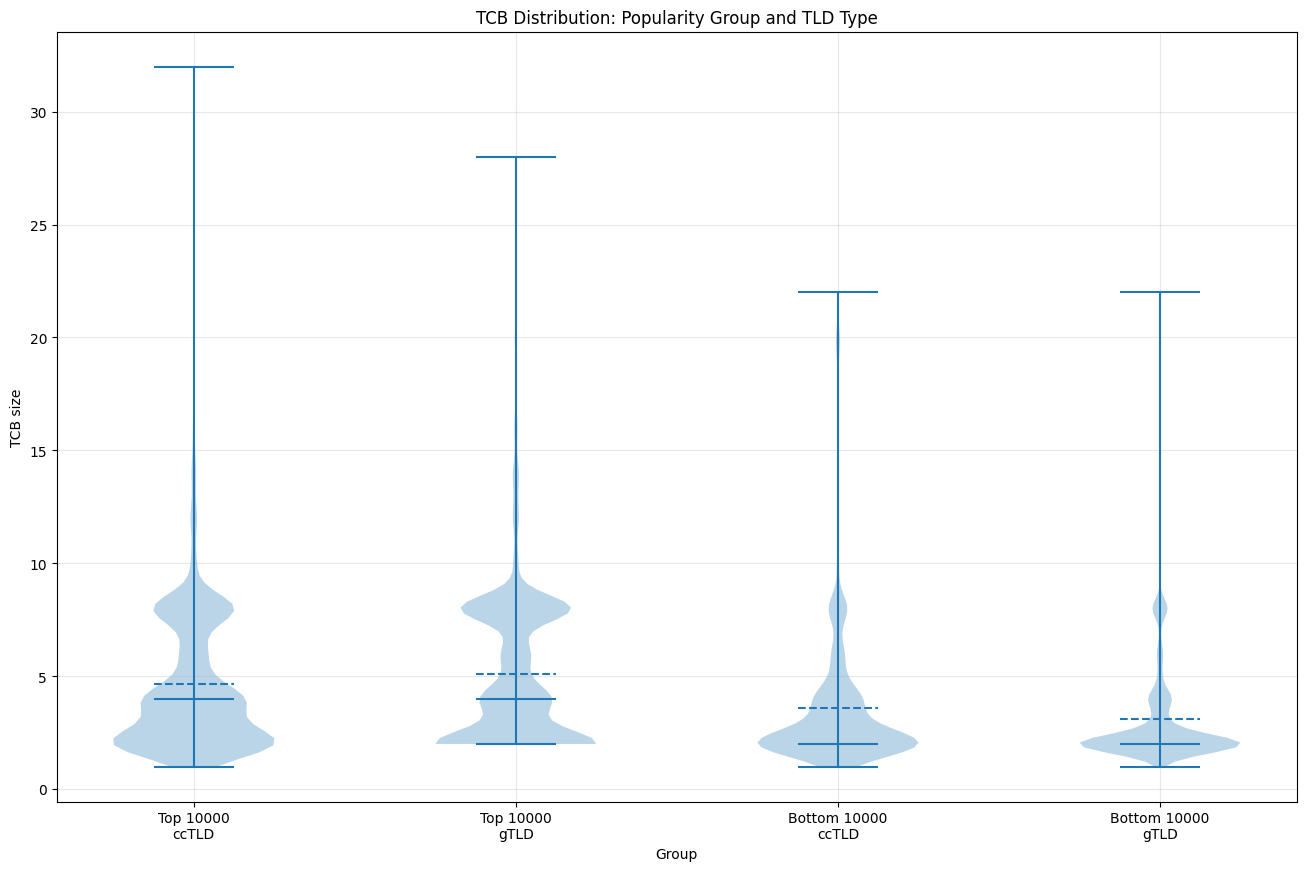

In [248]:
plot_df = resolved_summary_df[["domain", "rank", "TCB","group_code"]].copy()

plot_df["group_code"] = plot_df["group_code"].apply(
    lambda x: "ccTLD" if x == "ccTLD" else "gTLD"
)

top_10000 = plot_df.nsmallest(10000, "rank").copy()
bottom_10000 = plot_df.nlargest(10000, "rank").copy()

top_10000["popularity_group"] = "Top 10000"
bottom_10000["popularity_group"] = "Bottom 10000"

compare_df = pd.concat([top_10000, bottom_10000], ignore_index=True)

groups = []
labels = []

for pop_group in ["Top 10000", "Bottom 10000"]:
    for tld_group in ["ccTLD", "gTLD"]:
        values = compare_df[
            (compare_df["popularity_group"] == pop_group) &
            (compare_df["group_code"] == tld_group)
        ]["TCB"].dropna().to_numpy().ravel()

        groups.append(values)
        labels.append(f"{pop_group}\n{tld_group}")

plt.figure(figsize=(16, 10))

parts = plt.violinplot(
    dataset=groups,
    showmeans=True,
    showmedians=True
)

parts["cmeans"].set_linestyle("--")

plt.xticks(range(1, len(labels) + 1), labels)
plt.xlabel("Group")
plt.ylabel("TCB size")
plt.title("TCB Distribution: Popularity Group and TLD Type")
plt.grid(True, alpha=0.3)

plt.show()

Trends in the 100K

Preparing top-100K rank bins and TLD groups for trend analysis.


In [249]:
plot_df = resolved_summary_df[["domain", "rank", "TCB","group_code"]].copy()

plot_df["group_code"] = plot_df["group_code"].apply(
    lambda x: "ccTLD" if x == "ccTLD" else "gTLD"
)


plot_df["rank"] = pd.to_numeric(plot_df["rank"], errors="coerce")
plot_df["TCB"] = pd.to_numeric(plot_df["TCB"], errors="coerce")
plot_df = plot_df.dropna(subset=["rank", "TCB", "group_code"])


# keep top 100k only
plot_df = plot_df[(plot_df["rank"] >= 1) & (plot_df["rank"] <= 100000)]

# create 10 rank groups of 10k
plot_df["rank_bin"] = ((plot_df["rank"] - 1) // 10000) + 1

plot_df["rank_bin_label"] = plot_df["rank_bin"].apply(
    lambda x: f"{(x-1)*10000 + 1}-{x*10000}"
)

Plotting TCB distributions across top-100K rank bins for ccTLD and gTLD domains.


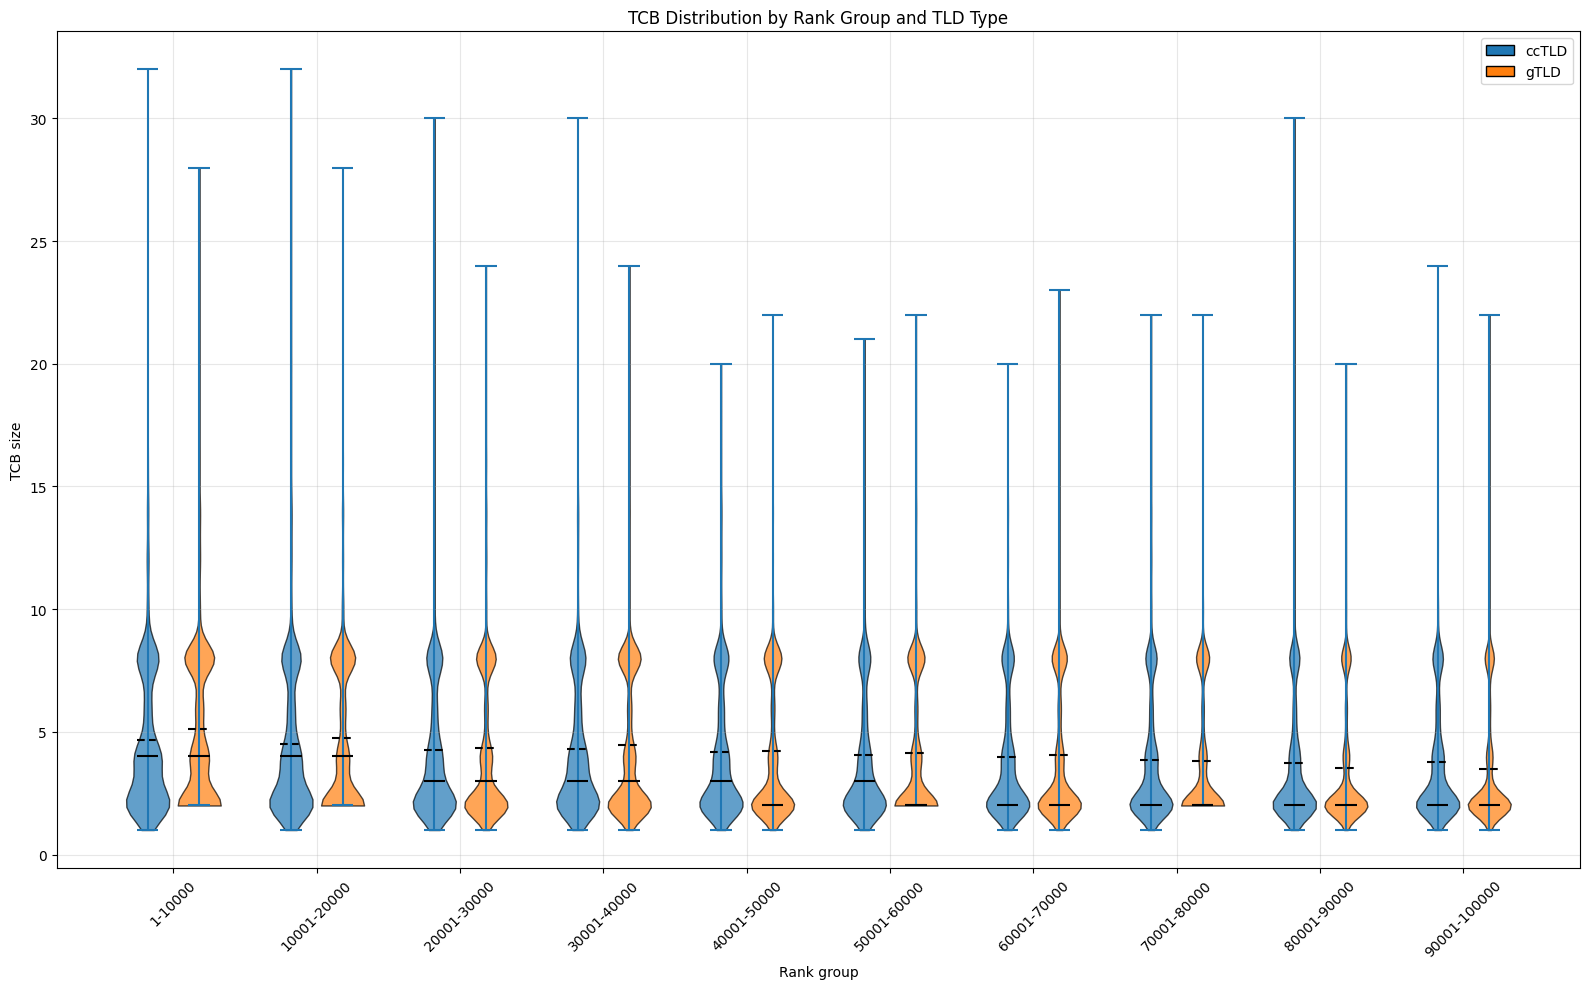

In [250]:
fig, ax = plt.subplots(figsize=(16, 10))

positions = []
groups = []
colors = []

for i in range(1, 11):
    for tld_group, offset, color in [
        ("ccTLD", -0.18, "tab:blue"),
        ("gTLD",  0.18, "tab:orange")
    ]:
        values = plot_df[
            (plot_df["rank_bin"] == i) &
            (plot_df["group_code"] == tld_group)
        ]["TCB"].dropna().to_numpy().ravel()

        groups.append(values)
        positions.append(i + offset)
        colors.append(color)

parts = ax.violinplot(
    dataset=groups,
    positions=positions,
    widths=0.30,
    showmeans=True,
    showmedians=True
)

parts["cmeans"].set_color("black")
parts["cmeans"].set_linestyle("--")

parts["cmedians"].set_color("black")
parts["cmedians"].set_linestyle("-")

for body, color in zip(parts["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.7)

ax.set_xticks(range(1, 11))
ax.set_xticklabels(
    [f"{(i-1)*10000 + 1}-{i*10000}" for i in range(1, 11)],
    rotation=45
)

ax.set_xlabel("Rank group")
ax.set_ylabel("TCB size")
ax.set_title("TCB Distribution by Rank Group and TLD Type")
ax.grid(True, alpha=0.3)

# manual legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor="tab:blue", edgecolor="black", label="ccTLD"),
    Patch(facecolor="tab:orange", edgecolor="black", label="gTLD")
]
ax.legend(handles=legend_items)

plt.tight_layout()
plt.show()

##### Trends in the least  100K

Preparing least-100K rank bins and TLD groups for trend analysis.


In [251]:
plot_df = resolved_summary_df[["domain", "rank", "TCB","group_code"]].copy()

plot_df["group_code"] = plot_df["group_code"].apply(
    lambda x: "ccTLD" if x == "ccTLD" else "gTLD"
)

plot_df["rank"] = pd.to_numeric(plot_df["rank"], errors="coerce")
plot_df["TCB"] = pd.to_numeric(plot_df["TCB"], errors="coerce")
plot_df = plot_df.dropna(subset=["rank", "TCB", "group_code"])



# last 100k ranks
plot_df = plot_df[(plot_df["rank"] >= 900000) & (plot_df["rank"] <= 1000000)]

# create 10 groups of 10k
plot_df["rank_bin"] = ((plot_df["rank"] - 900000) // 10000) + 1

plot_df["rank_bin_label"] = plot_df["rank_bin"].apply(
    lambda x: f"{900000 + (x-1)*10000}-{900000 + x*10000 - 1}"
)

Plotting TCB distributions across least-100K rank bins for ccTLD and gTLD domains.


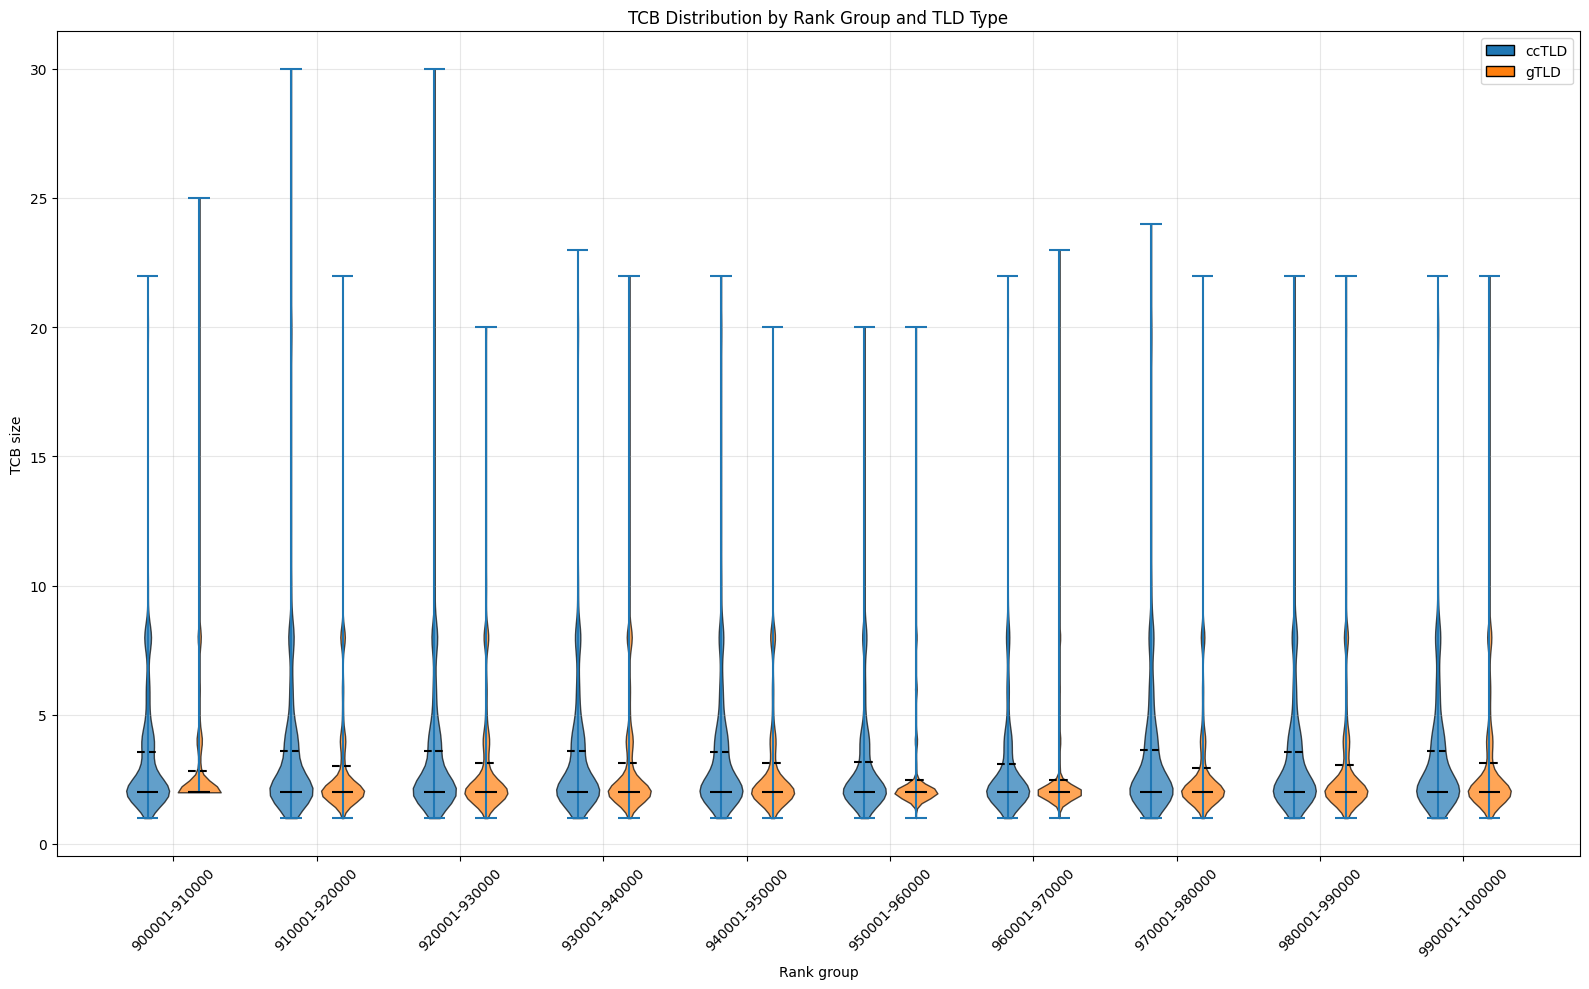

In [252]:
fig, ax = plt.subplots(figsize=(16, 10))

positions = []
groups = []
colors = []

for i in range(1, 11):
    for tld_group, offset, color in [
        ("ccTLD", -0.18, "tab:blue"),
        ("gTLD",  0.18, "tab:orange")
    ]:
        values = plot_df[
            (plot_df["rank_bin"] == i) &
            (plot_df["group_code"] == tld_group)
        ]["TCB"].dropna().to_numpy().ravel()

        groups.append(values)
        positions.append(i + offset)
        colors.append(color)

parts = ax.violinplot(
    dataset=groups,
    positions=positions,
    widths=0.30,
    showmeans=True,
    showmedians=True
)

parts["cmeans"].set_color("black")
parts["cmeans"].set_linestyle("--")

parts["cmedians"].set_color("black")
parts["cmedians"].set_linestyle("-")

for body, color in zip(parts["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.7)

ax.set_xticks(range(1, 11))
ax.set_xticklabels(
    [f"{900001 + (i-1)*10000}-{900000 + i*10000}" for i in range(1, 11)],
    rotation=45
)
ax.set_xlabel("Rank group")
ax.set_ylabel("TCB size")
ax.set_title("TCB Distribution by Rank Group and TLD Type")
ax.grid(True, alpha=0.3)

# manual legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor="tab:blue", edgecolor="black", label="ccTLD"),
    Patch(facecolor="tab:orange", edgecolor="black", label="gTLD")
]
ax.legend(handles=legend_items)

plt.tight_layout()
plt.show()

#### Weighted Parcentage Average 

Finding parcentage of dependency on dominating(top 5) Infrastructure.

###### Loading Tranco infrastructure parquet

Loading nameserver infrastructure frequencies and selecting the top 5 providers.


In [ ]:
file_path = Path.cwd().parent / 'data' / 'result' /  'NS_infrastructure' /'tranco_NS_infrastructure.parquet'
tranco_namesaver_infrastructure = pd.read_parquet(file_path)
display(tranco_namesaver_infrastructure.head(2))
tranco_namesaver_infrastructure.sort_values("Frequency",ascending=False)
tranco_namesaver_infrastructure_top5 = tranco_namesaver_infrastructure.iloc[:5, tranco_namesaver_infrastructure.columns.get_loc("NameServer")]
display(tranco_namesaver_infrastructure_top5)

,NameServer,Frequency
0,awsdns-infrastructure,721955
1,ns.cloudflare,676518


0    awsdns-infrastructure
1            ns.cloudflare
2                   ui-dns
3            domaincontrol
4                     akam
Name: NameServer, dtype: str

##### Top Ranked 100K

Preparing the top 100K domains with rank, TCB, TLD group, and unique nameserver data.


In [278]:
tranco_df = resolved_summary_df[["domain", "rank", "TCB","group_code","domain_unique_ns"]].copy()

tranco_df["group_code"] = tranco_df["group_code"].apply(
    lambda x: "ccTLD" if x == "ccTLD" else "gTLD"
)

tranco_df["rank"] = pd.to_numeric(tranco_df["rank"], errors="coerce")
tranco_df["TCB"] = pd.to_numeric(tranco_df["TCB"], errors="coerce")
tranco_df = tranco_df.dropna(subset=["rank", "TCB", "group_code"])



# last 100k ranks
tranco_top_100k = tranco_df[(tranco_df["rank"] >= 1) & (tranco_df["rank"] <= 100000)]

tranco_top_100k.head(2)

,domain,rank,TCB,group_code,domain_unique_ns
0,kunlunea.com,14896,3,gTLD,"[ns5.aliyun.com, ns4.aliyun.com, ns3.aliyun.com]"
523530,nomadlist.com,88120,2,gTLD,"[jobs.ns.cloudflare.com, janet.ns.cloudflare.com]"


Total( in TOP 5)/ Total(TCB) * 100

Counting how many nameservers for each top-100K domain belong to the top 5 infrastructure providers.


In [279]:
counts = []

top5Infra_set = set(tranco_namesaver_infrastructure_top5)

for row in tranco_top_100k.itertuples():
    count_inTop5 = 0
    for ns in row.domain_unique_ns:
        name = ns.split(".", 1)[1] # removing the most left right label.
        if name.startswith("awsdns"):
            name = "awsdns-infrastructure"
        else:
            name = name.rsplit(".",1)[0] # I am omming TLD here 
        
        if name in top5Infra_set:
            count_inTop5+=1

    counts.append(count_inTop5)


tranco_top_100k["ns_inTop5"] = counts

display(tranco_top_100k.head(5))

,domain,rank,TCB,group_code,domain_unique_ns,ns_inTop5
0,kunlunea.com,14896,3,gTLD,"[ns5.aliyun.com, ns4.aliyun.com, ns3.aliyun.com]",0
523530,nomadlist.com,88120,2,gTLD,"[jobs.ns.cloudflare.com, janet.ns.cloudflare.com]",2
523531,hotelcavallinotreporti.com,71622,6,gTLD,"[ns1.eaglenet.org, vps06.ced.eu, ns2.stefano-brandimarte.net, dns.ced.it, dns.eaglenet.org, ns1.stefano-brandimarte.net]",0
523532,eftarkov.com,92878,4,gTLD,"[ingram.dnspod.net, kevin.dnspod.net, ns4.dnsv2.com, ns3.dnsv2.net]",0
523533,hindibookmark.com,68416,2,gTLD,"[rodney.ns.cloudflare.com, cecelia.ns.cloudflare.com]",2


Bins and Graph preparations

Assigning top-100K domains to 10K rank bins for grouped plotting.


In [280]:
# create 10 groups of 10k
tranco_top_100k["rank_bin"] = ((tranco_top_100k["rank"] - 1) // 10000) + 1

tranco_top_100k["rank_bin_label"] = tranco_top_100k["rank_bin"].apply(
    lambda x: f"{(x-1)*10000 + 1}-{x*10000}"
)

display(tranco_top_100k.head(2))

,domain,rank,TCB,group_code,domain_unique_ns,ns_inTop5,rank_bin,rank_bin_label
0,kunlunea.com,14896,3,gTLD,"[ns5.aliyun.com, ns4.aliyun.com, ns3.aliyun.com]",0,2,10001-20000
523530,nomadlist.com,88120,2,gTLD,"[jobs.ns.cloudflare.com, janet.ns.cloudflare.com]",2,9,80001-90000


Plotting top-5 infrastructure dependency percentages across top-100K rank bins.


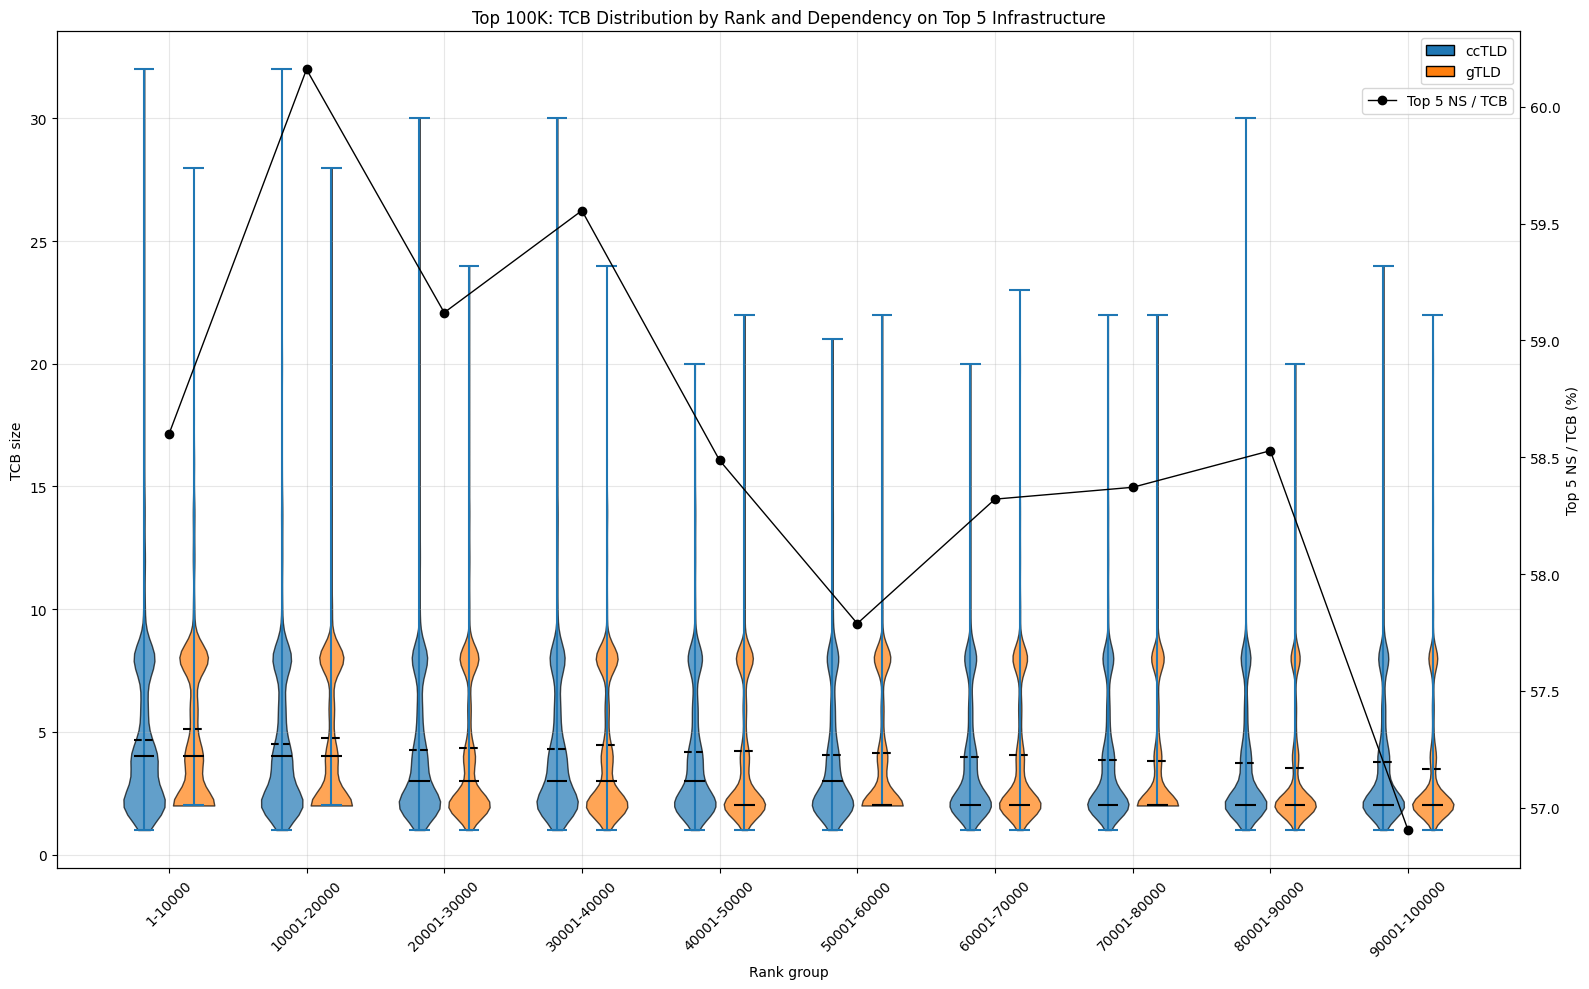

In [285]:
fig, ax = plt.subplots(figsize=(16, 10))

positions = []
groups = []
colors = []

for i in range(1, 11):
    for tld_group, offset, color in [
        ("ccTLD", -0.18, "tab:blue"),
        ("gTLD",  0.18, "tab:orange")
    ]:
        values = tranco_top_100k[
            (tranco_top_100k["rank_bin"] == i) &
            (tranco_top_100k["group_code"] == tld_group)
        ]["TCB"].dropna().to_numpy().ravel()

        groups.append(values)
        positions.append(i + offset)
        colors.append(color)

parts = ax.violinplot(
    dataset=groups,
    positions=positions,
    widths=0.30,
    showmeans=True,
    showmedians=True
)

parts["cmeans"].set_color("black")
parts["cmeans"].set_linestyle("--")

parts["cmedians"].set_color("black")
parts["cmedians"].set_linestyle("-")

for body, color in zip(parts["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.7)

ax.set_xticks(range(1, 11))
ax.set_xticklabels(
    [f"{(i-1)*10000 + 1}-{i*10000}" for i in range(1, 11)],
    rotation=45
)
ax.set_xlabel("Rank group")
ax.set_ylabel("TCB size")
ax.set_title("Top 100K: TCB Distribution by Rank and Dependency on Top 5 Infrastructure")
ax.grid(True, alpha=0.3)

# manual legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor="tab:blue", edgecolor="black", label="ccTLD"),
    Patch(facecolor="tab:orange", edgecolor="black", label="gTLD")
]
ax.legend(handles=legend_items)


# Drawing parcentage line  

ax2 = ax.twinx()

line_x = []
line_y = []

for i in range(1, 11):
    group_df = tranco_top_100k[tranco_top_100k["rank_bin"] == i]

    total_ns_inTop5 = group_df["ns_inTop5"].sum()
    total_TCB = group_df["TCB"].sum()

    pct = (total_ns_inTop5 / total_TCB) * 100

    line_x.append(i)
    line_y.append(pct)

ax2.plot(line_x, line_y, color="black", marker="o", linewidth=1, label="Top 5 NS / TCB")
ax2.set_ylabel("Top 5 NS / TCB (%)")
ax2.legend(loc="upper right", bbox_to_anchor=(1, 0.94))

plt.tight_layout()
plt.show()

##### Least Ranked 100K

###### getting the names.

Preparing the least-ranked 100K domains with rank, TCB, TLD group, and unique nameserver data.


In [282]:
tranco_df = resolved_summary_df[["domain", "rank", "TCB","group_code","domain_unique_ns"]].copy()

tranco_df["group_code"] = tranco_df["group_code"].apply(
    lambda x: "ccTLD" if x == "ccTLD" else "gTLD"
)

tranco_df["rank"] = pd.to_numeric(tranco_df["rank"], errors="coerce")
tranco_df["TCB"] = pd.to_numeric(tranco_df["TCB"], errors="coerce")
tranco_df = tranco_df.dropna(subset=["rank", "TCB", "group_code"])



# last 100k ranks
tranco_least_100k = tranco_df[(tranco_df["rank"] >= 900000) & (tranco_df["rank"] <= 1000000)]

tranco_least_100k.head(2)

,domain,rank,TCB,group_code,domain_unique_ns
1,kiaspecialtools.com,985556,3,gTLD,"[ns1.a2.impervasecuredns.net, ns1.a1.impervasecuredns.net, ns1.a0.impervasecuredns.net]"
2,quiz4dgg.space,965100,2,gTLD,"[rosa.ns.cloudflare.com, darl.ns.cloudflare.com]"


Total( in TOP 5)/ Total(TCB) * 100

Counting how many nameservers for each least-100K domain belong to the top 5 infrastructure providers.


In [283]:
counts = []

top5Infra_set = set(tranco_namesaver_infrastructure_top5)

for row in tranco_least_100k.itertuples():
    count_inTop5 = 0
    for ns in row.domain_unique_ns:
        name = ns.split(".", 1)[1] # removing the most left right label.
        if name.startswith("awsdns"):
            name = "awsdns-infrastructure"
        else:
            name = name.rsplit(".",1)[0] # I am omming TLD here 
        
        if name in top5Infra_set:
            count_inTop5+=1

    counts.append(count_inTop5)


tranco_least_100k["ns_inTop5"] = counts

display(tranco_least_100k.head(5))

,domain,rank,TCB,group_code,domain_unique_ns,ns_inTop5
1,kiaspecialtools.com,985556,3,gTLD,"[ns1.a2.impervasecuredns.net, ns1.a1.impervasecuredns.net, ns1.a0.impervasecuredns.net]",0
2,quiz4dgg.space,965100,2,gTLD,"[rosa.ns.cloudflare.com, darl.ns.cloudflare.com]",2
3,edcsr.com,955280,3,gTLD,"[ns2.contabo.net, ns3.contabo.net, ns1.contabo.net]",0
4,agenbpjs777.info,950520,2,gTLD,"[ns10.hawkhost.com, ns9.hawkhost.com]",0
5,j399j39y6.com,958574,4,gTLD,"[ns1gjz.name.com, ns2hkt.name.com, ns3qty.name.com, ns4clq.name.com]",0


Bins and Graph preparations

Assigning least-100K domains to 10K rank bins for grouped plotting.


In [284]:
# create 10 groups of 10k
tranco_least_100k["rank_bin"] = ((tranco_least_100k["rank"] - 900000) // 10000) + 1

tranco_least_100k["rank_bin_label"] = tranco_least_100k["rank_bin"].apply(
    lambda x: f"{900000 + (x-1)*10000}-{900000 + x*10000 - 1}"
)

display(tranco_least_100k.head(2))

,domain,rank,TCB,group_code,domain_unique_ns,ns_inTop5,rank_bin,rank_bin_label
1,kiaspecialtools.com,985556,3,gTLD,"[ns1.a2.impervasecuredns.net, ns1.a1.impervasecuredns.net, ns1.a0.impervasecuredns.net]",0,9,980000-989999
2,quiz4dgg.space,965100,2,gTLD,"[rosa.ns.cloudflare.com, darl.ns.cloudflare.com]",2,7,960000-969999


Plotting top-5 infrastructure dependency percentages across least-100K rank bins.


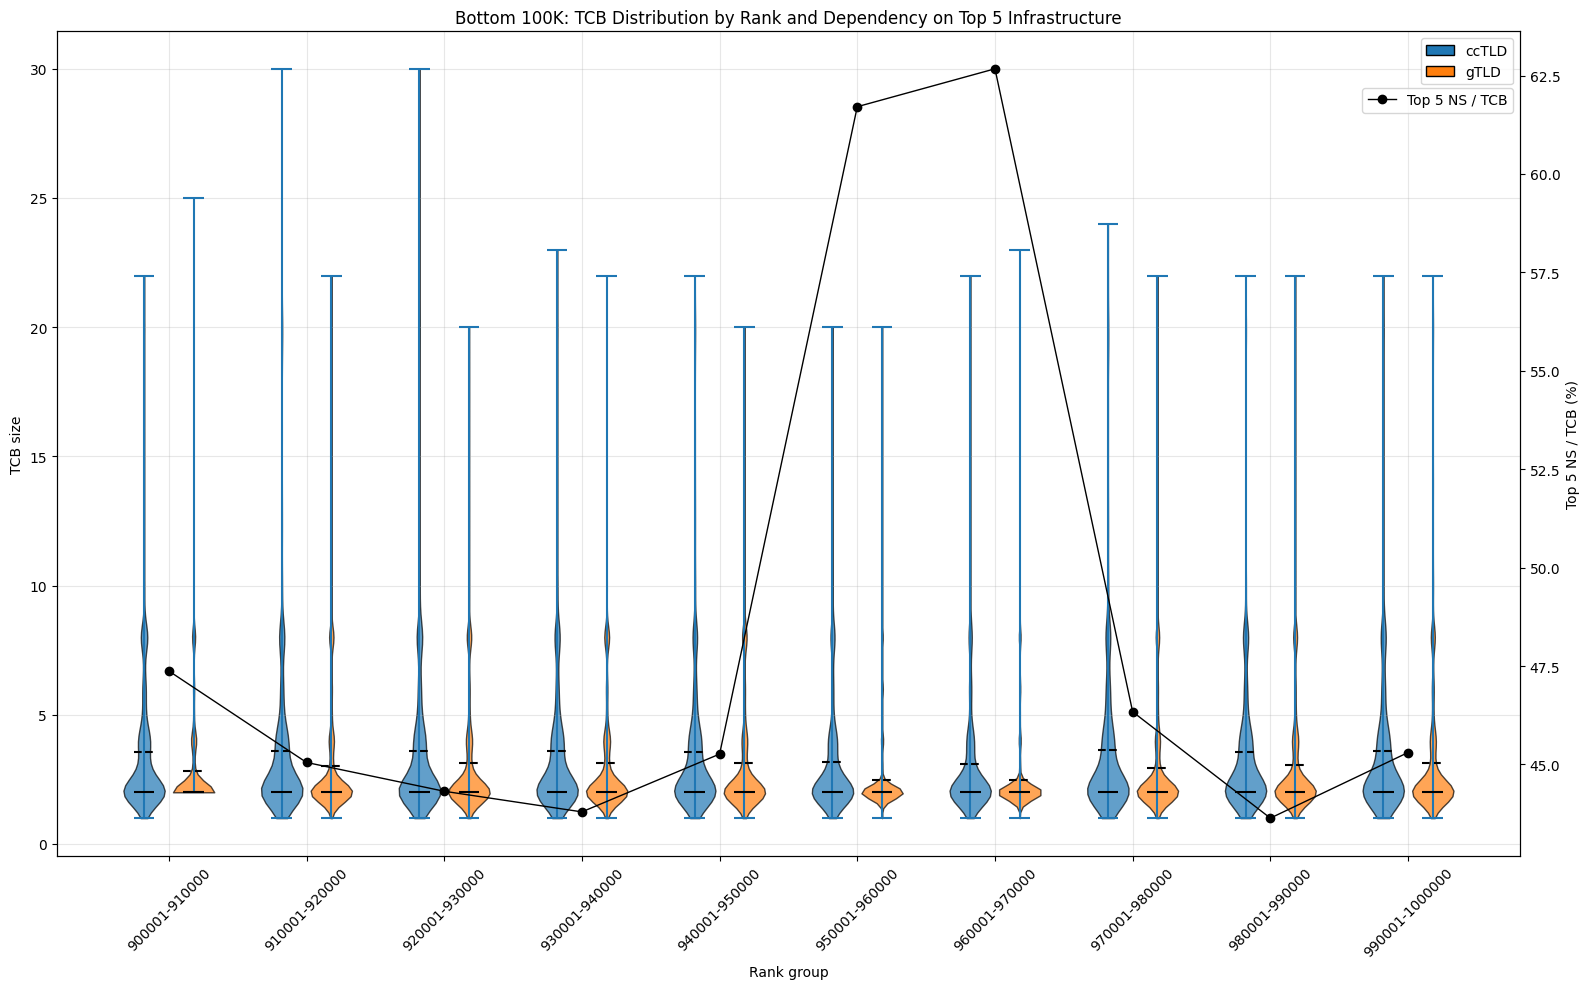

In [286]:
fig, ax = plt.subplots(figsize=(16, 10))

positions = []
groups = []
colors = []

for i in range(1, 11):
    for tld_group, offset, color in [
        ("ccTLD", -0.18, "tab:blue"),
        ("gTLD",  0.18, "tab:orange")
    ]:
        values = tranco_least_100k[
            (tranco_least_100k["rank_bin"] == i) &
            (tranco_least_100k["group_code"] == tld_group)
        ]["TCB"].dropna().to_numpy().ravel()

        groups.append(values)
        positions.append(i + offset)
        colors.append(color)

parts = ax.violinplot(
    dataset=groups,
    positions=positions,
    widths=0.30,
    showmeans=True,
    showmedians=True
)

parts["cmeans"].set_color("black")
parts["cmeans"].set_linestyle("--")

parts["cmedians"].set_color("black")
parts["cmedians"].set_linestyle("-")

for body, color in zip(parts["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.7)

ax.set_xticks(range(1, 11))
ax.set_xticklabels(
    [f"{900001 + (i-1)*10000}-{900000 + i*10000}" for i in range(1, 11)],
    rotation=45
)
ax.set_xlabel("Rank group")
ax.set_ylabel("TCB size")
ax.set_title("Bottom 100K: TCB Distribution by Rank and Dependency on Top 5 Infrastructure")
ax.grid(True, alpha=0.3)

# manual legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor="tab:blue", edgecolor="black", label="ccTLD"),
    Patch(facecolor="tab:orange", edgecolor="black", label="gTLD")
]
ax.legend(handles=legend_items)


# Drawing parcentage line  

ax2 = ax.twinx()

line_x = []
line_y = []

for i in range(1, 11):
    group_df = tranco_least_100k[tranco_least_100k["rank_bin"] == i]

    total_ns_inTop5 = group_df["ns_inTop5"].sum()
    total_TCB = group_df["TCB"].sum()

    pct = (total_ns_inTop5 / total_TCB) * 100

    line_x.append(i)
    line_y.append(pct)

ax2.plot(line_x, line_y, color="black", marker="o", linewidth=1, label="Top 5 NS / TCB")
ax2.set_ylabel("Top 5 NS / TCB (%)")
ax2.legend(loc="upper right", bbox_to_anchor=(1, 0.94))

plt.tight_layout()
plt.show()

#### Weighted Parcentage Average 

Finding parcentage of dependency on dominating(top 10) Infrastructure.

###### Loading Tranco infrastructure parquet

Loading nameserver infrastructure frequencies and selecting the top 10 providers.


In [ ]:
file_path = Path.cwd().parent / 'data' / 'result' /  'NS_infrastructure' /'tranco_NS_infrastructure.parquet'
tranco_namesaver_infrastructure = pd.read_parquet(file_path)
display(tranco_namesaver_infrastructure.head(2))
tranco_namesaver_infrastructure.sort_values("Frequency",ascending=False)
tranco_namesaver_infrastructure_top10 = tranco_namesaver_infrastructure.iloc[:10, tranco_namesaver_infrastructure.columns.get_loc("NameServer")]
display(tranco_namesaver_infrastructure_top10)

,NameServer,Frequency
0,awsdns-infrastructure,721955
1,ns.cloudflare,676518


0    awsdns-infrastructure
1            ns.cloudflare
2                   ui-dns
3            domaincontrol
4                     akam
5                azure-dns
6            googledomains
7                 ultradns
8                      nic
9                    gandi
Name: NameServer, dtype: str

##### Top Ranked 100K

Preparing the top 100K domains for top-10 infrastructure dependency analysis.


In [289]:
tranco_df = resolved_summary_df[["domain", "rank", "TCB","group_code","domain_unique_ns"]].copy()

tranco_df["group_code"] = tranco_df["group_code"].apply(
    lambda x: "ccTLD" if x == "ccTLD" else "gTLD"
)

tranco_df["rank"] = pd.to_numeric(tranco_df["rank"], errors="coerce")
tranco_df["TCB"] = pd.to_numeric(tranco_df["TCB"], errors="coerce")
tranco_df = tranco_df.dropna(subset=["rank", "TCB", "group_code"])



# last 100k ranks
tranco_top_100k = tranco_df[(tranco_df["rank"] >= 1) & (tranco_df["rank"] <= 100000)]

tranco_top_100k.head(2)

,domain,rank,TCB,group_code,domain_unique_ns
0,kunlunea.com,14896,3,gTLD,"[ns5.aliyun.com, ns4.aliyun.com, ns3.aliyun.com]"
523530,nomadlist.com,88120,2,gTLD,"[jobs.ns.cloudflare.com, janet.ns.cloudflare.com]"


Total( in TOP 10)/ Total(TCB) * 100

Counting how many nameservers for each top-100K domain belong to the top 10 infrastructure providers.


In [290]:
counts = []

top10Infra_set = set(tranco_namesaver_infrastructure_top10)

for row in tranco_top_100k.itertuples():
    count_inTop10 = 0
    for ns in row.domain_unique_ns:
        name = ns.split(".", 1)[1] # removing the most left right label.
        if name.startswith("awsdns"):
            name = "awsdns-infrastructure"
        else:
            name = name.rsplit(".",1)[0] # I am omming TLD here 
        
        if name in top10Infra_set:
            count_inTop10+=1

    counts.append(count_inTop10)


tranco_top_100k["ns_inTop10"] = counts

display(tranco_top_100k.head(5))

,domain,rank,TCB,group_code,domain_unique_ns,ns_inTop10
0,kunlunea.com,14896,3,gTLD,"[ns5.aliyun.com, ns4.aliyun.com, ns3.aliyun.com]",0
523530,nomadlist.com,88120,2,gTLD,"[jobs.ns.cloudflare.com, janet.ns.cloudflare.com]",2
523531,hotelcavallinotreporti.com,71622,6,gTLD,"[ns1.eaglenet.org, vps06.ced.eu, ns2.stefano-brandimarte.net, dns.ced.it, dns.eaglenet.org, ns1.stefano-brandimarte.net]",0
523532,eftarkov.com,92878,4,gTLD,"[ingram.dnspod.net, kevin.dnspod.net, ns4.dnsv2.com, ns3.dnsv2.net]",0
523533,hindibookmark.com,68416,2,gTLD,"[rodney.ns.cloudflare.com, cecelia.ns.cloudflare.com]",2


Bins and Graph preparations

Assigning top-100K domains to 10K rank bins for top-10 infrastructure plotting.


In [291]:
# create 10 groups of 10k
tranco_top_100k["rank_bin"] = ((tranco_top_100k["rank"] - 1) // 10000) + 1

tranco_top_100k["rank_bin_label"] = tranco_top_100k["rank_bin"].apply(
    lambda x: f"{(x-1)*10000 + 1}-{x*10000}"
)

display(tranco_top_100k.head(2))

,domain,rank,TCB,group_code,domain_unique_ns,ns_inTop10,rank_bin,rank_bin_label
0,kunlunea.com,14896,3,gTLD,"[ns5.aliyun.com, ns4.aliyun.com, ns3.aliyun.com]",0,2,10001-20000
523530,nomadlist.com,88120,2,gTLD,"[jobs.ns.cloudflare.com, janet.ns.cloudflare.com]",2,9,80001-90000


Plotting top-10 infrastructure dependency percentages across top-100K rank bins.


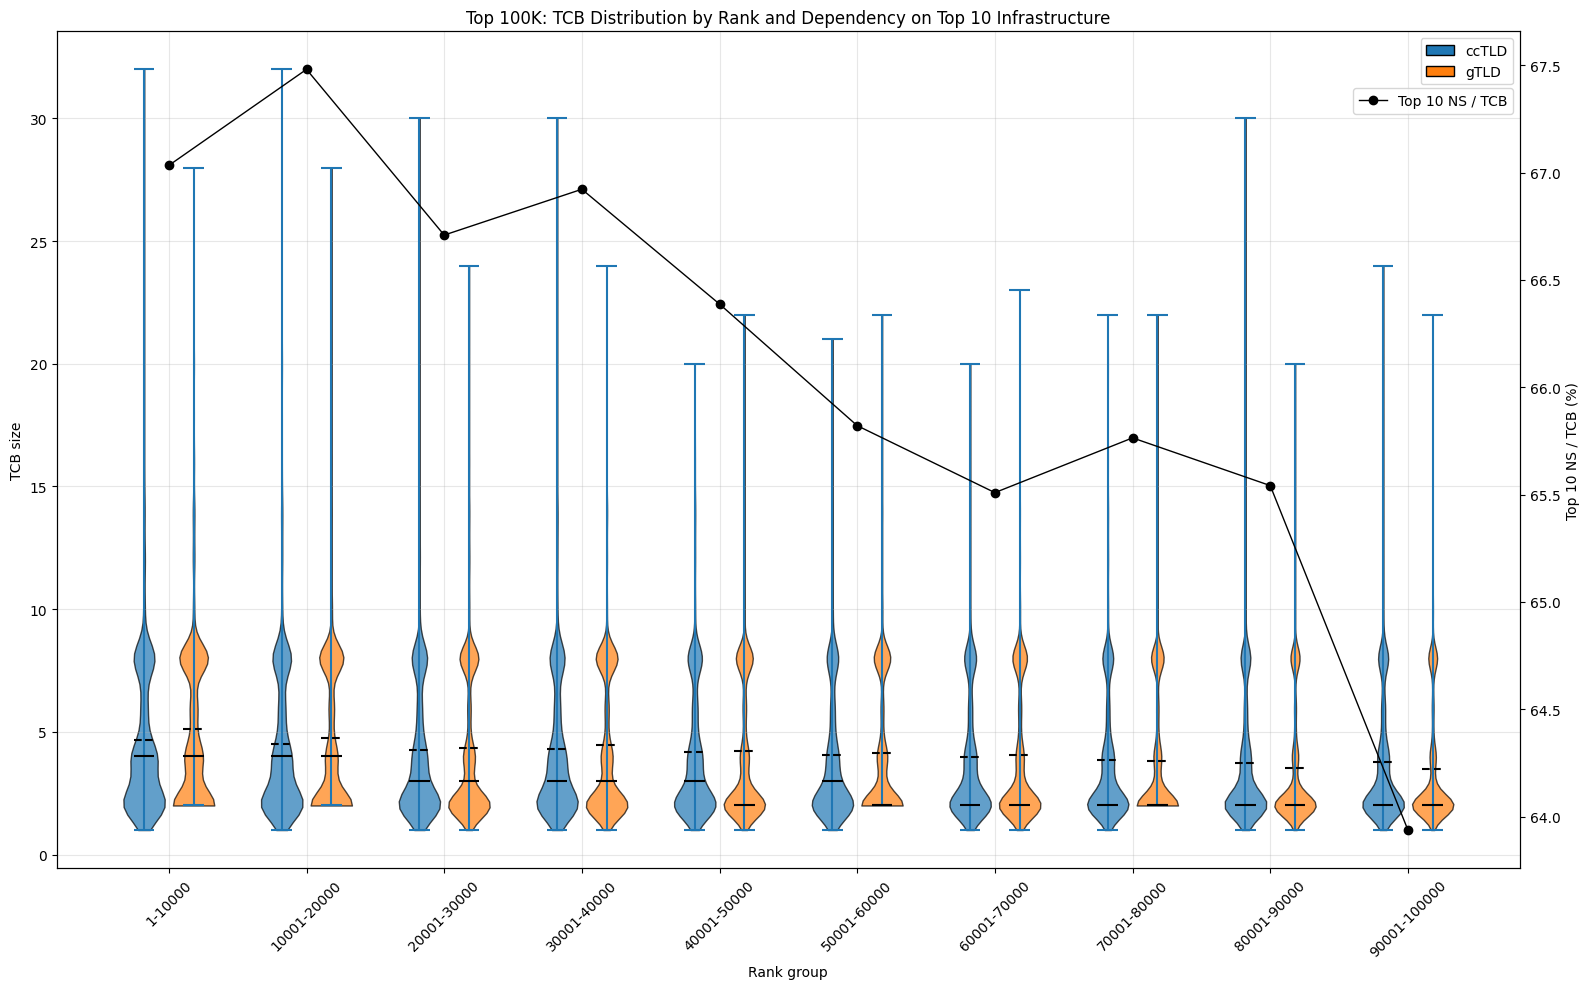

In [292]:
fig, ax = plt.subplots(figsize=(16, 10))

positions = []
groups = []
colors = []

for i in range(1, 11):
    for tld_group, offset, color in [
        ("ccTLD", -0.18, "tab:blue"),
        ("gTLD",  0.18, "tab:orange")
    ]:
        values = tranco_top_100k[
            (tranco_top_100k["rank_bin"] == i) &
            (tranco_top_100k["group_code"] == tld_group)
        ]["TCB"].dropna().to_numpy().ravel()

        groups.append(values)
        positions.append(i + offset)
        colors.append(color)

parts = ax.violinplot(
    dataset=groups,
    positions=positions,
    widths=0.30,
    showmeans=True,
    showmedians=True
)

parts["cmeans"].set_color("black")
parts["cmeans"].set_linestyle("--")

parts["cmedians"].set_color("black")
parts["cmedians"].set_linestyle("-")

for body, color in zip(parts["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.7)

ax.set_xticks(range(1, 11))
ax.set_xticklabels(
    [f"{(i-1)*10000 + 1}-{i*10000}" for i in range(1, 11)],
    rotation=45
)
ax.set_xlabel("Rank group")
ax.set_ylabel("TCB size")
ax.set_title("Top 100K: TCB Distribution by Rank and Dependency on Top 10 Infrastructure")
ax.grid(True, alpha=0.3)

# manual legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor="tab:blue", edgecolor="black", label="ccTLD"),
    Patch(facecolor="tab:orange", edgecolor="black", label="gTLD")
]
ax.legend(handles=legend_items)


# Drawing parcentage line  

ax2 = ax.twinx()

line_x = []
line_y = []

for i in range(1, 11):
    group_df = tranco_top_100k[tranco_top_100k["rank_bin"] == i]

    total_ns_inTop10 = group_df["ns_inTop10"].sum()
    total_TCB = group_df["TCB"].sum()

    pct = (total_ns_inTop10 / total_TCB) * 100

    line_x.append(i)
    line_y.append(pct)

ax2.plot(line_x, line_y, color="black", marker="o", linewidth=1, label="Top 10 NS / TCB")
ax2.set_ylabel("Top 10 NS / TCB (%)")
ax2.legend(loc="upper right", bbox_to_anchor=(1, 0.94))

plt.tight_layout()
plt.show()

##### Least Ranked 100K

###### getting the names.

Preparing the least-ranked 100K domains for top-10 infrastructure dependency analysis.


In [293]:
tranco_df = resolved_summary_df[["domain", "rank", "TCB","group_code","domain_unique_ns"]].copy()

tranco_df["group_code"] = tranco_df["group_code"].apply(
    lambda x: "ccTLD" if x == "ccTLD" else "gTLD"
)

tranco_df["rank"] = pd.to_numeric(tranco_df["rank"], errors="coerce")
tranco_df["TCB"] = pd.to_numeric(tranco_df["TCB"], errors="coerce")
tranco_df = tranco_df.dropna(subset=["rank", "TCB", "group_code"])



# last 100k ranks
tranco_least_100k = tranco_df[(tranco_df["rank"] >= 900000) & (tranco_df["rank"] <= 1000000)]

tranco_least_100k.head(2)

,domain,rank,TCB,group_code,domain_unique_ns
1,kiaspecialtools.com,985556,3,gTLD,"[ns1.a2.impervasecuredns.net, ns1.a1.impervasecuredns.net, ns1.a0.impervasecuredns.net]"
2,quiz4dgg.space,965100,2,gTLD,"[rosa.ns.cloudflare.com, darl.ns.cloudflare.com]"


Total( in TOP 5)/ Total(TCB) * 100

Counting how many nameservers for each least-100K domain belong to the top 10 infrastructure providers.


In [294]:
counts = []

top10Infra_set = set(tranco_namesaver_infrastructure_top10)

for row in tranco_least_100k.itertuples():
    count_inTop10 = 0
    for ns in row.domain_unique_ns:
        name = ns.split(".", 1)[1] # removing the most left right label.
        if name.startswith("awsdns"):
            name = "awsdns-infrastructure"
        else:
            name = name.rsplit(".",1)[0] # I am omming TLD here 
        
        if name in top10Infra_set:
            count_inTop10+=1

    counts.append(count_inTop10)


tranco_least_100k["ns_inTop10"] = counts

display(tranco_least_100k.head(5))

,domain,rank,TCB,group_code,domain_unique_ns,ns_inTop10
1,kiaspecialtools.com,985556,3,gTLD,"[ns1.a2.impervasecuredns.net, ns1.a1.impervasecuredns.net, ns1.a0.impervasecuredns.net]",0
2,quiz4dgg.space,965100,2,gTLD,"[rosa.ns.cloudflare.com, darl.ns.cloudflare.com]",2
3,edcsr.com,955280,3,gTLD,"[ns2.contabo.net, ns3.contabo.net, ns1.contabo.net]",0
4,agenbpjs777.info,950520,2,gTLD,"[ns10.hawkhost.com, ns9.hawkhost.com]",0
5,j399j39y6.com,958574,4,gTLD,"[ns1gjz.name.com, ns2hkt.name.com, ns3qty.name.com, ns4clq.name.com]",0


Bins and Graph preparations

Assigning least-100K domains to 10K rank bins for top-10 infrastructure plotting.


In [296]:
# create 10 groups of 10k
tranco_least_100k["rank_bin"] = ((tranco_least_100k["rank"] - 900000) // 10000) + 1

tranco_least_100k["rank_bin_label"] = tranco_least_100k["rank_bin"].apply(
    lambda x: f"{900000 + (x-1)*10000}-{900000 + x*10000 - 1}"
)

display(tranco_least_100k.head(2))

,domain,rank,TCB,group_code,domain_unique_ns,ns_inTop10,rank_bin,rank_bin_label
1,kiaspecialtools.com,985556,3,gTLD,"[ns1.a2.impervasecuredns.net, ns1.a1.impervasecuredns.net, ns1.a0.impervasecuredns.net]",0,9,980000-989999
2,quiz4dgg.space,965100,2,gTLD,"[rosa.ns.cloudflare.com, darl.ns.cloudflare.com]",2,7,960000-969999


Plotting top-10 infrastructure dependency percentages across least-100K rank bins.


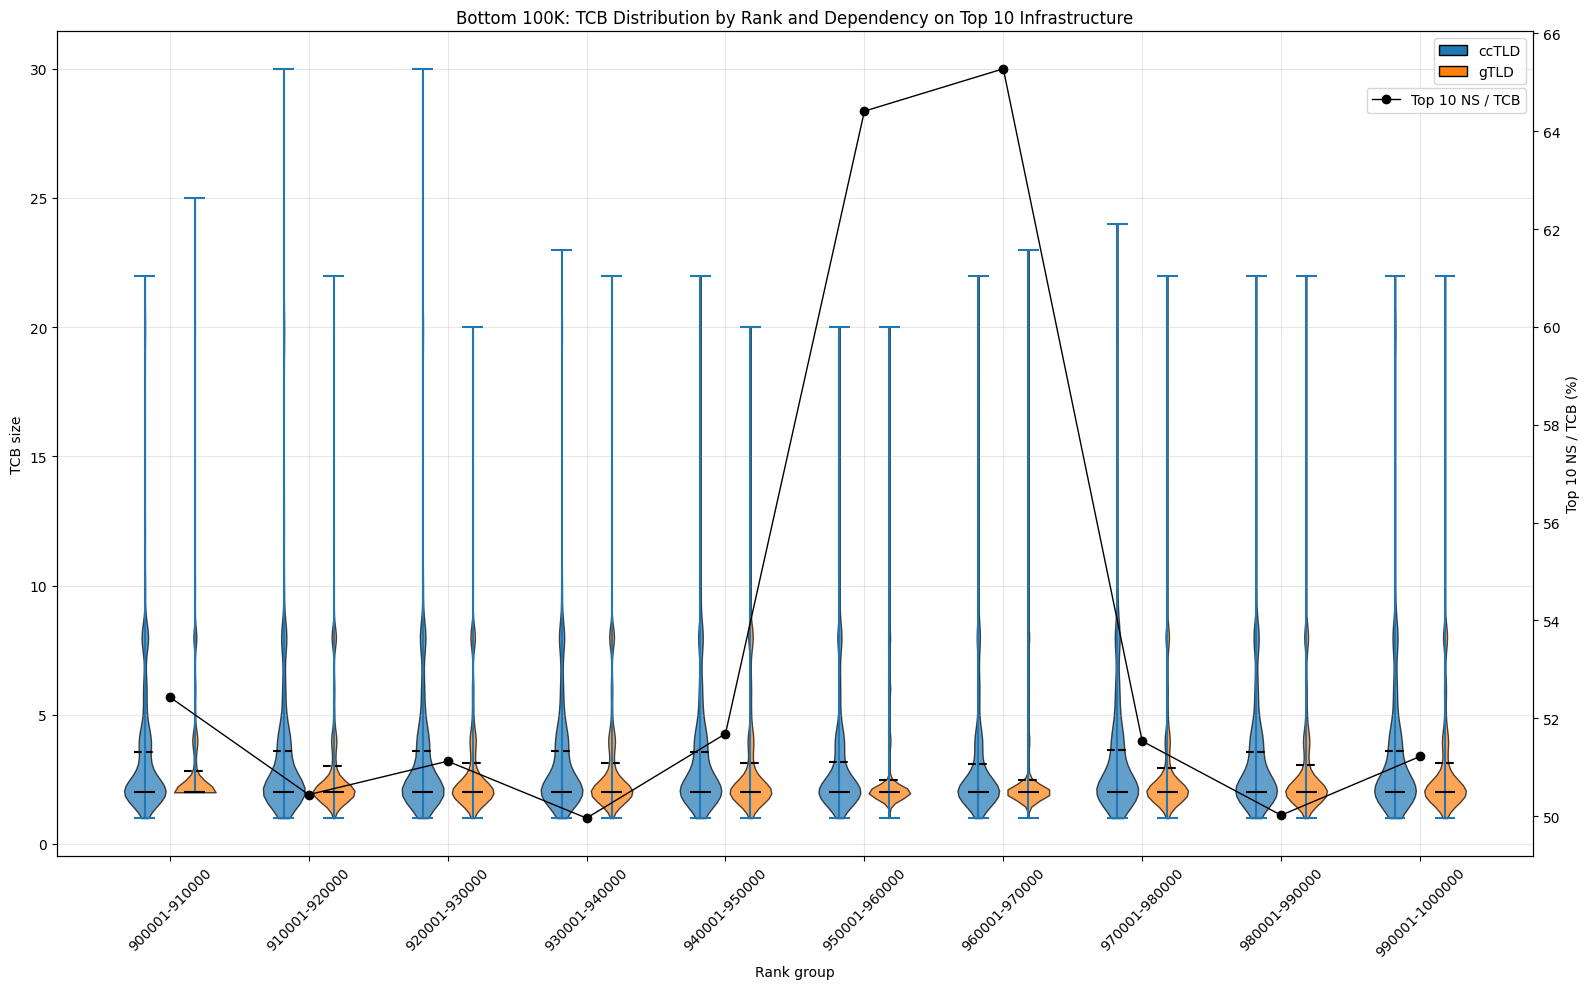

In [297]:
fig, ax = plt.subplots(figsize=(16, 10))

positions = []
groups = []
colors = []

for i in range(1, 11):
    for tld_group, offset, color in [
        ("ccTLD", -0.18, "tab:blue"),
        ("gTLD",  0.18, "tab:orange")
    ]:
        values = tranco_least_100k[
            (tranco_least_100k["rank_bin"] == i) &
            (tranco_least_100k["group_code"] == tld_group)
        ]["TCB"].dropna().to_numpy().ravel()

        groups.append(values)
        positions.append(i + offset)
        colors.append(color)

parts = ax.violinplot(
    dataset=groups,
    positions=positions,
    widths=0.30,
    showmeans=True,
    showmedians=True
)

parts["cmeans"].set_color("black")
parts["cmeans"].set_linestyle("--")

parts["cmedians"].set_color("black")
parts["cmedians"].set_linestyle("-")

for body, color in zip(parts["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.7)

ax.set_xticks(range(1, 11))
ax.set_xticklabels(
    [f"{900001 + (i-1)*10000}-{900000 + i*10000}" for i in range(1, 11)],
    rotation=45
)
ax.set_xlabel("Rank group")
ax.set_ylabel("TCB size")
ax.set_title("Bottom 100K: TCB Distribution by Rank and Dependency on Top 10 Infrastructure")
ax.grid(True, alpha=0.3)

# manual legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor="tab:blue", edgecolor="black", label="ccTLD"),
    Patch(facecolor="tab:orange", edgecolor="black", label="gTLD")
]
ax.legend(handles=legend_items)


# Drawing parcentage line  

ax2 = ax.twinx()

line_x = []
line_y = []

for i in range(1, 11):
    group_df = tranco_least_100k[tranco_least_100k["rank_bin"] == i]

    total_ns_inTop5 = group_df["ns_inTop10"].sum()
    total_TCB = group_df["TCB"].sum()

    pct = (total_ns_inTop5 / total_TCB) * 100

    line_x.append(i)
    line_y.append(pct)

ax2.plot(line_x, line_y, color="black", marker="o", linewidth=1, label="Top 10 NS / TCB")
ax2.set_ylabel("Top 10 NS / TCB (%)")
ax2.legend(loc="upper right", bbox_to_anchor=(1, 0.94))

plt.tight_layout()
plt.show()

#### TCB AVERAGE: Domain in Top Infrastructure vs Domain out Top Infrastructure

Loading top infrastructure providers and preparing both top-5 and top-10 provider lists.


In [ ]:
#loading Top Ifrastructure
file_path = Path.cwd().parent / 'data' / 'result' /  'NS_infrastructure' /'tranco_NS_infrastructure.parquet'
tranco_namesaver_infrastructure = pd.read_parquet(file_path)
display(tranco_namesaver_infrastructure.head(2))
tranco_namesaver_infrastructure.sort_values("Frequency",ascending=False)
tranco_namesaver_infrastructure_top5 = tranco_namesaver_infrastructure.iloc[:5, tranco_namesaver_infrastructure.columns.get_loc("NameServer")]
display(tranco_namesaver_infrastructure_top5)
tranco_namesaver_infrastructure_top10 = tranco_namesaver_infrastructure.iloc[:10, tranco_namesaver_infrastructure.columns.get_loc("NameServer")]
display(tranco_namesaver_infrastructure_top10)

,NameServer,Frequency
0,awsdns-infrastructure,721955
1,ns.cloudflare,676518


0    awsdns-infrastructure
1            ns.cloudflare
2                   ui-dns
3            domaincontrol
4                     akam
Name: NameServer, dtype: str

0    awsdns-infrastructure
1            ns.cloudflare
2                   ui-dns
3            domaincontrol
4                     akam
5                azure-dns
6            googledomains
7                 ultradns
8                      nic
9                    gandi
Name: NameServer, dtype: str

Creating a working dataframe with each domain, rank, TCB, group code, and unique nameserver list.


In [78]:
tranco_df = resolved_summary_df[["domain", "rank", "TCB","group_code","domain_unique_ns"]].copy()

Counting each domain’s dependency on top-5 and top-10 infrastructure providers.


In [80]:
# counting ns in  top 5
counts = []

top5Infra_set = set(tranco_namesaver_infrastructure_top5)

for row in tranco_df.itertuples():
    count_inTop5 = 0
    for ns in row.domain_unique_ns:
        name = ns.split(".", 1)[1] # removing the most left right label.
        if name.startswith("awsdns"):
            name = "awsdns-infrastructure"
        else:
            name = name.rsplit(".",1)[0] # I am omming TLD here 
        
        if name in top5Infra_set:
            count_inTop5+=1

    counts.append(count_inTop5)


tranco_df["ns_inTop5"] = counts


# counting ns in top 10
counts = []

top10Infra_set = set(tranco_namesaver_infrastructure_top10)

for row in tranco_df.itertuples():
    count_inTop10 = 0
    for ns in row.domain_unique_ns:
        name = ns.split(".", 1)[1] # removing the most left right label.
        if name.startswith("awsdns"):
            name = "awsdns-infrastructure"
        else:
            name = name.rsplit(".",1)[0] # I am omming TLD here 
        
        if name in top10Infra_set:
            count_inTop10+=1

    counts.append(count_inTop10)


tranco_df["ns_inTop10"] = counts



display(tranco_df.head(5))

,domain,rank,TCB,group_code,domain_unique_ns,ns_inTop5,ns_inTop10
0,kunlunea.com,14896,3,gTLD,"[ns5.aliyun.com, ns4.aliyun.com, ns3.aliyun.com]",0,0
1,kiaspecialtools.com,985556,3,gTLD,"[ns1.a2.impervasecuredns.net, ns1.a1.impervase...",0,0
2,quiz4dgg.space,965100,2,gTLD,"[rosa.ns.cloudflare.com, darl.ns.cloudflare.com]",2,2
3,edcsr.com,955280,3,gTLD,"[ns2.contabo.net, ns3.contabo.net, ns1.contabo...",0,0
4,agenbpjs777.info,950520,2,gTLD,"[ns10.hawkhost.com, ns9.hawkhost.com]",0,0


Selecting domains that use some top infrastructure while still depending on other providers too.


In [84]:
# do we have domains that have more have top infrastructure and else ?
# check if TCB and tcb nsInTop5 and nsInTop10 differ and the top  infra is not 0
tranco_diverse_inTop5_df = tranco_df[(tranco_df["TCB"]!=tranco_df["ns_inTop5"])&(tranco_df["ns_inTop5"]!=0)]

display(tranco_diverse_inTop5_df.shape)
display(tranco_diverse_inTop5_df.head(2))


tranco_diverse_inTop10_df = tranco_df[(tranco_df["TCB"]!=tranco_df["ns_inTop10"])&(tranco_df["ns_inTop10"]!=0)]

display(tranco_diverse_inTop10_df.shape)
display(tranco_diverse_inTop10_df.head(2))

(14878, 7)

,domain,rank,TCB,group_code,domain_unique_ns,ns_inTop5,ns_inTop10
331,micro138.org,989206,4,gTLD,"[ns2.ulltaahost.top, ns1.ulltaahost.top, bened...",2,2
354,s1i.net,991045,5,gTLD,"[ns1.s1i.net, ns16.iaasdns.com, ns15.iaasdns.c...",2,2


(24475, 7)

,domain,rank,TCB,group_code,domain_unique_ns,ns_inTop5,ns_inTop10
84,power-electronics.com,990636,13,gTLD,"[ns2.serviciodns.es, ns1.serviciodns.es, ns3.s...",0,9
177,iraiser.com,994772,10,gTLD,"[ns-213-b.gandi.net, ns-161-a.gandi.net, ns-13...",0,9


Splitting domains into groups with no top-provider dependency, at least one top-5 provider, and at least one top-10 provider.


In [88]:
# domain with 0  NS in the top Infrastructure
tranco_not_in_top = tranco_df[(tranco_df["ns_inTop5"]==0)&(tranco_df["ns_inTop10"]==0)]

# domain with atleast 1 NS in Top 5
tranco_in_top5 = tranco_df[(tranco_df["ns_inTop5"]>=1)] 

# domain with atleast 1 NS in Top 10
tranco_in_top10 = tranco_df[(tranco_df["ns_inTop10"]>=1)] 


Computing TCB averages and medians for domains based on their top-infrastructure dependency category.


In [89]:


# TCB average for domain based on dependency top 5 and top 10 infrastructure
    
#general Mean and Median
tcb = tranco_df["TCB"].dropna().to_numpy()
mean_tcb = np.mean(tcb)
median_tcb = np.median(tcb)

# Mean and Median domain with 0 in Top 5 and Top 10
tcb_n0 = tranco_not_in_top["TCB"].dropna().to_numpy()
mean_tcb_n0 = np.mean(tcb_n0)
median_tcb_n0 = np.median(tcb_n0)

# Mean and Median with at least 1 Dependency on top 5
tcb_d5 = tranco_in_top5["TCB"].dropna().to_numpy()
mean_tcb_d5 = np.mean(tcb_d5)
median_tcb_d5 = np.median(tcb_d5)


# Mean and Median with at least 1 Dependency on top 10
tcb_d10 = tranco_in_top10["TCB"].dropna().to_numpy()
mean_tcb_d10 = np.mean(tcb_d10)
median_tcb_d10 = np.median(tcb_d10)
summary_stats_df = pd.DataFrame(
    {
        "all": [mean_tcb, median_tcb],
        "not_in_top": [mean_tcb_n0, median_tcb_n0],
        "in_top5": [mean_tcb_d5, median_tcb_d5],
        "in_top10": [mean_tcb_d10, median_tcb_d10],
    },
    index=["mean", "median"]
)

display(summary_stats_df)


,all,not_in_top,in_top5,in_top10
mean,3.440203,3.114169,3.498646,3.697838
median,2.000000,2.000000,2.000000,2.000000


#### Example Results 

Displaying selected example domains with full column width for easier inspection.


In [187]:
pd.set_option("display.max_colwidth", None)
display(resolved_summary_df[resolved_summary_df["domain"] == "utwente.nl"])
display(resolved_summary_df[resolved_summary_df["domain"] == "pwcedge-sbs-innov-lab.com"])
display(resolved_summary_df[resolved_summary_df["domain"] == "villanova.edu"])

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,group_code,rank,tld,type
926401,utwente.nl,1,1,3,1.0,3,"[ns2.utwente.nl, ns3.utwente.nl, ns1.utwente.nl]","[{'name_server_count': 1, 'name_servers': ['ns2.utwente.nl'], 'start_domain': 'utwente.nl'}, {'name_server_count': 1, 'name_servers': ['ns3.utwente.nl'], 'start_domain': 'utwente.nl'}, {'name_server_count': 1, 'name_servers': ['ns1.utwente.nl'], 'start_domain': 'utwente.nl'}]","[{'source': 'utwente.nl', 'target_zone': None, 'via_nameservers': ['ns2.utwente.nl', 'ns3.utwente.nl', 'ns1.utwente.nl']}]",ccTLD,7774,nl,country-code


,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,group_code,rank,tld,type
16,pwcedge-sbs-innov-lab.com,1,2,7,1.571429,8,"[ns-460.awsdns-57.com, ns-1017.awsdns-63.net, ns-1424.awsdns-50.org, ns-1840.awsdns-38.co.uk, g-ns-1834.awsdns-38.co.uk, g-ns-934.awsdns-38.co.uk, g-ns-358.awsdns-38.co.uk, g-ns-1513.awsdns-38.co.uk]","[{'name_server_count': 1, 'name_servers': ['ns-460.awsdns-57.com'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}, {'name_server_count': 1, 'name_servers': ['ns-1017.awsdns-63.net'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}, {'name_server_count': 1, 'name_servers': ['ns-1424.awsdns-50.org'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}, {'name_server_count': 2, 'name_servers': ['ns-1840.awsdns-38.co.uk', 'g-ns-1834.awsdns-38.co.uk'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}, {'name_server_count': 2, 'name_servers': ['ns-1840.awsdns-38.co.uk', 'g-ns-934.awsdns-38.co.uk'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}, {'name_server_count': 2, 'name_servers': ['ns-1840.awsdns-38.co.uk', 'g-ns-358.awsdns-38.co.uk'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}, {'name_server_count': 2, 'name_servers': ['ns-1840.awsdns-38.co.uk', 'g-ns-1513.awsdns-38.co.uk'], 'start_domain': 'pwcedge-sbs-innov-lab.com'}]","[{'source': 'pwcedge-sbs-innov-lab.com', 'target_zone': None, 'via_nameservers': ['ns-460.awsdns-57.com', 'ns-1017.awsdns-63.net', 'ns-1424.awsdns-50.org']}, {'source': 'pwcedge-sbs-innov-lab.com', 'target_zone': 'awsdns-38.co.uk', 'via_nameservers': ['ns-1840.awsdns-38.co.uk']}, {'source': 'awsdns-38.co.uk', 'target_zone': None, 'via_nameservers': ['g-ns-1834.awsdns-38.co.uk', 'g-ns-934.awsdns-38.co.uk', 'g-ns-358.awsdns-38.co.uk', 'g-ns-1513.awsdns-38.co.uk']}]",gTLD,971687,com,generic


,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,group_code,rank,tld,type
945821,villanova.edu,1,3,12,2.333333,10,"[dnsauth3.sys.gtei.net, dnsauth2.sys.gtei.net, ns5.villanova.edu, ns4.villanova.edu, ns1.net.pennren.net, ns2.net.pennren.net, dns2.firstlight.net, dns1.firstlight.net, cns1.firstlight.net, cns2.firstlight.net]","[{'name_server_count': 1, 'name_servers': ['dnsauth3.sys.gtei.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 1, 'name_servers': ['dnsauth2.sys.gtei.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 1, 'name_servers': ['ns5.villanova.edu'], 'start_domain': 'villanova.edu'}, {'name_server_count': 1, 'name_servers': ['ns4.villanova.edu'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns1.net.pennren.net', 'dns2.firstlight.net', 'cns1.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns1.net.pennren.net', 'dns2.firstlight.net', 'cns2.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns1.net.pennren.net', 'dns1.firstlight.net', 'cns1.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns1.net.pennren.net', 'dns1.firstlight.net', 'cns2.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns2.net.pennren.net', 'dns2.firstlight.net', 'cns1.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns2.net.pennren.net', 'dns2.firstlight.net', 'cns2.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns2.net.pennren.net', 'dns1.firstlight.net', 'cns1.firstlight.net'], 'start_domain': 'villanova.edu'}, {'name_server_count': 3, 'name_servers': ['ns2.net.pennren.net', 'dns1.firstlight.net', 'cns2.firstlight.net'], 'start_domain': 'villanova.edu'}]","[{'source': 'villanova.edu', 'target_zone': None, 'via_nameservers': ['dnsauth3.sys.gtei.net', 'dnsauth2.sys.gtei.net', 'ns5.villanova.edu', 'ns4.villanova.edu']}, {'source': 'villanova.edu', 'target_zone': 'net.pennren.net', 'via_nameservers': ['ns1.net.pennren.net', 'ns2.net.pennren.net']}, {'source': 'net.pennren.net', 'target_zone': 'firstlight.net', 'via_nameservers': ['dns2.firstlight.net', 'dns1.firstlight.net']}, {'source': 'firstlight.net', 'target_zone': None, 'via_nameservers': ['cns1.firstlight.net', 'cns2.firstlight.net']}]",sponTLD,25730,edu,sponsored


### Domain with parents


Previewing the dependency results for domains with parent relationships.


In [ ]:
domain_with_parent.head()

,domain,short_path_size,long_path_size,available_paths,average_path_size,TCB,domain_unique_ns,domain_path_rows,dependencies,parent,short_path_size_via_parent,long_path_size_via_parent,available_paths_via_parent,average_path_size_via_parent,parent_TCB,TCB_with_parent,all_parent_unique_ns,parent_path_rows
0,apostille.mygov.bd,1,1,10,1.8,2,"[melina.ns.cloudflare.com, nile.ns.cloudflare.com]","[{'domain': 'apostille.mygov.bd', 'name_server_count': 1, 'parent': 'mygov.bd', 'path': ['apostille.mygov.bd', 'melina.ns.cloudflare.com']}, {'domain': 'apostille.mygov.bd', 'name_server_count': 1, 'parent': 'mygov.bd', 'path': ['apostille.mygov.bd', 'nile.ns.cloudflare.com']}]","[{'side': 'child', 'source': 'apostille.mygov.bd', 'target_zone': None, 'via_nameservers': ['melina.ns.cloudflare.com', 'nile.ns.cloudflare.com']}, {'side': 'parent', 'source': 'mygov.bd', 'target_zone': None, 'via_nameservers': ['ns1.bcc.gov.bd']}, {'side': 'parent', 'source': 'mygov.bd', 'target_zone': 'bcc.gov.bd', 'via_nameservers': ['dns2.bcc.gov.bd', 'dns1.bcc.gov.bd']}, {'side': 'parent', 'source': 'bcc.gov.bd', 'target_zone': None, 'via_nameservers': ['ns2.bcc.gov.bd', 'ns1.bcc.gov.bd']}]",mygov.bd,1,2,10,1.8,4,6,"[ns1.bcc.gov.bd, dns2.bcc.gov.bd, dns1.bcc.gov.bd, ns2.bcc.gov.bd]","[{'domain': 'mygov.bd', 'name_server_count': 1, 'parent_of': 'apostille.mygov.bd', 'path': ['mygov.bd', 'ns1.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'apostille.mygov.bd', 'path': ['mygov.bd', 'dns2.bcc.gov.bd', 'bcc.gov.bd', 'ns2.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'apostille.mygov.bd', 'path': ['mygov.bd', 'dns2.bcc.gov.bd', 'bcc.gov.bd', 'ns1.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'apostille.mygov.bd', 'path': ['mygov.bd', 'dns1.bcc.gov.bd', 'bcc.gov.bd', 'ns2.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'apostille.mygov.bd', 'path': ['mygov.bd', 'dns1.bcc.gov.bd', 'bcc.gov.bd', 'ns1.bcc.gov.bd']}]"
1,www.mygov.bd,1,1,10,1.8,2,"[melina.ns.cloudflare.com, nile.ns.cloudflare.com]","[{'domain': 'www.mygov.bd', 'name_server_count': 1, 'parent': 'mygov.bd', 'path': ['www.mygov.bd', 'melina.ns.cloudflare.com']}, {'domain': 'www.mygov.bd', 'name_server_count': 1, 'parent': 'mygov.bd', 'path': ['www.mygov.bd', 'nile.ns.cloudflare.com']}]","[{'side': 'child', 'source': 'www.mygov.bd', 'target_zone': None, 'via_nameservers': ['melina.ns.cloudflare.com', 'nile.ns.cloudflare.com']}, {'side': 'parent', 'source': 'mygov.bd', 'target_zone': None, 'via_nameservers': ['ns1.bcc.gov.bd']}, {'side': 'parent', 'source': 'mygov.bd', 'target_zone': 'bcc.gov.bd', 'via_nameservers': ['dns2.bcc.gov.bd', 'dns1.bcc.gov.bd']}, {'side': 'parent', 'source': 'bcc.gov.bd', 'target_zone': None, 'via_nameservers': ['ns2.bcc.gov.bd', 'ns1.bcc.gov.bd']}]",mygov.bd,1,2,10,1.8,4,6,"[ns1.bcc.gov.bd, dns2.bcc.gov.bd, dns1.bcc.gov.bd, ns2.bcc.gov.bd]","[{'domain': 'mygov.bd', 'name_server_count': 1, 'parent_of': 'www.mygov.bd', 'path': ['mygov.bd', 'ns1.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'www.mygov.bd', 'path': ['mygov.bd', 'dns2.bcc.gov.bd', 'bcc.gov.bd', 'ns2.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'www.mygov.bd', 'path': ['mygov.bd', 'dns2.bcc.gov.bd', 'bcc.gov.bd', 'ns1.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'www.mygov.bd', 'path': ['mygov.bd', 'dns1.bcc.gov.bd', 'bcc.gov.bd', 'ns2.bcc.gov.bd']}, {'domain': 'mygov.bd', 'name_server_count': 2, 'parent_of': 'www.mygov.bd', 'path': ['mygov.bd', 'dns1.bcc.gov.bd', 'bcc.gov.bd', 'ns1.bcc.gov.bd']}]"


Adding a group-code label to domains with parent relationships.


In [86]:
# create a column on dataframe domain_with_parent with value  "jnsde"
domain_with_parent["group_code"] = "country-code"




Merging parent-aware dependency results with TLD and type metadata.


In [87]:
with_parent_resolved_summary_df = domain_with_parent.merge(
    categorized_names_df[["domain", "tld", "type"]],
    on="domain",
    how="left"
)

Plotting CDF curves to compare TCB with and without parent dependencies.


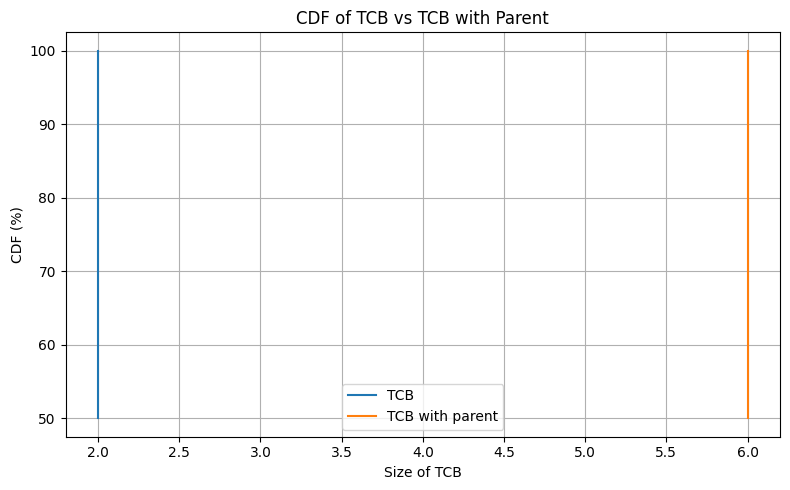

In [89]:
df = with_parent_resolved_summary_df.copy()

# keep only rows where both exist
df = df.dropna(subset=["TCB", "TCB_with_parent"])

plt.figure(figsize=(8, 5))

for col, label in [("TCB", "TCB"), ("TCB_with_parent", "TCB with parent")]:
    values = np.sort(df[col].to_numpy())
    cdf = np.arange(1, len(values) + 1) / len(values)

    plt.plot(values, cdf * 100, label=label)

plt.xlabel("Size of TCB")
plt.ylabel("CDF (%)")
plt.title("CDF of TCB vs TCB with Parent")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(fig_dir / "CDF_TCB_vs_TCB_with_parent.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## Other Questions
